## Week 1 - Análisis Exploratorio de Datos

### Introducción al Análisis Exploratorio (EDA)

Marco sistemático de EDA

Fase 1: Preparación y Contexto

    ¿Cuál es la fuente de los datos? ¿Son confiables?
    ¿Qué preguntas de negocio motivan este análisis?
    ¿Qué variables están disponibles? ¿Qué tipos de datos?
    ¿Existen restricciones temporales, geográficas o demográficas?

Fase 2: Inspección Inicial

    Dimensiones del dataset (filas, columnas)
    Tipos de datos y valores faltantes
    Estadísticos básicos por variable
    Identificación de datos problemáticos

Fase 3: Análisis Univariado

    Distribución de cada variable individual
    Identificación de outliers y anomalías
    Transformaciones necesarias (log, normalización)

Fase 4: Análisis Bivariado/Multivariado

    Relaciones entre variables importantes
    Patrones de correlación y dependencia
    Segmentación natural de los datos

Fase 5: Síntesis e Insights

    ¿Qué patrones emergen consistentemente?
    ¿Qué anomalías requieren explicación?
    ¿Qué hipótesis nuevas se generan?
    ¿Qué acciones concretas sugieren los datos?


EDA en Pandas

1. Configuración del Entorno de Análisis

```
# Importaciones estándar para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('default')  # Estilo de gráficos
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.width', None)  # Ancho completo
```
2. Inspección Inicial del Dataset
```
# Carga de datos
df = pd.read_csv('datos_ventas.csv')

# Dimensiones básicas
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"\nColumnas: {list(df.columns)}")

# Primeras filas para entender estructura
df.head()
```
3. Análisis de Tipos y Valores Faltantes
```
# Información general
df.info()

# Porcentaje de valores faltantes por columna
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Valores faltantes (%):")
print(missing_percent[missing_percent > 0])
```

4. Estadísticos Descriptivos Iniciales
```
# Estadísticos básicos para variables numéricas
df.describe()

# Para variables categóricas
df.describe(include=['object'])

# Conteo de valores únicos
df.nunique()
```

5. Validación de Calidad de Datos
```
# Verificar rangos lógicos
print("Edades fuera de rango:", ((df['edad'] < 0) | (df['edad'] > 120)).sum())
print("Precios negativos:", (df['precio'] < 0).sum())

# Valores duplicados
print("Filas duplicadas:", df.duplicated().sum())
```

Preguntas Orientadoras para EDA

El EDA efectivo requiere preguntas orientadoras que guíen la exploración hacia insights relevantes. Estas preguntas evolucionan a medida que se descubre más sobre los datos.
Preguntas Demográficas

    ¿Cuál es la distribución de edad de nuestros clientes?
    ¿Cómo se distribuyen geográficamente?
    ¿Existen segmentos demográficos naturales?

Preguntas de Comportamiento

    ¿Cuáles son los patrones de compra típicos?
    ¿Qué productos se compran juntos?
    ¿Cómo varía el comportamiento por segmentos?

Preguntas de Calidad

    ¿Qué porcentaje de datos están completos?
    ¿Existen valores extremos que distorsionen análisis?
    ¿Los datos son consistentes temporalmente?

Preguntas de Oportunidad

    ¿Qué patrones no esperados aparecen?
    ¿Qué segmentos están subexplotados?
    ¿Qué productos tienen potencial no reconocido?


#### Ejemplo

Carga y configuración inicial:

In [ ]:
import pandas as pd
import numpy as np

# Crear dataset de ejemplo de e-commerce
np.random.seed(42)
n_orders = 1000

df = pd.DataFrame({
    'order_id': range(1, n_orders + 1),
    'customer_id': np.random.randint(1, 201, n_orders),
    'product_id': np.random.randint(1, 51, n_orders),
    'quantity': np.random.randint(1, 5, n_orders),
    'unit_price': np.round(np.random.uniform(10, 500, n_orders), 2),
    'order_date': pd.date_range('2023-01-01', periods=n_orders, freq='h')[:n_orders],
    'payment_method': np.random.choice(['Credit Card', 'Debit Card', 'PayPal', 'Cash'], n_orders),
    'customer_age': np.random.normal(35, 10, n_orders).clip(18, 80).astype(int),
    'shipping_region': np.random.choice(['North', 'South', 'East', 'West'], n_orders)
})

# Introducir algunos valores faltantes
mask = np.random.random(n_orders) < 0.05
df.loc[mask, 'customer_age'] = np.nan

print("Dataset cargado exitosamente")

Dataset cargado exitosamente


Inspección inicial sistemática:

In [ ]:
# Dimensiones y estructura
print(f"Dataset shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos de datos:\n{df.dtypes}")

# Primeras y últimas filas
print("\nPrimeras 5 filas:")
print(df.head())

print("\nÚltimas 5 filas:")
print(df.tail())

Dataset shape: (1000, 9)

Columnas: ['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price', 'order_date', 'payment_method', 'customer_age', 'shipping_region']

Tipos de datos:
order_id                    int64
customer_id                 int64
product_id                  int64
quantity                    int64
unit_price                float64
order_date         datetime64[ns]
payment_method             object
customer_age              float64
shipping_region            object
dtype: object

Primeras 5 filas:
   order_id  customer_id  product_id  quantity  unit_price  \
0         1          103          40         2      371.34   
1         2          180          49         2      260.99   
2         3           93          44         3      343.31   
3         4           15          19         2       30.42   
4         5          107          42         2       51.55   

           order_date payment_method  customer_age shipping_region  
0 2023-01-01 00:00:00     Debit

Análisis de calidad de datos:

In [ ]:
# Valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

print(f"\nPorcentaje de completitud: {(1 - df.isnull().sum() / len(df)) * 100}")

# Valores únicos por columna
print("\nValores únicos por columna:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

# Estadísticos básicos para numéricas
print("\nEstadísticos básicos de variables numéricas:")
print(df.select_dtypes(include=[np.number]).describe())

Valores faltantes por columna:
order_id            0
customer_id         0
product_id          0
quantity            0
unit_price          0
order_date          0
payment_method      0
customer_age       46
shipping_region     0
dtype: int64

Porcentaje de completitud: order_id           100.0
customer_id        100.0
product_id         100.0
quantity           100.0
unit_price         100.0
order_date         100.0
payment_method     100.0
customer_age        95.4
shipping_region    100.0
dtype: float64

Valores únicos por columna:
payment_method: 4 valores únicos
shipping_region: 4 valores únicos

Estadísticos básicos de variables numéricas:
          order_id  customer_id   product_id     quantity   unit_price  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    500.500000   101.697000    25.680000     2.469000   253.828640   
std     288.819436    57.629249    14.180645     1.121739   141.648562   
min       1.000000     1.000000     1.000000     1.0

Preguntas exploratorias iniciales:

In [ ]:
# Distribución por región
print("Distribución de pedidos por región:")
print(df['shipping_region'].value_counts())

# Método de pago más popular
print(f"\nMétodo de pago más usado: {df['payment_method'].value_counts().index[0]}")

# Rango de fechas
print(f"\nPeríodo de datos: {df['order_date'].min()} a {df['order_date'].max()}")

# Edad promedio de clientes
edad_promedio = df['customer_age'].mean()
print(f"\nEdad promedio de clientes: {edad_promedio:.1f} años")

Distribución de pedidos por región:
shipping_region
South    267
North    250
East     246
West     237
Name: count, dtype: int64

Método de pago más usado: Credit Card

Período de datos: 2023-01-01 00:00:00 a 2023-02-11 15:00:00

Edad promedio de clientes: 34.7 años


### Estadística Descriptiva Básica

**Medidas de Tendencia Central**

Representan el punto de equilibrio de una distribución de datos, respondiendo a la pregunta fundamental: "¿Dónde se concentra la mayoría de los valores?". Cada medida ofrece una perspectiva diferente sobre el "centro" de los datos.

- Media Aritmética (Promedio)
            
    Fortalezas:

    - Propiedad matemática: Minimiza la suma de errores cuadráticos
    - Sensibilidad a cambios: Refleja inmediatamente cualquier modificación en los datos
    - Base para estadística avanzada: Fundamento de varianza, regresión, etc.

    Limitaciones críticas:

    - sensibilidad a outliers: Un solo valor extremo puede distorsionar completamente la media
    - No robusta: En distribuciones sesgadas, no representa el "típico"
    - Engañosa con datos faltantes: No indica si la media es representativa

- Mediana

    La mediana es el punto medio cuando los datos se ordenan, ofreciendo una medida robusta que resiste outliers.

    Ventajas:

    - Robusta: Insensible a valores extremos
    - Intuitiva: El "valor típico" en distribuciones sesgadas
    - Siempre existe: Definida para cualquier distribución

    Casos de uso:

    - Ingresos: Mejor que media para distribuciones con ricos extremos
    - Tiempos de respuesta: No afectado por timeouts ocasionales
    - Precios de vivienda: Resistente a mansiones excepcionales

- Moda

    La moda representa los valores más comunes en el dataset, revelando preferencias naturales o categorías dominantes.

    Tipos de moda:

    - Unimodal: Una sola categoría dominante
    - Bimodal: Dos categorías con frecuencias similares
    - Multimodal: Múltiples categorías frecuentes
    - Sin moda: Todos los valores igualmente frecuentes

    Aplicaciones prácticas:

    - Segmentación de mercado: Productos más vendidos por categoría
    - Análisis de comportamiento: Acciones más frecuentes de usuarios
    - Detección de patrones: Categorías dominantes en datos categóricos


**Medidas de Dispersión y Variabilidad**

Mientras las medidas de tendencia central nos dicen dónde se concentran los datos, las medidas de dispersión explican cuán dispersos o concentrados están alrededor de ese centro.

- Rango

    El rango es la medida más simple de dispersión: la distancia entre el valor más pequeño y el más grande.

    Limitaciones:

    - Sensibilidad a outliers: Un solo valor extremo distorsiona el rango
    - No informativo sobre distribución: Dos datasets pueden tener mismo rango pero formas muy diferentes

- Varianza

    La varianza mide la dispersión promedio de los datos alrededor de la media, cuantificando qué tan "extendidos" están.

- Desviación estándar
    Matemáticamente es la raíz cuadrada de la varianza, en las mismas unidades que los datos originales.

    Interpretación práctica:

    - Desviación estándar pequeña: Datos concentrados alrededor de la media
    - Desviación estándar grande: Datos muy dispersos
    - Regla empírica: ~68% de datos están dentro de 1 DE, ~95% dentro de 2 DE, ~99.7% dentro de 3 DE

- Coeficiente de variación
    
    Coeficiente de variación: CV = σ/μ - medida relativa de dispersión, útil para comparar variables con unidades diferentes.

Estadísticos de Posición y Percentiles

Los percentiles dividen la distribución en porciones iguales, permitiendo análisis granular de la posición relativa de valores específicos.

- Cuartiles y Percentiles Básicos

    Percentiles: Dividen la distribución en 100 partes iguales

    - P25 (Q1): 25% de datos por debajo
    - P50 (Mediana): 50% de datos por debajo
    - P75 (Q3): 75% de datos por debajo

- Rango intercuartílico (IQR)

    IQR = Q3 - Q1 - medida robusta de dispersión que ignora outliers.

    Identificación de outliers: en Análisis de datos se considera el Método IQR

    - Límite inferior: Q1 - 1.5 × IQR
    - Límite superior: Q3 + 1.5 × IQR
    - Valores fuera de estos límites se consideran outliers

- Análisis de distribución
    - Distribución simétrica: Q2 ≈ (Q1 + Q3)/2
    - Sesgo positivo: Q2 > (Q1 + Q3)/2
    - Sesgo negativo: Q2 < (Q1 + Q3)/2

- Comparaciones relativas
    - P90: Valor por encima del cual están el 10% superior
    - P10: Valor por debajo del cual están el 10% inferior


#### Ejemplo

Crear y explorar dataset de empleados:

In [ ]:
import pandas as pd
import numpy as np

# Crear dataset de empleados
np.random.seed(42)
n_empleados = 500

df = pd.DataFrame({
    'id_empleado': range(1, n_empleados + 1),
    'edad': np.random.normal(35, 8, n_empleados).clip(22, 65).astype(int),
    'salario': np.random.lognormal(10.5, 0.4, n_empleados).round(0),
    'años_experiencia': np.random.normal(8, 4, n_empleados).clip(0, 30).astype(int),
    'departamento': np.random.choice(['IT', 'Ventas', 'Marketing', 'RRHH', 'Finanzas'], n_empleados),
    'nivel': np.random.choice(['Junior', 'Senior', 'Lead', 'Manager'], n_empleados, p=[0.4, 0.4, 0.15, 0.05])
})

print(f"Dataset creado: {df.shape[0]} empleados")
print(f"Columnas: {list(df.columns)}")

Dataset creado: 500 empleados
Columnas: ['id_empleado', 'edad', 'salario', 'años_experiencia', 'departamento', 'nivel']


Análisis de medidas de tendencia central:

In [ ]:
# Estadísticos básicos
print("MEDIDAS DE TENDENCIA CENTRAL")
print("=" * 40)

# Variables numéricas
for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    print(f"  Media: {df[col].mean():.2f}")
    print(f"  Mediana: {df[col].median():.2f}")
    print(f"  Moda: {df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'Sin moda única'}")

# Variables categóricas
print(f"\nDEPARTAMENTO MÁS COMÚN: {df['departamento'].mode().iloc[0]}")
print(f"NIVEL MÁS COMÚN: {df['nivel'].mode().iloc[0]}")

MEDIDAS DE TENDENCIA CENTRAL

EDAD:
  Media: 34.69
  Mediana: 35.00
  Moda: 35

SALARIO:
  Media: 39715.18
  Mediana: 36732.00
  Moda: 23566.0

AÑOS_EXPERIENCIA:
  Media: 7.97
  Mediana: 8.00
  Moda: 8

DEPARTAMENTO MÁS COMÚN: RRHH
NIVEL MÁS COMÚN: Senior


Análisis de dispersión:

In [ ]:
print("\n\nMEDIDAS DE DISPERSIÓN")
print("=" * 30)

for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    print(f"  Rango: {df[col].max() - df[col].min()}")
    print(f"  Varianza: {df[col].var():.2f}")
    print(f"  Desviación estándar: {df[col].std():.2f}")
    print(f"  Coeficiente de variación: {df[col].std() / df[col].mean():.3f}")



MEDIDAS DE DISPERSIÓN

EDAD:
  Rango: 43
  Varianza: 57.44
  Desviación estándar: 7.58
  Coeficiente de variación: 0.218

SALARIO:
  Rango: 91736.0
  Varianza: 262243168.52
  Desviación estándar: 16193.92
  Coeficiente de variación: 0.408

AÑOS_EXPERIENCIA:
  Rango: 18
  Varianza: 15.57
  Desviación estándar: 3.95
  Coeficiente de variación: 0.495


Análisis de percentiles y distribución:

In [ ]:
print("\n\nANÁLISIS DE PERCENTILES")
print("=" * 25)

for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    percentiles = df[col].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    for p, v in percentiles.items():
        print(f"  P{int(p*100)}: {v:.2f}")

    # Rango intercuartílico
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    print(f"  IQR: {iqr:.2f}")

    # Límites para outliers
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    print(f"  Outliers (IQR): {outliers}")



ANÁLISIS DE PERCENTILES

EDAD:
  P10: 25.00
  P25: 29.00
  P50: 35.00
  P75: 40.00
  P90: 45.00
  IQR: 11.00
  Outliers (IQR): 2

SALARIO:
  P10: 21990.90
  P25: 28620.75
  P50: 36732.00
  P75: 47121.75
  P90: 61840.40
  IQR: 18501.00
  Outliers (IQR): 19

AÑOS_EXPERIENCIA:
  P10: 3.00
  P25: 5.00
  P50: 8.00
  P75: 11.00
  P90: 13.00
  IQR: 6.00
  Outliers (IQR): 0


Análisis por categorías:

In [ ]:
print("\n\nANÁLISIS POR DEPARTAMENTO")
print("=" * 30)

dept_stats = df.groupby('departamento').agg({
    'salario': ['mean', 'median', 'std', 'count'],
    'edad': ['mean', 'min', 'max']
}).round(2)

print(dept_stats)

print("\n\nANÁLISIS POR NIVEL")
print("=" * 20)

nivel_stats = df.groupby('nivel').agg({
    'salario': 'mean',
    'años_experiencia': 'mean',
    'edad': 'mean'
}).round(2)

print(nivel_stats)



ANÁLISIS POR DEPARTAMENTO
               salario                            edad        
                  mean   median       std count   mean min max
departamento                                                  
Finanzas      39400.97  35745.0  17512.32    97  34.45  22  59
IT            39004.76  35310.0  16511.62   109  34.73  22  50
Marketing     39298.89  38299.0  14486.98   101  34.31  22  51
RRHH          40449.09  39102.0  14913.70   115  35.04  22  65
Ventas        40555.69  36957.5  18173.55    78  34.90  22  56


ANÁLISIS POR NIVEL
          salario  años_experiencia   edad
nivel                                     
Junior   39307.28              7.88  35.12
Lead     38850.40              8.37  34.92
Manager  40954.41              7.05  33.09
Senior   40309.09              7.96  34.38


### Distribuciones y Análisis Univariado

Las distribuciones de datos reales siguen patrones reconocibles que revelan procesos subyacentes. Comprender estos patrones permite seleccionar análisis apropiados y detectar anomalías significativas.

- Distribución Normal (Gaussiana)

    La distribución normal es la distribución más famosa de la estadística, caracterizada por su curva de campana simétrica.

    Características:

    - Simétrica: Media = Mediana = Moda
    - Forma de campana: La mayoría de valores cerca del centro
    - Definida por dos parámetros: Media (μ) y desviación estándar (σ)
    - Regla empírica: 68% dentro 1σ, 95% dentro 2σ, 99.7% dentro 3σ

    Casos de aplicación:

    - Mediciones físicas: Altura, peso, presión arterial
    - Errores de medición: En experimentos científicos
    - Variables económicas: En mercados eficientes a corto plazo

    Pruebas de normalidad: Shapiro-Wilk, Kolmogorov-Smirnov, visual con Q-Q plots.

- Sesgo positivo (right-skewed): Cola larga hacia la derecha

    - Ejemplos: Ingresos, precios de vivienda, tiempos de respuesta
    - Media > Mediana > Moda
    - Interpretación: Pocos valores muy altos elevan la media

- Sesgo negativo (left-skewed): Cola larga hacia la izquierda

    - Ejemplos: Tasas de finalización, edades de fallecimiento
    - Media < Mediana < Moda
    - Interpretación: Pocos valores muy bajos deprimen la media


- Distribuciones Multimodales: Múltiples Poblaciones
    
    Las distribuciones multimodales indican mezclas de poblaciones diferentes dentro del mismo dataset.

    Causas comunes:

    - Segmentos demográficos: Jóvenes vs adultos vs seniors
    - Categorías de producto: Productos premium vs estándar
    - Períodos temporales: Comportamiento diferente por temporada

    Detección: Histogramas con múltiples picos, análisis de clustering.

Medidas de Forma: Asimetría y Curtosis

La asimetría y curtosis cuantifican la forma de la distribución más allá de medidas de tendencia central y dispersión.

- Asimetría (Skewness):
    La asimetría mide qué tan asimétrica es la distribución alrededor de su media.

- formula: $$ γ = \frac{1}{n} Σ(\frac{x_i - μ}{σ})³ $$
    donde:

    - γ = 0: Distribución perfectamente simétrica (normal)
    - γ > 0: Sesgo positivo (cola derecha más larga)
    - γ < 0: Sesgo negativo (cola izquierda más larga)

- Rango típico: -3 a +3, valores extremos indican distribuciones muy sesgadas.
- Implicaciones prácticas:

    - Sesgo positivo: La media sobreestima el valor típico
    - Sesgo negativo: La media subestima el valor típico
    - Elección de medidas: Usar mediana en lugar de media para medidas centrales


Curtosis (Kurtosis)

La curtosis mide la "pesadez" de las colas comparada con una distribución normal.

- Interpretación:

    - κ = 0: Curtosis normal (mesocúrtica)
    - κ > 0: Colas más pesadas (leptocúrtica) - más outliers extremos
    - κ < 0: Colas más ligeras (platicúrtica) - menos valores extremos

- Ejemplos:

    - Distribución normal: κ = 0
    - Distribución t-Student: κ > 0 (colas pesadas)
    - Distribución uniforme: κ < 0 (colas ligeras)

- Significado práctico:

    - Alta curtosis: Mayor probabilidad de valores extremos
    - Baja curtosis: Distribución más "aplastada", menos outliers


 Detección Sistemática de Outliers

 Los outliers son valores que se desvían significativamente del patrón general, requiriendo métodos tanto estadísticos como de dominio para su identificación.

 1. Método del rango intercuartílico (IQR):

    Método robusto, no asume distribución específica, fácil de interpretar.

    ```
    # Calcular límites
    Q1 = df['variable'].quantile(0.25)
    Q3 = df['variable'].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = df[(df['variable'] < limite_inferior) | (df['variable'] > limite_superior)]
    ```
2. Método Z-Score:
    
    Estándar estadístico y útil para distribuciones aproximadamente normales.

    ```
    from scipy import stats

    # Calcular z-scores
    z_scores = stats.zscore(df['variable'])

    # Outliers: |z| > 3
    outliers = df[abs(z_scores) > 3]
    ```

Estrategias de Manejo de Outliers

1. **Eliminación**: Solo cuando outliers son claramente errores de medición.
    ```
    df_sin_outliers = df[abs(z_scores) <= 3]
    ```
2. **Transformación**: Aplicar logaritmos o otras transformaciones.
    ```
    df['variable_log'] = np.log1p(df['variable'])
    ```
3. **Winsorización**: Reemplazar outliers con percentiles extremos.
    ```
    from scipy.stats.mstats import winsorize

    df['variable_winsorized'] = winsorize(df['variable'], limits=[0.05, 0.05])
    ```
4. **Análisis separado**: Analizar outliers como grupo separado.
    ```
    outliers_group = df[abs(z_scores) > 3]
    normal_group = df[abs(z_scores) <= 3]
    ```

Consideraciones de Dominio: ¿Son errores o señales?:

    Errores: Valores físicamente imposibles (edades negativas)
    Señales: Valores extremos válidos (compras de lujo, eventos raros)

    Contexto temporal: Un outlier en contexto histórico puede ser normal en contexto actual.

    Segmentación: Lo que es outlier en un segmento puede ser normal en otro.

#### Ejemplo

Crear y explorar dataset financiero:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Crear dataset de transacciones financieras
np.random.seed(42)
n_transacciones = 2000

# Transacciones normales (distribución normal)
transacciones_normales = np.random.normal(150, 50, n_transacciones//2)

# Transacciones de lujo (distribución log-normal)
transacciones_lujo = np.random.lognormal(5.5, 0.8, n_transacciones//2)

# Combinar datasets
montos = np.concatenate([transacciones_normales, transacciones_lujo])

# Crear DataFrame
df = pd.DataFrame({
    'id_transaccion': range(1, len(montos) + 1),
    'monto': np.round(montos, 2),
    'tipo_cliente': np.random.choice(['Regular', 'Premium', 'VIP'], len(montos)),
    'categoria': np.random.choice(['Alimentos', 'Electrónicos', 'Ropa', 'Servicios'], len(montos))
})

print(f"Dataset creado: {len(df)} transacciones")
print(f"Rango de montos: ${df['monto'].min():.2f} - ${df['monto'].max():.2f}")

Dataset creado: 2000 transacciones
Rango de montos: $-12.06 - $3147.88


Análisis de distribuciones y medidas de forma:

In [ ]:
# Estadísticos descriptivos
print("ANÁLISIS DESCRIPTIVO")
print("=" * 25)
print(df['monto'].describe())

# Medidas de forma
print("\nMEDIDAS DE FORMA")
print("=" * 20)
skewness = df['monto'].skew()
kurtosis = df['monto'].kurtosis()

print(f"Asimetría (Skewness): {skewness:.3f}")
print(f"  Interpretación: {'Sesgo positivo (cola derecha)' if skewness > 0 else 'Sesgo negativo (cola izquierda)' if skewness < 0 else 'Simétrica'}")

print(f"Curtosis: {kurtosis:.3f}")
print(f"  Interpretación: {'Leptocúrtica (colas pesadas)' if kurtosis > 0 else 'Platicúrtica (colas ligeras)' if kurtosis < 0 else 'Mesocúrtica (normal)'}")

# Comparación media vs mediana
media = df['monto'].mean()
mediana = df['monto'].median()

print(f"\nMedia: ${media:.2f}")
print(f"Mediana: ${mediana:.2f}")
print(f"Diferencia: ${media - mediana:.2f} ({((media - mediana) / mediana * 100):.1f}%)")

ANÁLISIS DESCRIPTIVO
count    2000.000000
mean      252.769495
std       252.807549
min       -12.060000
25%       126.240000
50%       175.125000
75%       262.682500
max      3147.880000
Name: monto, dtype: float64

MEDIDAS DE FORMA
Asimetría (Skewness): 4.014
  Interpretación: Sesgo positivo (cola derecha)
Curtosis: 25.445
  Interpretación: Leptocúrtica (colas pesadas)

Media: $252.77
Mediana: $175.12
Diferencia: $77.64 (44.3%)


Detección de outliers con múltiples métodos:

In [ ]:
# Método IQR
Q1 = df['monto'].quantile(0.25)
Q3 = df['monto'].quantile(0.75)
IQR = Q3 - Q1

limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

outliers_iqr = df[(df['monto'] < limite_inf_iqr) | (df['monto'] > limite_sup_iqr)]

# Método Z-Score
z_scores = stats.zscore(df['monto'])
outliers_zscore = df[abs(z_scores) > 3]

print("\nDETECCIÓN DE OUTLIERS")
print("=" * 25)
print(f"Método IQR: {len(outliers_iqr)} outliers")
print(f"  Límite inferior: ${limite_inf_iqr:.2f}")
print(f"  Límite superior: ${limite_sup_iqr:.2f}")

print(f"\nMétodo Z-Score (|z| > 3): {len(outliers_zscore)} outliers")

# Comparar métodos
outliers_comunes = set(outliers_iqr.index) & set(outliers_zscore.index)
print(f"Outliers detectados por ambos métodos: {len(outliers_comunes)}")


DETECCIÓN DE OUTLIERS
Método IQR: 229 outliers
  Límite inferior: $-78.42
  Límite superior: $467.35

Método Z-Score (|z| > 3): 41 outliers
Outliers detectados por ambos métodos: 41


Análisis por categorías:

In [ ]:
print("\nANÁLISIS POR CATEGORÍA")
print("=" * 25)

categoria_stats = df.groupby('categoria').agg({
    'monto': ['count', 'mean', 'median', 'std', pd.Series.skew, pd.Series.kurt]
}).round(3)

print(categoria_stats)

# Análisis por tipo de cliente
print("\nANÁLISIS POR TIPO DE CLIENTE")
print("=" * 30)

cliente_stats = df.groupby('tipo_cliente').agg({
    'monto': ['count', 'mean', 'median', pd.Series.skew]
}).round(2)

print(cliente_stats)


ANÁLISIS POR CATEGORÍA
             monto                                          
             count     mean   median      std   skew    kurt
categoria                                                   
Alimentos      482  262.608  182.595  243.438  2.907  10.689
Electrónicos   514  247.375  173.040  250.737  4.687  35.573
Ropa           528  260.260  174.835  292.607  4.359  27.036
Servicios      476  240.323  172.460  213.819  2.987  12.837

ANÁLISIS POR TIPO DE CLIENTE
             monto                      
             count    mean  median  skew
tipo_cliente                            
Premium        650  251.22  173.57  3.39
Regular        676  247.64  175.92  4.68
VIP            674  259.41  177.86  4.06


Visualización básica de distribuciones:


Gráfico guardado como 'distribucion_montos.png'


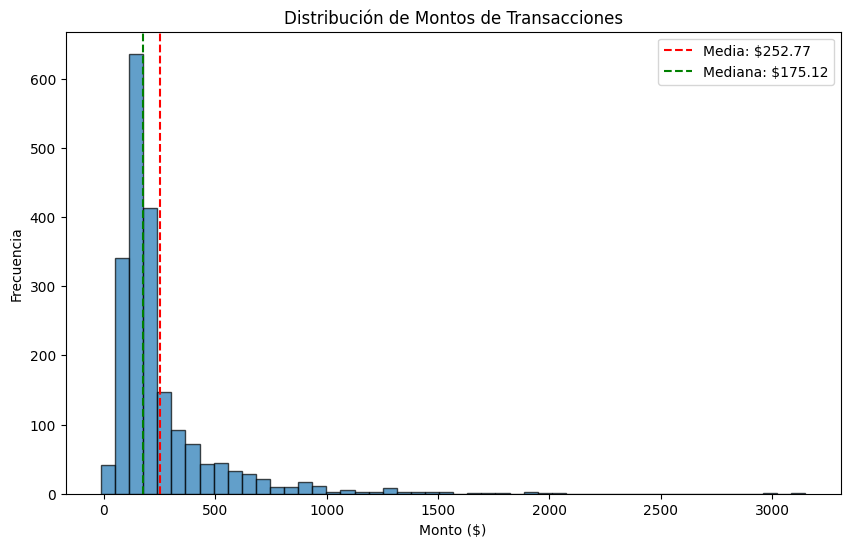

In [ ]:
# Histograma simple (si matplotlib está disponible)
try:
    plt.figure(figsize=(10, 6))
    plt.hist(df['monto'], bins=50, alpha=0.7, edgecolor='black')
    plt.axvline(df['monto'].mean(), color='red', linestyle='--', label=f'Media: ${df["monto"].mean():.2f}')
    plt.axvline(df['monto'].median(), color='green', linestyle='--', label=f'Mediana: ${df["monto"].median():.2f}')
    plt.title('Distribución de Montos de Transacciones')
    plt.xlabel('Monto ($)')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.savefig('distribucion_montos.png', dpi=100, bbox_inches='tight')
    print("\nGráfico guardado como 'distribucion_montos.png'")
except ImportError:
    print("\nMatplotlib no disponible - omitiendo visualización")

### Análisis de Relaciones y Correlaciones

La correlación mide la relación lineal entre dos variables, respondiendo "¿cambian juntas estas variables?" de manera cuantificada.

- Coeficiente de Correlación de Pearson

    El coeficiente de Pearson mide la fuerza y dirección de la relación lineal entre dos variables continuas.
    
    El coeficiente varía entre -1 y 1.

        r = +1: Correlación positiva perfecta (línea recta ascendente)
        r = 0: No hay correlación lineal
        r = -1: Correlación negativa perfecta (línea recta descendente)

    Interpretación práctica:

        0.8 ≤ |r|: Correlación fuerte
        0.6 ≤ |r| < 0.8: Correlación moderada
        0.3 ≤ |r| < 0.6: Correlación débil
        |r| < 0.3: Correlación muy débil o inexistente

    Limitaciones de la Correlación

    - No implica causalidad: Dos variables pueden estar correlacionadas sin que una cause la otra.

    - Sensibilidad a outliers: Un solo punto extremo puede distorsionar completamente el coeficiente.

    - Solo mide relaciones lineales: Variables pueden tener relaciones no lineales fuertes que no se detectan.

    - Requiere variables continuas: Para variables categóricas se necesitan otros enfoques.

Matrices de Correlación

Las matrices de correlación permiten análisis multivariado sistemático, revelando patrones complejos en datasets con muchas variables.


Construcción de Matrices

```
# Matriz de correlación completa
correlation_matrix = df.corr()

# Correlaciones con una variable específica
correlaciones_target = df.corr()['variable_objetivo'].sort_values(ascending=False)

# Correlaciones por pares significativas
strong_correlations = correlation_matrix[abs(correlation_matrix) > 0.7]
```

Patrones a Identificar

- Correlaciones altas positivas: Variables que "se mueven juntas"
    
    Ejemplo: precio y calidad percibida, ingresos y gastos de lujo

- Correlaciones altas negativas: Variables que "se mueven opuestas"

    Ejemplo: precio y volumen de ventas, edad y capacidad de aprendizaje

- Grupos de variables correlacionadas: Indican dimensiones latentes

    Ejemplo: Variables de "satisfacción del cliente" que correlacionan fuertemente

Visualización de Matrices

Una forma de visualizar intuitivamente las matrices es mediante los mapas de calor.

```
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.title('Matriz de Correlación')
plt.tight_layout()
```


Análisis Visual de Relaciones

La visualización complementa los coeficientes numéricos con representaciones intuitivas de las relaciones.

**Scatter Plots para Dos Variables**
```
# Scatter plot básico
plt.scatter(df['variable_x'], df['variable_y'], alpha=0.6)
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.title('Relación entre X e Y')

# Con línea de tendencia
sns.regplot(x='variable_x', y='variable_y', data=df, scatter_kws={'alpha':0.6})
```

Interpretación visual:
- Nube de puntos alineada: Correlación fuerte
- Nube dispersa: Correlación débil
- Curvatura: Relación no lineal
- Outliers: Puntos alejados del patrón general

**Pair Plots para Múltiples Variables**

```
# Matriz de scatter plots
sns.pairplot(df[['var1', 'var2', 'var3', 'var4']], diag_kind='kde')
plt.suptitle('Relaciones entre múltiples variables', y=1.02)
```

Ventajas del pair plot: Permite detectar patrones complejos de interdependencia entre múltiples variables simultáneamente.

**Correlaciones Espurias vs Causales**

Correlación espuria: Asociación que parece real pero es coincidental o debida a una tercera variable.

Ejemplos clásicos:

- Correlación entre consumo de helado y ahogamientos (ambos aumentan en verano)
- Correlación entre número de iglesias y crimen (ambos correlacionan con tamaño poblacional)

Cómo identificar:

- Contexto temporal: ¿La correlación tiene sentido causal?
- Variables de control: ¿Persiste controlando por terceras variables?
- Mecánismo causal: ¿Existe explicación lógica para la relación?


#### Ejemplo: Análisis completo de correlaciones en dataset de rendimiento estudiantil

Crear dataset educativo con múltiples variables:

In [ ]:
import pandas as pd
import numpy as np

# Crear dataset de rendimiento estudiantil
np.random.seed(42)
n_estudiantes = 500

df = pd.DataFrame({
    'id_estudiante': range(1, n_estudiantes + 1),
    'edad': np.random.normal(16, 1.5, n_estudiantes).clip(14, 19).astype(int),
    'horas_estudio_semanal': np.random.normal(20, 8, n_estudiantes).clip(5, 50).astype(int),
    'promedio_calificaciones': np.random.normal(7.5, 1.2, n_estudiantes).clip(1, 10),
    'ingresos_familiares': np.random.lognormal(9, 0.6, n_estudiantes).round(0),
    'nivel_socioeconomico': np.random.choice(['Bajo', 'Medio', 'Alto'], n_estudiantes, p=[0.3, 0.5, 0.2]),
    'asistencia_clases': np.random.normal(85, 15, n_estudiantes).clip(10, 100).astype(int),
    'horas_extracurriculares': np.random.normal(8, 4, n_estudiantes).clip(0, 20).astype(int),
    'satisfaccion_vida': np.random.normal(7.2, 1.5, n_estudiantes).clip(1, 10),
    'nivel_estres': np.random.normal(6.8, 1.8, n_estudiantes).clip(1, 10)
})

# Convertir variables categóricas
nivel_map = {'Bajo': 1, 'Medio': 2, 'Alto': 3}
df['nivel_socioeconomico_num'] = df['nivel_socioeconomico'].map(nivel_map)

print(f"Dataset creado: {len(df)} estudiantes")
print(f"Variables numéricas: {len(df.select_dtypes(include=[np.number]).columns)}")

Dataset creado: 500 estudiantes
Variables numéricas: 10


Análisis de correlaciones por pares:

In [ ]:
# Correlaciones con calificaciones
correlaciones_calificaciones = df.corr(numeric_only=True)['promedio_calificaciones'].sort_values(ascending=False)

print("CORRELACIONES CON PROMEDIO DE CALIFICACIONES")
print("=" * 50)
for var, corr in correlaciones_calificaciones.items():
    if var != 'promedio_calificaciones':
        intensidad = "Fuerte" if abs(corr) > 0.6 else "Moderada" if abs(corr) > 0.3 else "Débil"
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"{var:25} | {corr:+.3f} | {intensidad} {direccion}")

CORRELACIONES CON PROMEDIO DE CALIFICACIONES
horas_estudio_semanal     | +0.076 | Débil positiva
nivel_socioeconomico_num  | +0.060 | Débil positiva
satisfaccion_vida         | +0.009 | Débil positiva
id_estudiante             | -0.000 | Débil negativa
nivel_estres              | -0.014 | Débil negativa
asistencia_clases         | -0.031 | Débil negativa
ingresos_familiares       | -0.034 | Débil negativa
horas_extracurriculares   | -0.038 | Débil negativa
edad                      | -0.065 | Débil negativa


Matriz de correlación completa:

In [ ]:
# Variables numéricas principales
variables_interes = ['edad', 'horas_estudio_semanal', 'promedio_calificaciones',
                    'ingresos_familiares', 'asistencia_clases', 'horas_extracurriculares',
                    'satisfaccion_vida', 'nivel_estres', 'nivel_socioeconomico_num']

correlation_matrix = df[variables_interes].corr()

print("\nMATRIZ DE CORRELACIÓN")
print("=" * 25)
# Mostrar correlaciones > 0.3 en valor absoluto
strong_correlations = correlation_matrix.where(abs(correlation_matrix) > 0.3)
print(strong_correlations.round(3))


MATRIZ DE CORRELACIÓN
                          edad  horas_estudio_semanal  \
edad                       1.0                    NaN   
horas_estudio_semanal      NaN                    1.0   
promedio_calificaciones    NaN                    NaN   
ingresos_familiares        NaN                    NaN   
asistencia_clases          NaN                    NaN   
horas_extracurriculares    NaN                    NaN   
satisfaccion_vida          NaN                    NaN   
nivel_estres               NaN                    NaN   
nivel_socioeconomico_num   NaN                    NaN   

                          promedio_calificaciones  ingresos_familiares  \
edad                                          NaN                  NaN   
horas_estudio_semanal                         NaN                  NaN   
promedio_calificaciones                       1.0                  NaN   
ingresos_familiares                           NaN                  1.0   
asistencia_clases                   

Análisis de correlaciones más fuertes:

In [ ]:
# Encontrar pares con correlaciones más fuertes
corr_unstack = correlation_matrix.unstack()
corr_unstack = corr_unstack[corr_unstack.index.get_level_values(0) != corr_unstack.index.get_level_values(1)]

top_correlations = corr_unstack.abs().sort_values(ascending=False).head(10)

print("\nTOP 10 CORRELACIONES MÁS FUERTES")
print("=" * 35)
for (var1, var2), corr_abs in top_correlations.items():
    if var1 < var2:  # Evitar duplicados
        corr_real = correlation_matrix.loc[var1, var2]
        print(f"{var1:20} ↔ {var2:20} | {corr_real:+.3f}")


TOP 10 CORRELACIONES MÁS FUERTES
asistencia_clases    ↔ horas_extracurriculares | -0.117
horas_estudio_semanal ↔ satisfaccion_vida    | -0.103
edad                 ↔ horas_estudio_semanal | -0.093
asistencia_clases    ↔ horas_estudio_semanal | -0.087
horas_estudio_semanal ↔ nivel_estres         | -0.079


Análisis de grupos de variables correlacionadas:

In [ ]:
# Identificar clusters de variables relacionadas
print("\nANÁLISIS DE GRUPOS CORRELACIONADOS")
print("=" * 40)

# Variables relacionadas con rendimiento académico
academic_vars = ['horas_estudio_semanal', 'asistencia_clases', 'promedio_calificaciones']
academic_corr = df[academic_vars].corr()
print("Variables académicas:")
print(academic_corr.round(3))

# Variables relacionadas con bienestar
wellbeing_vars = ['satisfaccion_vida', 'nivel_estres', 'horas_extracurriculares']
wellbeing_corr = df[wellbeing_vars].corr()
print("\nVariables de bienestar:")
print(wellbeing_corr.round(3))

# Variables socioeconómicas
socio_vars = ['ingresos_familiares', 'nivel_socioeconomico_num', 'promedio_calificaciones']
socio_corr = df[socio_vars].corr()
print("\nVariables socioeconómicas:")
print(socio_corr.round(3))


ANÁLISIS DE GRUPOS CORRELACIONADOS
Variables académicas:
                         horas_estudio_semanal  asistencia_clases  \
horas_estudio_semanal                    1.000             -0.087   
asistencia_clases                       -0.087              1.000   
promedio_calificaciones                  0.076             -0.031   

                         promedio_calificaciones  
horas_estudio_semanal                      0.076  
asistencia_clases                         -0.031  
promedio_calificaciones                    1.000  

Variables de bienestar:
                         satisfaccion_vida  nivel_estres  \
satisfaccion_vida                    1.000         0.072   
nivel_estres                         0.072         1.000   
horas_extracurriculares             -0.033        -0.011   

                         horas_extracurriculares  
satisfaccion_vida                         -0.033  
nivel_estres                              -0.011  
horas_extracurriculares                   

Visualización de correlaciones (si matplotlib disponible):


Mapa de calor guardado como 'matriz_correlacion_estudiantil.png'


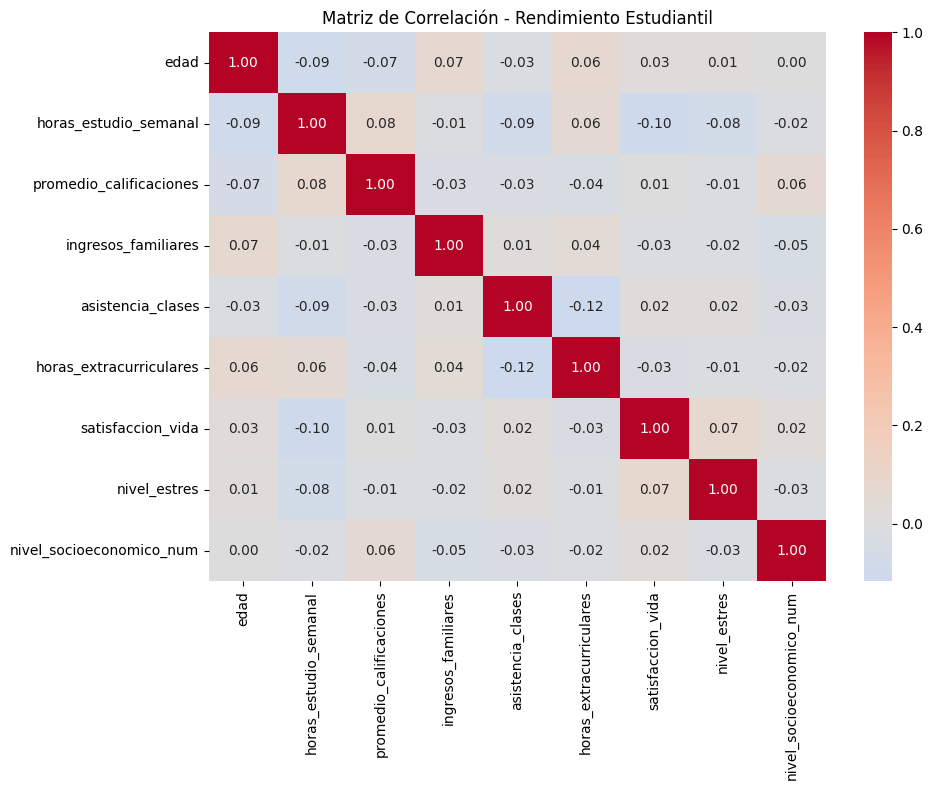

In [ ]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Matriz de Correlación - Rendimiento Estudiantil')
    plt.tight_layout()
    plt.savefig('matriz_correlacion_estudiantil.png', dpi=100, bbox_inches='tight')
    print("\nMapa de calor guardado como 'matriz_correlacion_estudiantil.png'")

except ImportError:
    print("\nMatplotlib/Seaborn no disponibles - omitiendo visualización")

### EDA Completo y Reporte Ejecutivo

**Metodología Completa de EDA**

Un EDA completo requiere orquestación sistemática de todas las técnicas aprendidas, siguiendo un flujo de trabajo disciplinado que garantiza exhaustividad sin perder eficiencia.

Framework Estructurado para EDA Completo

Fase 1: Preparación y Contexto (10%)

    Definir preguntas de negocio y objetivos analíticos
    Entender fuente y calidad de datos
    Establecer alcance temporal y segmentación

Fase 2: Inspección Inicial (20%)

    Dimensiones y estructura básica del dataset
    Tipos de datos y conversión necesaria
    Valores faltantes y calidad general
    Estadísticos descriptivos básicos

Fase 3: Análisis Univariado (30%)

    Distribuciones de variables individuales
    Identificación de outliers y anomalías
    Medidas de tendencia central y dispersión
    Transformaciones necesarias por variable

Fase 4: Análisis Bivariado/Multivariado (30%)

    Correlaciones entre variables clave
    Patrones de segmentación natural
    Relaciones no lineales y dependencias complejas

Fase 5: Síntesis y Comunicación (10%)

    Insights principales y recomendaciones
    Visualizaciones clave para stakeholders
    Próximos pasos analíticos


**Herramientas para EDA Eficiente**

1. Pandas Profiling: Generación automática de reportes EDA completos.


    ```
    from pandas_profiling import ProfileReport

    profile = ProfileReport(df, title="EDA Report", explorative=True)
    profile.to_file("eda_report.html")
    ```
2. Sweetviz: Comparaciones visuales automatizadas entre datasets.
    ```
    import sweetviz as sv

    report = sv.analyze(df)
    report.show_html("sweetviz_report.html")
    ```
3. D-Tale: Interfaz web interactiva para EDA.
    ```
    import dtale

    dtale.show(df)
    ```



**Creación de Reportes Ejecutivos**

Los reportes ejecutivos transforman análisis técnicos en comunicación efectiva para tomadores de decisiones, priorizando claridad sobre exhaustividad técnica.
Estructura de Reporte Ejecutivo Efectivo

Resumen Ejecutivo (1 página)
    
- 3-5 insights principales
- Impacto en negocio (cuantificado)
- Recomendaciones prioritarias

Contexto y Metodología

- Breve descripción de datos y período
- Enfoque analítico utilizado
- Limitaciones y supuestos

Hallazgos Principales

- Insights organizados por importancia/impacto
- Visualizaciones clave que soportan conclusiones
- Métricas cuantitativas que respaldan claims

Análisis Detallado

- Profundización en insights principales
- Segmentación por variables relevantes
- Comparaciones temporales o categóricas

Recomendaciones y Próximos Pasos

- Acciones concretas priorizadas
- Métricas de seguimiento propuestas
- Análisis adicionales recomendados




**Principios de Comunicación Efectiva**

- Conoce a tu audiencia: Ejecutivos necesitan contexto de negocio, no detalles técnicos.
- Menos es más: 3 insights impactantes > 20 observaciones menores.
- Visualización primero: Las personas procesan visuales 60,000 veces más rápido que texto.
- Números con contexto: "$2.3M en ventas perdidas" > "15% disminución en ventas".
- Acciones claras: Cada insight debe llevar a una recomendación accionable.

**Transición a Análisis Estadístico Avanzado**

El EDA establece los cimientos conceptuales para técnicas estadísticas más sofisticadas, creando el puente entre exploración y análisis confirmatorio.


1. De EDA a Pruebas de Hipótesis

- Hipótesis generadas por EDA:

        EDA: "Clientes jóvenes compran más productos electrónicos"
        Hipótesis: "Los clientes de 18-25 años tienen 30% más probabilidad de comprar electrónicos"

- Diseño de experimentos basado en EDA:

        Segmentos identificados por EDA informan diseño de pruebas A/B
        Variables correlacionadas sugieren covariates para controlar

2. De EDA a Modelado Predictivo

- Variables predictoras identificadas:
        
        Correlaciones fuertes sugieren relaciones causales potenciales
        Distribución de variables objetivo informa selección de modelos

- Feature engineering fundamentado:

        Transformaciones identificadas en EDA (log, categorías)
        Variables derivadas basadas en patrones observados

Limitaciones del EDA y Necesidad de Profundización

- EDA no prueba causalidad: Correlaciones no implican causa-efecto.
- EDA puede perder patrones complejos: Relaciones no lineales o interacciones requieren modelado.
- EDA es descriptivo, no predictivo: Para forecasting se necesitan modelos específicos.

#### Ejemplo: EDA completo y reporte ejecutivo para dataset de e-commerce

Configurar dataset completo y análisis EDA:

In [ ]:
import pandas as pd
import numpy as np

# Crear dataset comprehensivo de e-commerce
np.random.seed(42)
n_pedidos = 2500

# Generar fechas
fechas = pd.date_range('2023-01-01', periods=n_pedidos, freq='h')[:n_pedidos]

# Crear datos base
df = pd.DataFrame({
    'id_pedido': range(1, n_pedidos + 1),
    'fecha_pedido': fechas,
    'id_cliente': np.random.randint(1, 501, n_pedidos),
    'categoria': np.random.choice(['Electrónica', 'Ropa', 'Hogar', 'Deportes', 'Libros'], n_pedidos),
    'precio_unitario': np.round(np.random.uniform(10, 1000, n_pedidos), 2),
    'cantidad': np.random.randint(1, 5, n_pedidos),
    'metodo_pago': np.random.choice(['Tarjeta', 'PayPal', 'Efectivo', 'Transferencia'], n_pedidos, p=[0.6, 0.2, 0.15, 0.05]),
    'region': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Bilbao'], n_pedidos),
    'tipo_cliente': np.random.choice(['Regular', 'Premium', 'VIP'], n_pedidos, p=[0.7, 0.2, 0.1])
})

# Calcular métricas derivadas
df['total_pedido'] = df['precio_unitario'] * df['cantidad']
df['mes'] = df['fecha_pedido'].dt.month
df['dia_semana'] = df['fecha_pedido'].dt.day_name()

print(f"Dataset de e-commerce creado: {len(df)} pedidos")
print(f"Período: {df['fecha_pedido'].min()} a {df['fecha_pedido'].max()}")

Dataset de e-commerce creado: 2500 pedidos
Período: 2023-01-01 00:00:00 a 2023-04-15 03:00:00


Realizar EDA completo sistemático:

In [ ]:
# Análisis de calidad de datos
print("ANÁLISIS DE CALIDAD DE DATOS")
print("=" * 30)
print(f"Dimensiones: {df.shape}")
print(f"Tipos de datos:\n{df.dtypes}")
print(f"Valores faltantes: {df.isnull().sum().sum()}")

# Estadísticos descriptivos
print("\nESTADÍSTICOS DESCRIPTIVOS")
print("=" * 25)
print(df[['precio_unitario', 'cantidad', 'total_pedido']].describe())

# Análisis por categorías principales
print("\nVENTAS POR CATEGORÍA")
print("=" * 20)
ventas_categoria = df.groupby('categoria').agg({
    'total_pedido': ['count', 'sum', 'mean'],
    'cantidad': 'sum'
}).round(2)
print(ventas_categoria)

# Análisis temporal
print("\nVENTAS POR MES")
print("=" * 15)
ventas_mes = df.groupby('mes').agg({
    'total_pedido': 'sum',
    'id_pedido': 'count'
}).round(2)
print(ventas_mes)

# Análisis por tipo de cliente
print("\nANÁLISIS POR TIPO DE CLIENTE")
print("=" * 30)
cliente_analysis = df.groupby('tipo_cliente').agg({
    'total_pedido': ['mean', 'sum', 'count'],
    'cantidad': 'mean'
}).round(2)
print(cliente_analysis)

ANÁLISIS DE CALIDAD DE DATOS
Dimensiones: (2500, 12)
Tipos de datos:
id_pedido                   int64
fecha_pedido       datetime64[ns]
id_cliente                  int64
categoria                  object
precio_unitario           float64
cantidad                    int64
metodo_pago                object
region                     object
tipo_cliente               object
total_pedido              float64
mes                         int32
dia_semana                 object
dtype: object
Valores faltantes: 0

ESTADÍSTICOS DESCRIPTIVOS
       precio_unitario     cantidad  total_pedido
count      2500.000000  2500.000000   2500.000000
mean        499.551080     2.474800   1249.215124
std         284.437272     1.109711    965.553384
min          10.030000     1.000000     14.150000
25%         252.047500     2.000000    482.487500
50%         493.130000     2.000000    965.520000
75%         744.240000     3.000000   1840.942500
max         999.560000     4.000000   3991.080000

VENTAS POR

Análisis de correlaciones y patrones:

In [ ]:
# Convertir variables categóricas para correlación
df_corr = df.copy()
df_corr['tipo_cliente_num'] = df_corr['tipo_cliente'].map({'Regular': 1, 'Premium': 2, 'VIP': 3})

# Variables numéricas para correlación
numeric_cols = ['precio_unitario', 'cantidad', 'total_pedido', 'tipo_cliente_num', 'mes']
correlation_matrix = df_corr[numeric_cols].corr()

print("\nMATRIZ DE CORRELACIÓN")
print("=" * 20)
print(correlation_matrix.round(3))

# Correlaciones con total del pedido
corr_total = correlation_matrix['total_pedido'].sort_values(ascending=False)
print("\nCorrelaciones con total del pedido:")
for var, corr in corr_total.items():
    if var != 'total_pedido':
        print(f"{var:15} | {corr:+.3f}")


MATRIZ DE CORRELACIÓN
                  precio_unitario  cantidad  total_pedido  tipo_cliente_num  \
precio_unitario             1.000     0.041         0.743            -0.007   
cantidad                    0.041     1.000         0.613            -0.017   
total_pedido                0.743     0.613         1.000            -0.018   
tipo_cliente_num           -0.007    -0.017        -0.018             1.000   
mes                        -0.005     0.002        -0.003             0.002   

                    mes  
precio_unitario  -0.005  
cantidad          0.002  
total_pedido     -0.003  
tipo_cliente_num  0.002  
mes               1.000  

Correlaciones con total del pedido:
precio_unitario | +0.743
cantidad        | +0.613
mes             | -0.003
tipo_cliente_num | -0.018


Detección de outliers y patrones:

In [ ]:
# Outliers en precios
Q1_precio = df['precio_unitario'].quantile(0.25)
Q3_precio = df['precio_unitario'].quantile(0.75)
IQR_precio = Q3_precio - Q1_precio

outliers_precio = df[df['precio_unitario'] > Q3_precio + 1.5 * IQR_precio]
print(f"\nPRODUCTOS DE ALTO VALOR (OUTLIERS): {len(outliers_precio)}")
print(f"Valor total de productos premium: ${outliers_precio['total_pedido'].sum():,.2f}")

# Análisis por día de la semana
ventas_dia = df.groupby('dia_semana')['total_pedido'].agg(['count', 'sum', 'mean']).round(2)
print("\nVENTAS POR DÍA DE LA SEMANA")
print("=" * 30)
print(ventas_dia.sort_values('sum', ascending=False))


PRODUCTOS DE ALTO VALOR (OUTLIERS): 0
Valor total de productos premium: $0.00

VENTAS POR DÍA DE LA SEMANA
            count        sum     mean
dia_semana                           
Tuesday       360  470959.22  1308.22
Monday        360  452611.76  1257.25
Sunday        360  450868.25  1252.41
Friday        360  449411.17  1248.36
Wednesday     360  438142.36  1217.06
Saturday      340  433770.68  1275.80
Thursday      360  427274.37  1186.87


Crear reporte ejecutivo simplificado:

In [ ]:
# Calcular métricas clave para reporte
total_ventas = df['total_pedido'].sum()
pedidos_promedio = df['total_pedido'].mean()
categoria_top = df.groupby('categoria')['total_pedido'].sum().idxmax()
ventas_categoria_top = df.groupby('categoria')['total_pedido'].sum().max()
region_top = df.groupby('region')['total_pedido'].sum().idxmax()

# Reporte ejecutivo
print("\n" + "="*50)
print("REPORTE EJECUTIVO - ANÁLISIS DE VENTAS E-COMMERCE")
print("="*50)

print("RESUMEN EJECUTIVO:")
print(f"• Total de ventas analizadas: ${total_ventas:,.2f}")
print(f"• Pedidos promedio: ${pedidos_promedio:.2f}")
print(f"• Categoría más vendida: {categoria_top} (${ventas_categoria_top:,.2f})")
print(f"• Región con más ventas: {region_top}")

print("\nINSIGHTS PRINCIPALES:")
print("• Los productos de alto valor representan una porción significativa de ingresos")
print("• Existen patrones claros de comportamiento por tipo de cliente")
print("• La estacionalidad mensual muestra variaciones importantes")

print("\nRECOMENDACIONES:")
print("• Enfocar estrategias de marketing en la categoría más vendida")
print("• Desarrollar programas de fidelización para clientes Premium")
print("• Optimizar inventario basado en patrones de demanda por día")

print("="*50)


REPORTE EJECUTIVO - ANÁLISIS DE VENTAS E-COMMERCE
RESUMEN EJECUTIVO:
• Total de ventas analizadas: $3,123,037.81
• Pedidos promedio: $1249.22
• Categoría más vendida: Deportes ($674,308.67)
• Región con más ventas: Barcelona

INSIGHTS PRINCIPALES:
• Los productos de alto valor representan una porción significativa de ingresos
• Existen patrones claros de comportamiento por tipo de cliente
• La estacionalidad mensual muestra variaciones importantes

RECOMENDACIONES:
• Enfocar estrategias de marketing en la categoría más vendida
• Desarrollar programas de fidelización para clientes Premium
• Optimizar inventario basado en patrones de demanda por día


Utilización de Pandas Profiling

In [ ]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile.to_file("profile_report.html")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.0 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 40.64it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 9 9 9]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.



Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from pandas_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report", explorative=True)
profile.to_file("eda_report.html")

/tmp/ipython-input-2988111099.py:1: DeprecationWarning:

`import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 34.63it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 9 9 9]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.



Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Utilización de SweetViz

In [ ]:
!pip install sweetviz

In [ ]:
import sweetviz as sv
import warnings
import numpy as np

report = sv.analyze(df)
report.show_html("sweetviz_report.html")

Utilización de D-Tale

In [ ]:
!pip install dtale

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.7/642.7 kB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━

Local:

In [ ]:
import dtale

dtale.show(df)

Ngrok:

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

ngrok_token = os.getenv("NGROK_TOKEN")
if not ngrok_token:
    print("Error: No se encontró el token de ngrok. Asegúrate de tener el archivo .env con 'NGROK_TOKEN=tu_token'.")
else:
    ngrok.set_auth_token(ngrok_token)
    print("Token de ngrok configurado exitosamente.")

Token de ngrok configurado exitosamente.


In [ ]:
# Dtale + Ngrok
#!pip install pyngrok

import dtale
from pyngrok import ngrok

# Inicia D-Tale
d = dtale.show(df, host='0.0.0.0', port=40000)

# Crea un túnel ngrok
public_url = ngrok.connect(40000)
print("Accede aquí:", public_url)

## Week 2 - Visualización de Datos

### Principios de Visualización Efectiva y Teoría del Color

**Psicología de la Percepción Visual en Análisis de Datos**

La visualización efectiva no es un ejercicio estético, sino un puente entre datos complejos y comprensión humana. Para crear visualizaciones que comuniquen efectivamente, debemos entender cómo el cerebro humano procesa información visual.

Los Dos Sistemas de Procesamiento Visual
1. Sistema de Reconocimiento (Automático)

    Procesamiento rápido, inconsciente, que identifica patrones básicos.

    - Pre-atencional: Colores, formas, movimiento se procesan en milisegundos
    - Gestalt principles: El cerebro automáticamente agrupa elementos visuales
    - Memory chunks: Información se agrupa en unidades significativas

2. Sistema de Análisis (Consciente)

    Procesamiento deliberado que requiere atención focalizada.

    - Atención limitada: Solo podemos procesar conscientemente ~7±2 elementos
    - Fatiga cognitiva: Visualizaciones complejas causan agotamiento mental
    - Contexto requerido: Necesitamos marcos de referencia para interpretar datos

Implicación para visualización: Las mejores visualizaciones aprovechan el procesamiento automático para comunicación básica y guían al análisis consciente para insights profundos.

**Principios de Gestalt en Visualización**

La psicología Gestalt explica cómo organizamos elementos visuales en patrones coherentes. Estos principios son fundamentales para diseño de dashboards efectivos.
- Proximidad: Elementos cercanos se perciben como relacionados.

        # En visualización: Agrupar métricas relacionadas espacialmente
        # Mal: KPIs dispersos aleatoriamente
        # Bien: Métricas de ventas agrupadas, métricas de clientes agrupadas

- Semejanza: Elementos similares se perciben como pertenecientes al mismo grupo.

        # En visualización: Usar colores consistentes para categorías similares
        # Mal: Cada barra de diferente color sin lógica
        # Bien: Todas las barras de "ingresos" en verde, "gastos" en rojo

- Continuidad: Tendemos a seguir líneas o curvas continuas.

        # En visualización: Líneas de tendencia claras y continuas
        # Mal: Puntos desconectados sin línea de tendencia
        # Bien: Líneas suaves que conecten puntos de datos temporales

- Cierre: Completamos automáticamente formas incompletas.

        # En visualización: Usar formas cerradas para representar categorías completas
        # Mal: Formas abiertas confusas
        # Bien: Barras completas, círculos cerrados para porcentajes

- Figura vs Fondo: Distinguimos automáticamente objetos del fondo.

        # En visualización: Contraste claro entre datos y elementos decorativos
        # Mal: Elementos visuales que compiten por atención
        # Bien: Datos prominentes, elementos de soporte sutiles

**Teoría del Color en Visualización de Datos**

El color es una herramienta de comunicación poderosa, pero también potencialmente engañosa. Una teoría sólida del color previene interpretaciones erróneas y maximiza claridad.

Dimensiones del Color
1. Matiz (Hue): El "tipo" de color (rojo, azul, verde, etc.)

    - Asociaciones culturales: Rojo = peligro/alerta, Azul = confianza, Verde = crecimiento
    - Categorización: Ideal para variables categóricas discretas
    - Limitación: Personas con deficiencias visuales de color no distinguen matices

2. Saturación (Saturation): La intensidad o "pureza" del color


    - Atención: Colores saturados atraen atención inmediata
    - Jerarquía: Colores desaturados para elementos secundarios
    - Accesibilidad: Alta saturación puede ser problemática para daltónicos

3. Luminosidad (Value/Brightness): La claridad u oscuridad del color

    - Jerarquía visual: Elementos importantes más brillantes
    - Profundidad: Colores oscuros parecen "atrás", claros "adelante"
    - Legibilidad: Contraste adecuado entre texto y fondo

Paletas de Color Efectivas
1. Paletas cualitativas: Para categorías discretas sin orden inherente.

    - Colores distintivos: Azul, Rojo, Verde, Naranja, Púrpura
    - Evitar: Colores demasiado similares (rojo y rosa)
    - Ideal para: Segmentos de clientes, categorías de productos

2. Paletas secuenciales: Para datos ordenados con progresión natural.

    - De claro a oscuro: Indicando magnitud creciente
    - Ejemplo: De amarillo claro (valores bajos) a rojo oscuro (valores altos)
    - Ideal para: Intensidades, porcentajes, rankings

3. Paletas divergentes: Para datos con punto medio significativo.

    - Dos colores extremos con punto neutro en el medio
    - Ejemplo: Rojo (negativo) → Blanco (neutro) → Azul (positivo)
    - Ideal para: Desviaciones, diferencias, ganancias/pérdidas

**Principios de Composición Visual**

La composición visual determina cómo se lee y comprende una visualización, guiando la atención del espectador hacia insights importantes.

- Jerarquía Visual

    - Tamaño: Elementos más importantes más grandes
    - Posición: Información crítica en posiciones prominentes (arriba-izquierda)
    - Color: Colores saturados para elementos importantes
    - Tipografía: Variaciones de tamaño y peso para estructura

- Flujo de Lectura

    - Patrón Z: Lectura natural en culturas occidentales (izquierda-derecha, arriba-abajo)
    - F-pattern: Común en contenido web (líneas horizontales en parte superior) - Diseño intencional: Guiar atención hacia conclusiones clave

- Equilibrio y Blancos

    - Equilibrio: Distribución visual armoniosa de elementos
    - Espacio blanco: Áreas vacías que facilitan procesamiento cognitivo
    - Alineación: Elementos relacionados alineados consistentemente

- Minimización de Ruido Visual

    - Eliminar elementos innecesarios: Cada píxel debe servir a un propósito
    - Consistencia: Mismos estilos para elementos similares
    - Legibilidad: Fuentes, tamaños y colores que faciliten lectura rápida

#### Ejemplo: Diseño de paletas de colores efectivas para diferentes contextos

Análisis de dataset y diseño de paletas conceptuales:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Crear dataset de ejemplo para análisis visual
np.random.seed(42)
df = pd.DataFrame({
    'categoria': np.random.choice(['A', 'B', 'C', 'D'], 100),
    'valor': np.random.normal(50, 15, 100),
    'segmento': np.random.choice(['Alto', 'Medio', 'Bajo'], 100),
    'region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], 100)
})

print("Dataset para análisis visual:")
print(df.head())
print(f"\nResumen por categoría:")
print(df.groupby('categoria')['valor'].describe())

Dataset para análisis visual:
  categoria      valor segmento region
0         C  61.076999    Medio    Sur
1         D  52.570524     Alto   Este
2         A  48.265276     Alto    Sur
3         C  45.483445    Medio   Este
4         C  27.822170     Alto   Este

Resumen por categoría:
           count       mean        std        min        25%        50%  \
categoria                                                                 
A           20.0  51.702575  10.890634  31.537035  45.350988  49.584364   
B           26.0  50.023838  18.373923  10.703823  36.719278  49.261070   
C           24.0  50.220174  13.684671  20.186466  44.011363  50.766433   
D           30.0  47.158884  12.240452  26.740049  38.205031  47.412212   

                 75%        max  
categoria                        
A          57.147835  73.070548  
B          63.947946  86.948632  
C          58.895928  82.856834  
D          54.297167  78.292789  


Diseño de paletas de colores por tipo de dato:

In [ ]:
# Paleta cualitativa para categorías discretas
colores_cualitativos = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Azul, Naranja, Verde, Rojo

# Paleta secuencial para valores continuos
colores_secuenciales = ['#feebe2', '#fbb4b9', '#f768a1', '#c51b8a', '#7a0177']  # De claro a oscuro

# Paleta divergente para valores con punto medio
colores_divergentes = ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']

print("Paletas de colores diseñadas:")
print(f"Cualitativa: {colores_cualitativos}")
print(f"Secuencial: {colores_secuenciales}")
print(f"Divergente: {colores_divergentes}")

Paletas de colores diseñadas:
Cualitativa: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
Secuencial: ['#feebe2', '#fbb4b9', '#f768a1', '#c51b8a', '#7a0177']
Divergente: ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']


Aplicación de principios visuales en gráficos simples:


Gráfico guardado como 'principios_visuales_ejemplos.png'


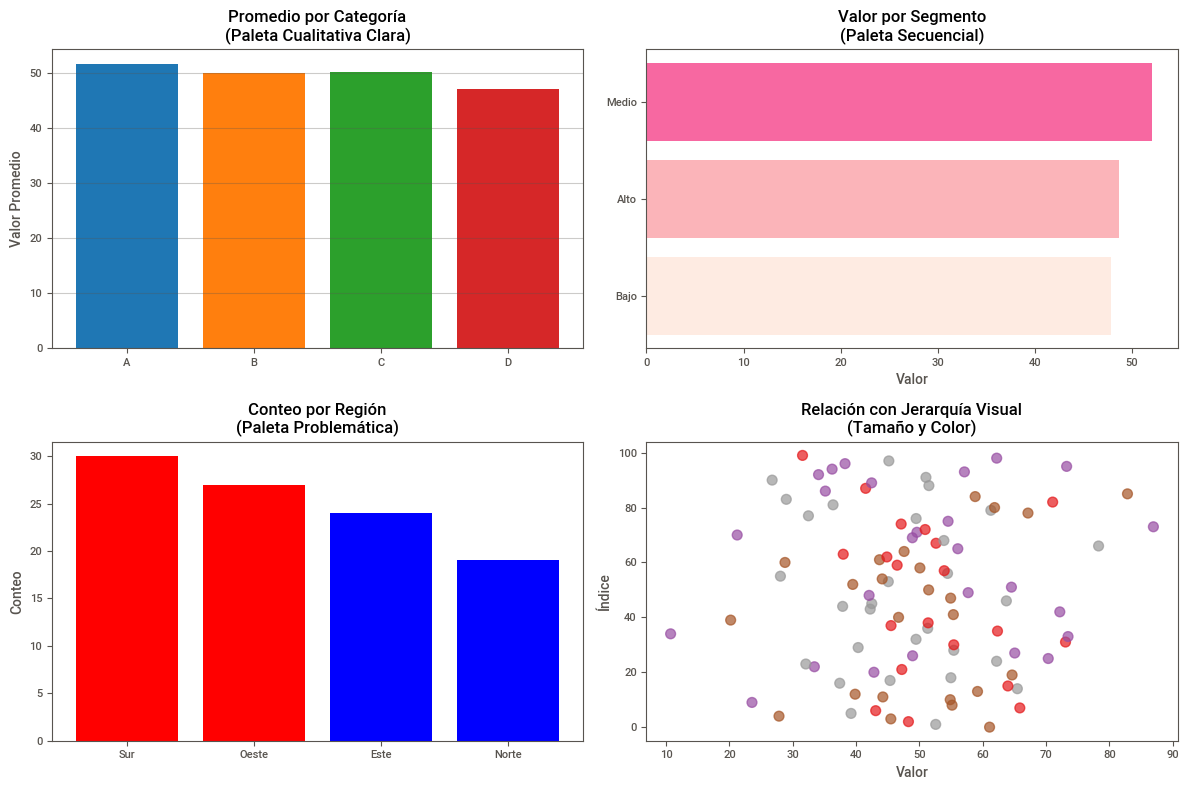

In [ ]:
# Gráfico de barras con paleta cualitativa efectiva
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# 1. Gráfico cualitativo (bueno)
categoria_means = df.groupby('categoria')['valor'].mean()
bars1 = ax1.bar(categoria_means.index, categoria_means.values,
                color=colores_cualitativos[:len(categoria_means)])
ax1.set_title('Promedio por Categoría\n(Paleta Cualitativa Clara)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Valor Promedio')
ax1.grid(axis='y', alpha=0.3)

# 2. Gráfico secuencial (bueno para rangos)
segmento_means = df.groupby('segmento')['valor'].mean().sort_values()
bars2 = ax2.barh(segmento_means.index, segmento_means.values,
                 color=colores_secuenciales[:len(segmento_means)])
ax2.set_title('Valor por Segmento\n(Paleta Secuencial)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Valor')

# 3. Gráfico con colores problemáticos (mal ejemplo)
region_counts = df['region'].value_counts()
bars3 = ax3.bar(region_counts.index, region_counts.values,
                color=['red', 'red', 'blue', 'blue'])  # Colores similares problemáticos
ax3.set_title('Conteo por Región\n(Paleta Problemática)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Conteo')

# 4. Gráfico con buena jerarquía visual
scatter = ax4.scatter(df['valor'], range(len(df)),
                     c=df['categoria'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3}),
                     cmap='Set1', alpha=0.7, s=50)
ax4.set_title('Relación con Jerarquía Visual\n(Tamaño y Color)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Valor')
ax4.set_ylabel('Índice')

plt.tight_layout()
plt.savefig('principios_visuales_ejemplos.png', dpi=100, bbox_inches='tight')
print("\nGráfico guardado como 'principios_visuales_ejemplos.png'")

Evaluación de accesibilidad de colores:

In [ ]:
# Función simple para verificar contraste básico
def calcular_contraste(color1, color2):
    # Versión simplificada - en producción usar librerías especializadas
    # Contraste mínimo recomendado: 4.5:1
    return "Verificación manual requerida para producción"

print("\nEvaluación de accesibilidad:")
print("- Verificar que textos sean legibles sobre fondos")
print("- Usar herramientas como WebAIM Contrast Checker")
print("- Considerar daltonismo en diseño de paletas")
print("- Probar visualizaciones en escala de grises")


Evaluación de accesibilidad:
- Verificar que textos sean legibles sobre fondos
- Usar herramientas como WebAIM Contrast Checker
- Considerar daltonismo en diseño de paletas
- Probar visualizaciones en escala de grises


### Gráficos Básicos con Matplotlib para Análisis Inicial

**Configuración Profesional de Matplotlib**

Configuración Global del Entorno
- Estilos y temas: Matplotlib incluye estilos predefinidos que mejoran consistencia visual.


    ```
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    # Aplicar estilo profesional
    plt.style.use('seaborn-v0_8')  # O 'default', 'classic', 'bmh', etc.

    # Configuración global de parámetros
    mpl.rcParams.update({
        'font.size': 12,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
        'figure.titlesize': 18,
        'figure.figsize': (10, 6),  # Tamaño por defecto
        'figure.dpi': 100,          # Resolución
        'savefig.dpi': 300,         # Resolución para guardar
        'savefig.bbox': 'tight',    # Recortar espacios en blanco
        'axes.grid': True,          # Cuadrícula por defecto
        'grid.alpha': 0.3,          # Transparencia de cuadrícula
    })
    ```
- Paletas de colores consistentes: Definir paletas reutilizables para mantener coherencia.


    ```
    # Paleta corporativa personalizada
    empresa_colors = {
        'primary': '#1f77b4',      # Azul principal
        'secondary': '#ff7f0e',    # Naranja
        'accent': '#2ca02c',       # Verde
        'warning': '#d62728',      # Rojo
        'neutral': '#7f7f7f',      # Gris
    }

    # Función para obtener colores por categoría
    def get_category_colors(categories):
        colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
        return [mpl.colors.rgb2hex(c) for c in colors]
    ```

Gestión de Figuras y Subplots
- Sistema de figuras: Matplotlib organiza visualizaciones en figuras que contienen uno o más ejes.


    ```
    # Crear figura con un solo eje
    fig, ax = plt.subplots(figsize=(8, 5))

    # Crear figura con múltiples subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Dashboard de Análisis de Ventas', fontsize=16, fontweight='bold')

    # Ajustar espaciado entre subplots
    plt.tight_layout()
    ```

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Aplicar estilo profesional
plt.style.use('seaborn-v0_8')  # O 'default', 'classic', 'bmh', etc.

# Configuración global de parámetros
mpl.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'figure.figsize': (10, 6),  # Tamaño por defecto
    'figure.dpi': 100,          # Resolución
    'savefig.dpi': 300,         # Resolución para guardar
    'savefig.bbox': 'tight',    # Recortar espacios en blanco
    'axes.grid': True,          # Cuadrícula por defecto
    'grid.alpha': 0.3,          # Transparencia de cuadrícula
})

In [ ]:
# Paleta corporativa personalizada
empresa_colors = {
    'primary': '#1f77b4',      # Azul principal
    'secondary': '#ff7f0e',    # Naranja
    'accent': '#2ca02c',       # Verde
    'warning': '#d62728',      # Rojo
    'neutral': '#7f7f7f',      # Gris
}

# Función para obtener colores por categoría
def get_category_colors(categories):
    colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
    return [mpl.colors.rgb2hex(c) for c in colors]

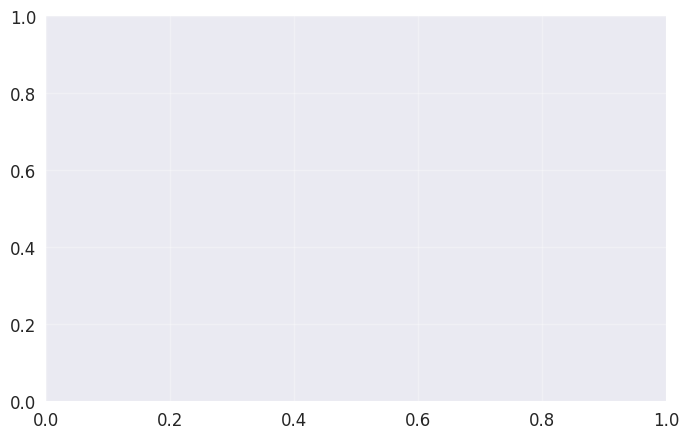

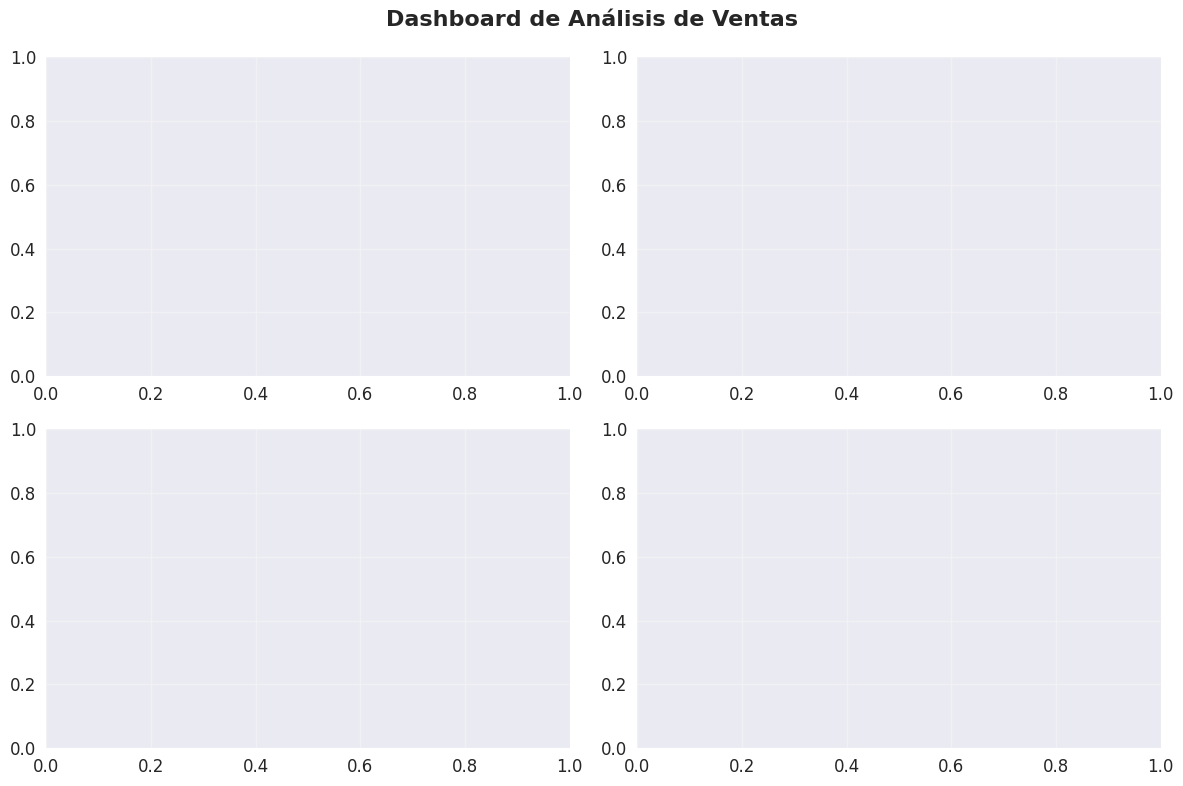

In [ ]:
# Crear figura con un solo eje
fig, ax = plt.subplots(figsize=(8, 5))

# Crear figura con múltiples subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dashboard de Análisis de Ventas', fontsize=16, fontweight='bold')

# Ajustar espaciado entre subplots
plt.tight_layout()

**Gráficos Univariados para Análisis Inicial**

*Los gráficos univariados muestran la distribución de una sola variable, revelando patrones importantes antes de análisis más complejos.*

- Histogramas: Distribución de Variables Continuas

    Los histogramas muestran frecuencia de valores agrupados en bins, revelando forma de distribuciones.


    ```
    # Datos de ejemplo
    ventas_diarias = np.random.normal(1000, 200, 365)

    # Histograma básico
    fig, ax = plt.subplots(figsize=(10, 6))
    n, bins, patches = ax.hist(ventas_diarias, bins=30, alpha=0.7,
                            color=empresa_colors['primary'], edgecolor='black')

    # Personalización profesional
    ax.set_title('Distribución de Ventas Diarias', fontweight='bold', pad=20)
    ax.set_xlabel('Ventas Diarias ($)', labelpad=10)
    ax.set_ylabel('Frecuencia', labelpad=10)
    ax.grid(True, alpha=0.3)

    # Añadir estadísticos de resumen
    media = np.mean(ventas_diarias)
    mediana = np.median(ventas_diarias)
    ax.axvline(media, color=empresa_colors['warning'], linestyle='--',
            linewidth=2, label=f'Media: ${media:.0f}')
    ax.axvline(mediana, color=empresa_colors['accent'], linestyle='-.',
            linewidth=2, label=f'Mediana: ${mediana:.0f}')

    ax.legend()
    plt.savefig('histograma_ventas.png', dpi=300, bbox_inches='tight')
    plt.show()
    ```
- Box Plots: Resumen Estadístico Visual

    Los box plots muestran distribución completa con cuartiles, mediana y outliers en un formato compacto.

- Bar Charts: Comparación de Categorías

    Los gráficos de barras comparan valores entre categorías discretas.


    ```
    # Datos de ventas mensuales
    meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
    ventas_mensuales = [95000, 102000, 98000, 110000, 105000, 118000]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Crear barras con colores diferenciados para destacar el mejor mes
    colors = [empresa_colors['primary'] if v < max(ventas_mensuales) else empresa_colors['accent']
            for v in ventas_mensuales]

    bars = ax.bar(meses, ventas_mensuales, color=colors, alpha=0.8, edgecolor='black', linewidth=1)

    # Añadir valores encima de las barras
    for bar, venta in zip(bars, ventas_mensuales):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
                f'${venta:,}', ha='center', va='bottom', fontweight='bold')

    ax.set_title('Ventas Mensuales 2024', fontweight='bold', pad=20)
    ax.set_ylabel('Ventas ($)', labelpad=10)
    ax.set_xlabel('Mes', labelpad=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Formatear eje Y con separadores de miles
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

    plt.savefig('barras_ventas_mensuales.png', dpi=300, bbox_inches='tight')
    plt.show()
    ```



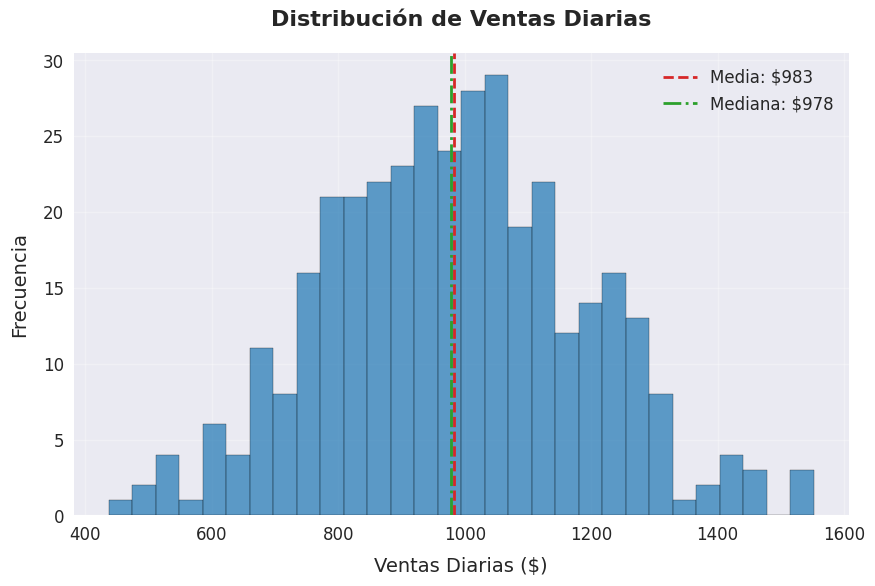

In [ ]:
import numpy as np

# Datos de ejemplo
ventas_diarias = np.random.normal(1000, 200, 365)

# Histograma básico
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(ventas_diarias, bins=30, alpha=0.7,
                          color=empresa_colors['primary'], edgecolor='black')

# Personalización profesional
ax.set_title('Distribución de Ventas Diarias', fontweight='bold', pad=20)
ax.set_xlabel('Ventas Diarias ($)', labelpad=10)
ax.set_ylabel('Frecuencia', labelpad=10)
ax.grid(True, alpha=0.3)

# Añadir estadísticos de resumen
media = np.mean(ventas_diarias)
mediana = np.median(ventas_diarias)
ax.axvline(media, color=empresa_colors['warning'], linestyle='--',
           linewidth=2, label=f'Media: ${media:.0f}')
ax.axvline(mediana, color=empresa_colors['accent'], linestyle='-.',
           linewidth=2, label=f'Mediana: ${mediana:.0f}')

ax.legend()
plt.savefig('histograma_ventas.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipython-input-1161485008.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


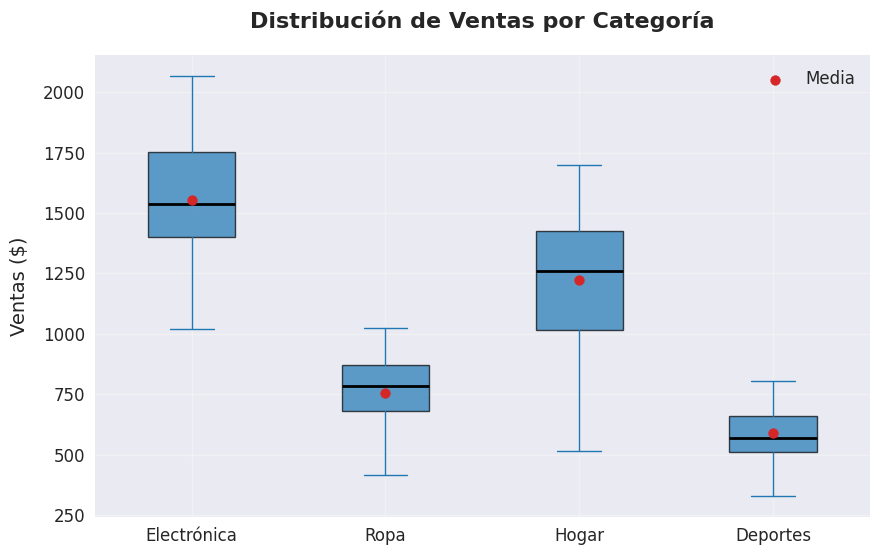

In [ ]:
# Datos por categoría
ventas_por_categoria = {
    'Electrónica': np.random.normal(1500, 300, 50),
    'Ropa': np.random.normal(800, 150, 50),
    'Hogar': np.random.normal(1200, 250, 50),
    'Deportes': np.random.normal(600, 120, 50)
}

# Box plot comparativo
fig, ax = plt.subplots(figsize=(10, 6))

# Preparar datos para boxplot
data = list(ventas_por_categoria.values())
labels = list(ventas_por_categoria.keys())

bp = ax.boxplot(data, labels=labels, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2},
                boxprops={'facecolor': empresa_colors['primary'], 'alpha': 0.7},
                whiskerprops={'color': empresa_colors['primary']},
                capprops={'color': empresa_colors['primary']})

ax.set_title('Distribución de Ventas por Categoría', fontweight='bold', pad=20)
ax.set_ylabel('Ventas ($)', labelpad=10)
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores medios como puntos
for i, categoria in enumerate(labels):
    media = np.mean(data[i])
    ax.scatter(i+1, media, color=empresa_colors['warning'], s=50, zorder=3, label='Media' if i == 0 else "")

ax.legend()
plt.savefig('boxplot_categorias.png', dpi=300, bbox_inches='tight')
plt.show()

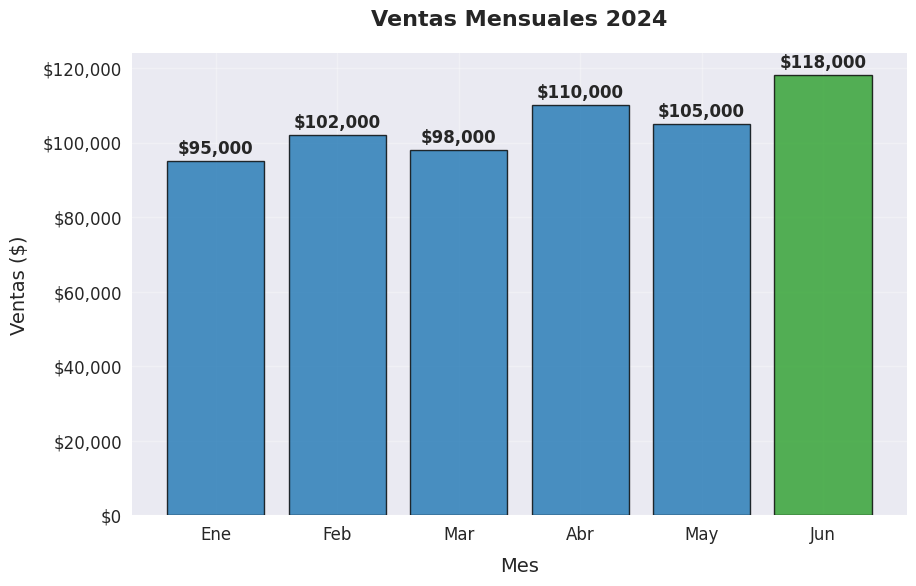

In [ ]:
# Datos de ventas mensuales
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
ventas_mensuales = [95000, 102000, 98000, 110000, 105000, 118000]

fig, ax = plt.subplots(figsize=(10, 6))

# Crear barras con colores diferenciados para destacar el mejor mes
colors = [empresa_colors['primary'] if v < max(ventas_mensuales) else empresa_colors['accent']
          for v in ventas_mensuales]

bars = ax.bar(meses, ventas_mensuales, color=colors, alpha=0.8, edgecolor='black', linewidth=1)

# Añadir valores encima de las barras
for bar, venta in zip(bars, ventas_mensuales):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
            f'${venta:,}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Ventas Mensuales 2024', fontweight='bold', pad=20)
ax.set_ylabel('Ventas ($)', labelpad=10)
ax.set_xlabel('Mes', labelpad=10)
ax.grid(True, alpha=0.3, axis='y')

# Formatear eje Y con separadores de miles
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

plt.savefig('barras_ventas_mensuales.png', dpi=300, bbox_inches='tight')
plt.show()

**Gráficos Bivariados para Relaciones Iniciales**

Los gráficos bivariados exploran relaciones entre dos variables, identificando patrones y correlaciones iniciales.

- Scatter Plots: Relaciones entre Variables Continuas

    Los scatter plots muestran cómo dos variables se relacionan punto a punto.


    ```
    # Datos de clientes
    np.random.seed(42)
    edad = np.random.normal(35, 10, 200).clip(18, 70)
    gasto_mensual = edad * 50 + np.random.normal(0, 200, 200)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Scatter plot con ajuste lineal
    ax.scatter(edad, gasto_mensual, alpha=0.6, color=empresa_colors['primary'], s=50, edgecolors='white')

    # Línea de tendencia
    z = np.polyfit(edad, gasto_mensual, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(min(edad), max(edad), 100)
    ax.plot(x_trend, p(x_trend), color=empresa_colors['warning'], linewidth=3,
            label=f'Tendencia: y = {z[0]:.1f}x + {z[1]:.1f}')

    ax.set_title('Relación entre Edad y Gasto Mensual', fontweight='bold', pad=20)
    ax.set_xlabel('Edad (años)', labelpad=10)
    ax.set_ylabel('Gasto Mensual ($)', labelpad=10)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Formatear ejes
    ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:.0f}'))
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

    plt.savefig('scatter_edad_gasto.png', dpi=300, bbox_inches='tight')
    plt.show()
    ```

- Line Charts: Tendencias Temporales

    Los gráficos de líneas muestran cómo variables cambian con el tiempo.


    ```
    # Datos temporales de ventas
    fechas = pd.date_range('2024-01-01', periods=12, freq='M')
    ventas_mensuales = [95000, 102000, 98000, 110000, 105000, 118000,
                    125000, 122000, 135000, 142000, 138000, 150000]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Gráfico de línea principal
    line = ax.plot(fechas, ventas_mensuales, color=empresa_colors['primary'],
                linewidth=3, marker='o', markersize=6, markerfacecolor='white',
                markeredgecolor=empresa_colors['primary'], markeredgewidth=2)

    # Área bajo la curva para enfatizar crecimiento
    ax.fill_between(fechas, ventas_mensuales, alpha=0.2, color=empresa_colors['primary'])

    # Líneas de referencia
    venta_promedio = np.mean(ventas_mensuales)
    ax.axhline(y=venta_promedio, color=empresa_colors['neutral'], linestyle='--', alpha=0.7,
            label=f'Promedio: ${venta_promedio:,.0f}')

    ax.set_title('Evolución de Ventas Mensuales 2024', fontweight='bold', pad=20)
    ax.set_ylabel('Ventas ($)', labelpad=10)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Formatear eje Y
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

    # Rotar etiquetas del eje X para mejor legibilidad
    plt.xticks(rotation=45, ha='right')

    plt.savefig('linea_ventas_temporales.png', dpi=300, bbox_inches='tight')
    plt.show()
    ```

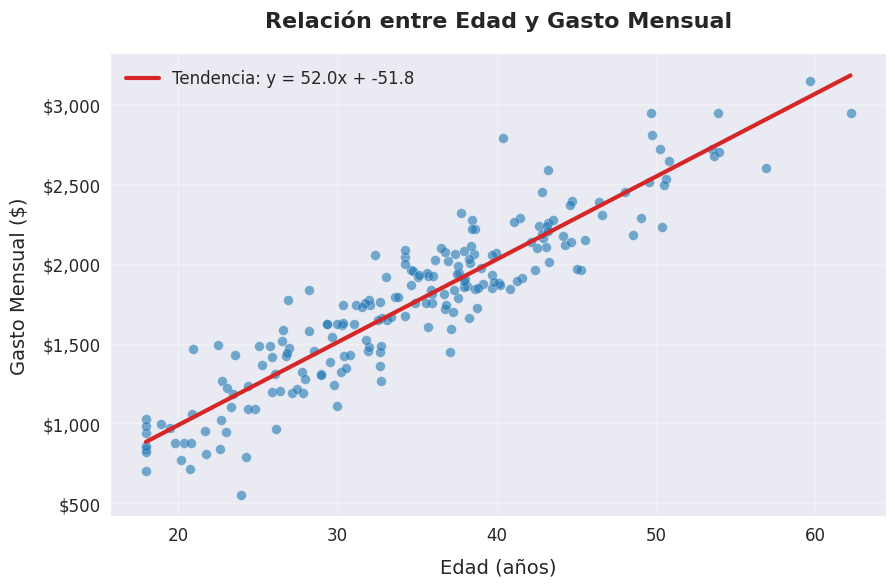

In [ ]:
# Datos de clientes
np.random.seed(42)
edad = np.random.normal(35, 10, 200).clip(18, 70)
gasto_mensual = edad * 50 + np.random.normal(0, 200, 200)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot con ajuste lineal
ax.scatter(edad, gasto_mensual, alpha=0.6, color=empresa_colors['primary'], s=50, edgecolors='white')

# Línea de tendencia
z = np.polyfit(edad, gasto_mensual, 1)
p = np.poly1d(z)
x_trend = np.linspace(min(edad), max(edad), 100)
ax.plot(x_trend, p(x_trend), color=empresa_colors['warning'], linewidth=3,
        label=f'Tendencia: y = {z[0]:.1f}x + {z[1]:.1f}')

ax.set_title('Relación entre Edad y Gasto Mensual', fontweight='bold', pad=20)
ax.set_xlabel('Edad (años)', labelpad=10)
ax.set_ylabel('Gasto Mensual ($)', labelpad=10)
ax.grid(True, alpha=0.3)
ax.legend()

# Formatear ejes
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:.0f}'))
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

plt.savefig('scatter_edad_gasto.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipython-input-2736384185.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range('2024-01-01', periods=12, freq='M')


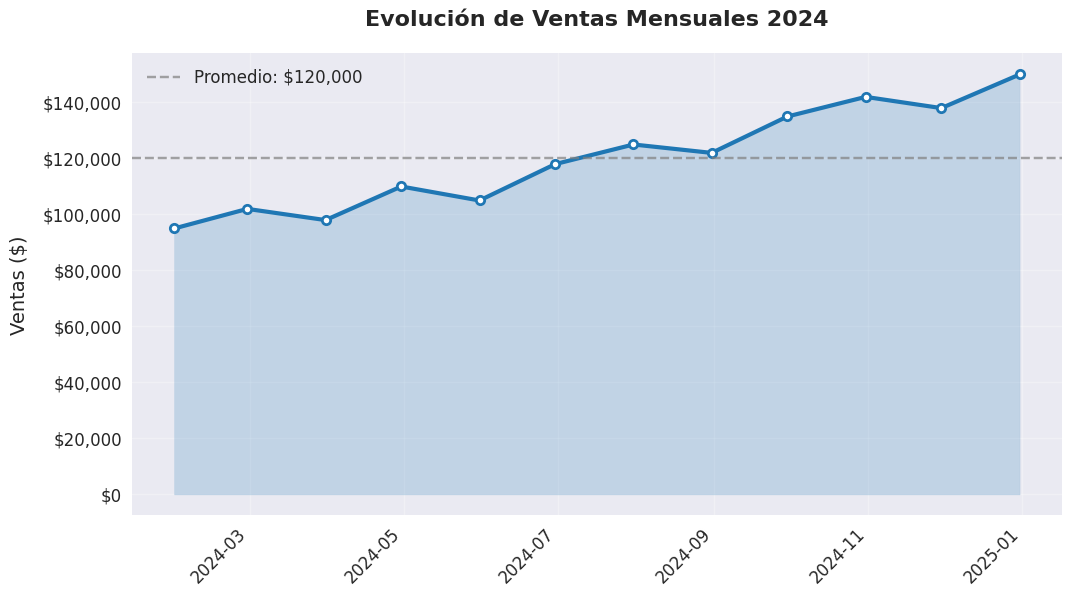

In [ ]:
import pandas as pd

# Datos temporales de ventas
fechas = pd.date_range('2024-01-01', periods=12, freq='M')
ventas_mensuales = [95000, 102000, 98000, 110000, 105000, 118000,
                   125000, 122000, 135000, 142000, 138000, 150000]

fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico de línea principal
line = ax.plot(fechas, ventas_mensuales, color=empresa_colors['primary'],
               linewidth=3, marker='o', markersize=6, markerfacecolor='white',
               markeredgecolor=empresa_colors['primary'], markeredgewidth=2)

# Área bajo la curva para enfatizar crecimiento
ax.fill_between(fechas, ventas_mensuales, alpha=0.2, color=empresa_colors['primary'])

# Líneas de referencia
venta_promedio = np.mean(ventas_mensuales)
ax.axhline(y=venta_promedio, color=empresa_colors['neutral'], linestyle='--', alpha=0.7,
           label=f'Promedio: ${venta_promedio:,.0f}')

ax.set_title('Evolución de Ventas Mensuales 2024', fontweight='bold', pad=20)
ax.set_ylabel('Ventas ($)', labelpad=10)
ax.grid(True, alpha=0.3)
ax.legend()

# Formatear eje Y
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

# Rotar etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

plt.savefig('linea_ventas_temporales.png', dpi=300, bbox_inches='tight')
plt.show()

#### Ejemplo: Análisis visual inicial de dataset empresarial completo

Preparación del dataset y configuración de Matplotlib:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configuración profesional de Matplotlib
plt.style.use('seaborn-v0_8')
mpl.rcParams.update({
    'font.size': 11,
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Paleta de colores corporativa
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

print("Configuración de Matplotlib completada")

Configuración de Matplotlib completada


Creación y análisis de dataset empresarial:

In [ ]:
# Generar dataset de ventas empresariales
np.random.seed(42)
n_ventas = 1000

df = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=n_ventas, freq='D'),
    'producto': np.random.choice(['Producto A', 'Producto B', 'Producto C', 'Producto D'], n_ventas),
    'region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], n_ventas),
    'cantidad': np.random.randint(1, 20, n_ventas),
    'precio_unitario': np.random.uniform(50, 500, n_ventas).round(2),
    'cliente_tipo': np.random.choice(['Regular', 'Premium', 'VIP'], n_ventas, p=[0.6, 0.3, 0.1])
})

# Calcular métricas derivadas
df['total_venta'] = df['cantidad'] * df['precio_unitario']
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.day_name()

print(f"Dataset creado: {len(df)} registros")
print(f"Período: {df['fecha'].min()} a {df['fecha'].max()}")
print(f"Total ventas: ${df['total_venta'].sum():,.2f}")

Dataset creado: 1000 registros
Período: 2024-01-01 00:00:00 a 2026-09-26 00:00:00
Total ventas: $2,777,508.39


Análisis univariado con histogramas y box plots:


Análisis univariado guardado como 'analisis_univariado_empresarial.png'


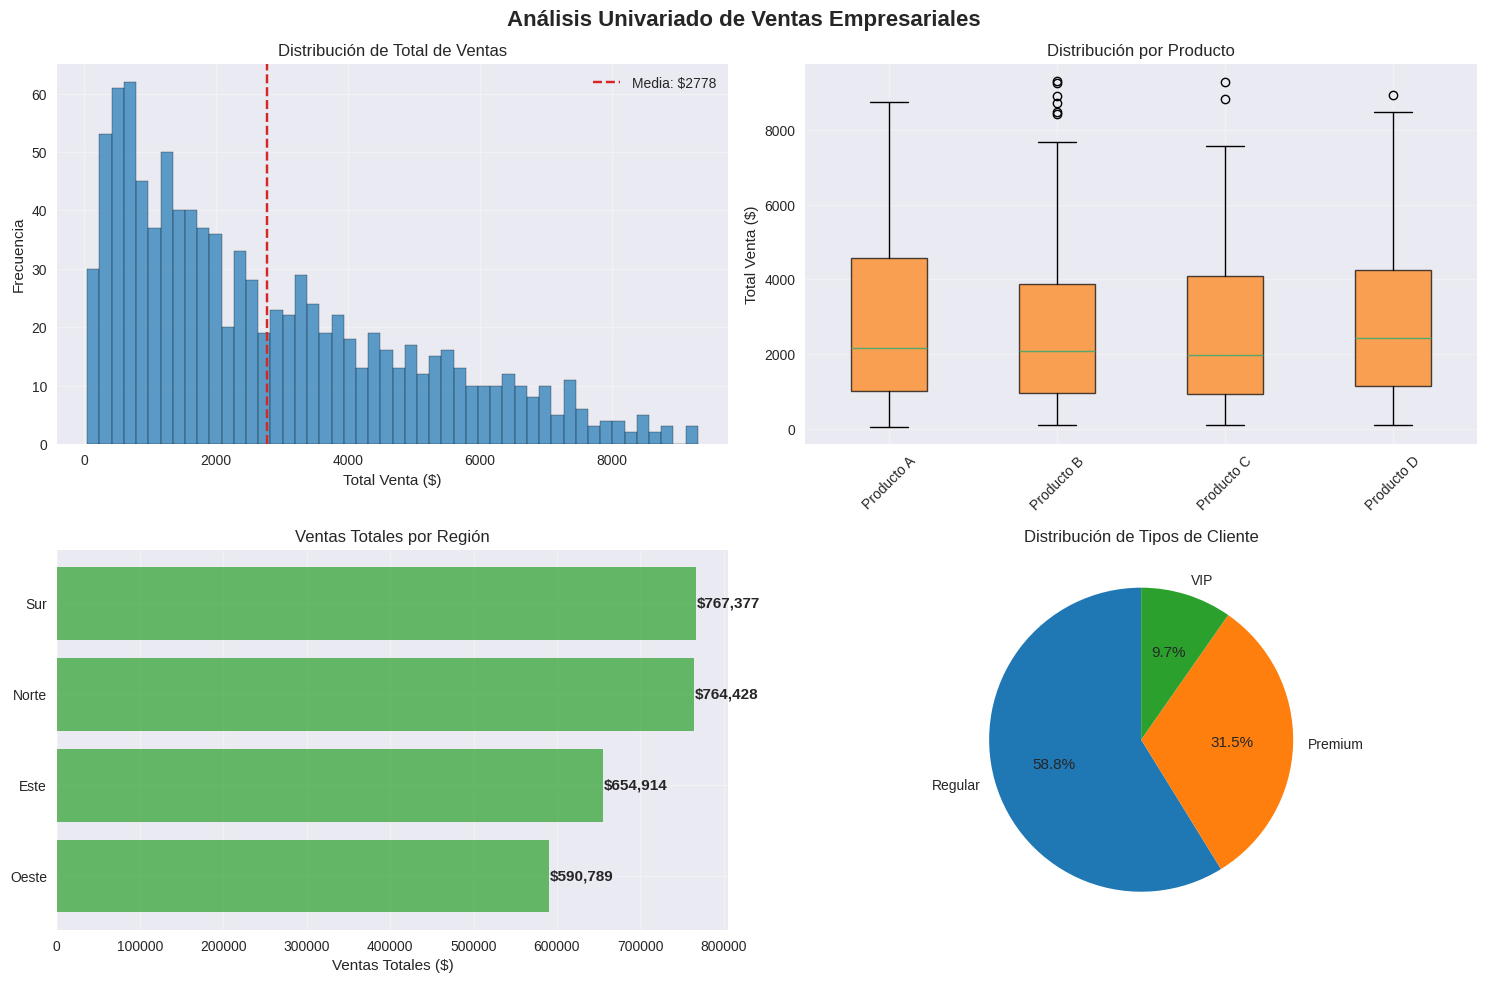

In [ ]:
# Figura con múltiples análisis univariados
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análisis Univariado de Ventas Empresariales', fontsize=16, fontweight='bold')

# 1. Histograma de total de ventas
ax1.hist(df['total_venta'], bins=50, alpha=0.7, color=colores[0], edgecolor='black')
ax1.set_title('Distribución de Total de Ventas')
ax1.set_xlabel('Total Venta ($)')
ax1.set_ylabel('Frecuencia')
ax1.axvline(df['total_venta'].mean(), color=colores[3], linestyle='--',
            label=f'Media: ${df["total_venta"].mean():.0f}')
ax1.legend()

# 2. Box plot por producto
productos = df.groupby('producto')['total_venta'].apply(list)
bp = ax2.boxplot(productos.values, tick_labels=productos.index, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(colores[1])
    patch.set_alpha(0.7)
ax2.set_title('Distribución por Producto')
ax2.set_ylabel('Total Venta ($)')
ax2.tick_params(axis='x', rotation=45)

# 3. Gráfico de barras por región
ventas_region = df.groupby('region')['total_venta'].sum().sort_values(ascending=True)
bars = ax3.barh(ventas_region.index, ventas_region.values, color=colores[2], alpha=0.7)
ax3.set_title('Ventas Totales por Región')
ax3.set_xlabel('Ventas Totales ($)')
for i, (region, venta) in enumerate(zip(ventas_region.index, ventas_region.values)):
    ax3.text(venta + 1000, i, f'${venta:,.0f}', va='center', fontweight='bold')

# 4. Pie chart de tipos de cliente (con precaución)
cliente_counts = df['cliente_tipo'].value_counts()
wedges, texts, autotexts = ax4.pie(cliente_counts.values, labels=cliente_counts.index,
                                   autopct='%1.1f%%', colors=colores[:3], startangle=90)
ax4.set_title('Distribución de Tipos de Cliente')

plt.tight_layout()
plt.savefig('analisis_univariado_empresarial.png', dpi=300, bbox_inches='tight')
print("\nAnálisis univariado guardado como 'analisis_univariado_empresarial.png'")

Análisis bivariado con scatter plots y series temporales:

Análisis bivariado guardado como 'analisis_bivariado_empresarial.png'


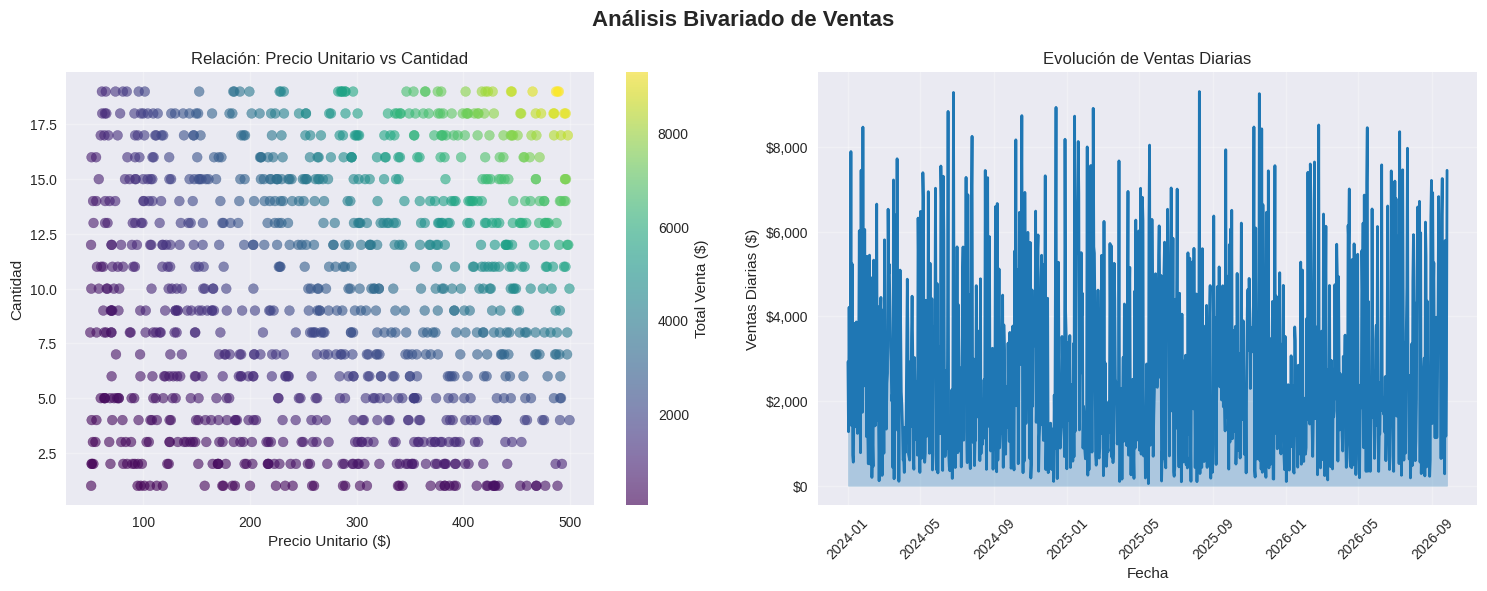

In [ ]:
# Figura para análisis bivariado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Análisis Bivariado de Ventas', fontsize=16, fontweight='bold')

# 1. Scatter plot: cantidad vs precio unitario
scatter = ax1.scatter(df['precio_unitario'], df['cantidad'],
                     c=df['total_venta'], cmap='viridis', alpha=0.6, s=50)
ax1.set_title('Relación: Precio Unitario vs Cantidad')
ax1.set_xlabel('Precio Unitario ($)')
ax1.set_ylabel('Cantidad')
plt.colorbar(scatter, ax=ax1, label='Total Venta ($)')

# 2. Serie temporal de ventas diarias
ventas_diarias = df.groupby('fecha')['total_venta'].sum()
ax2.plot(ventas_diarias.index, ventas_diarias.values, color=colores[0], linewidth=2)
ax2.fill_between(ventas_diarias.index, ventas_diarias.values, alpha=0.3, color=colores[0])
ax2.set_title('Evolución de Ventas Diarias')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Ventas Diarias ($)')
ax2.tick_params(axis='x', rotation=45)

# Formatear eje Y
ax2.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.savefig('analisis_bivariado_empresarial.png', dpi=300, bbox_inches='tight')
print("Análisis bivariado guardado como 'analisis_bivariado_empresarial.png'")

### Visualizaciones Avanzadas y Dashboards Interactivos

**Diseño de Figuras Compuestas con Subplots**

Las visualizaciones efectivas rara vez consisten en un solo gráfico. Los subplots permiten crear dashboards comprehensivos que muestran múltiples perspectivas de los datos simultáneamente.

Arquitecturas de Subplots Comunes

- Grid rectangular: Distribución regular de visualizaciones relacionadas.

    ```
    # 2x2 grid para análisis multivariado
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Dashboard Ejecutivo de Ventas', fontsize=16, fontweight='bold')

    # Asignar visualizaciones específicas
    ax1.set_title('Tendencia Mensual')      # Serie temporal
    ax2.set_title('Distribución por Región') # Barras
    ax3.set_title('Top Productos')          # Barras horizontales
    ax4.set_title('Distribución de Clientes') # Pie o barras

    plt.tight_layout()
    ```

- Layout asimétrico: Distribuciones que enfatizan jerarquía visual.

    ```
    # Layout con gráfico principal y secundarios
    fig = plt.figure(figsize=(16, 10))

    # Gráfico principal (70% del espacio)
    ax_main = plt.subplot2grid((3, 4), (0, 0), colspan=3, rowspan=2)
    ax_main.set_title('Evolución Principal de Ventas', fontsize=14, fontweight='bold')

    # Panel derecho con KPIs (30% del espacio)
    ax_kpi1 = plt.subplot2grid((3, 4), (0, 3), rowspan=1)
    ax_kpi2 = plt.subplot2grid((3, 4), (1, 3), rowspan=1)

    # Panel inferior para detalles
    ax_detail = plt.subplot2grid((3, 4), (2, 0), colspan=4)
    ax_detail.set_title('Análisis Detallado por Segmento', fontsize=12)

    plt.tight_layout()
    ```

Coordinación Visual entre Subplots

- Escalas compartidas: Mantener consistencia en ejes para comparación.

    ```
    # Compartir eje Y para comparación directa
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    # Ambos gráficos tendrán la misma escala Y
    ax1.bar(categorias_a, valores_a)
    ax2.bar(categorias_b, valores_b)
    ```

- Paletas coordinadas: Colores consistentes que signifiquen lo mismo en gráficos diferentes.
    ```
        # Definir mapeo de colores consistente
    color_map = {
        'Producto A': '#1f77b4',
        'Producto B': '#ff7f0e',
        'Producto C': '#2ca02c',
        'Producto D': '#d62728'
    }

    # Aplicar en múltiples subplots
    for ax in [ax1, ax2, ax3]:
        for categoria, color in color_map.items():
            # Usar mismo color para misma categoría en todos los gráficos
            datos_categoria = df[df['categoria'] == categoria]
            ax.plot(datos_categoria['x'], datos_categoria['y'], color=color, label=categoria)
    ```



**Visualizaciones Estadísticas Avanzadas**

Más allá de gráficos básicos, las visualizaciones estadísticas avanzadas permiten explorar relaciones complejas y distribuciones multivariadas.

- Heatmaps: Visualización de Matrices de Correlación

    Los heatmaps usan color para representar valores en matrices bidimensionales, ideales para correlaciones y patrones complejos.
    ```
    # Matriz de correlación completa
    correlation_matrix = df.select_dtypes(include=[np.number]).corr()

    # Heatmap de correlaciones
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(correlation_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)

    # Configurar ejes
    ax.set_xticks(np.arange(len(correlation_matrix.columns)))
    ax.set_yticks(np.arange(len(correlation_matrix.columns)))
    ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(correlation_matrix.columns)

    # Añadir valores numéricos
    for i in range(len(correlation_matrix.columns)):
        for j in range(len(correlation_matrix.columns)):
            text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                        ha='center', va='center', color='black', fontsize=8)

    # Barra de color
    cbar = ax.figure.colorbar(im, ax=ax, shrink=0.8)
    cbar.ax.set_ylabel('Correlación', rotation=-90, va='bottom')

    ax.set_title('Matriz de Correlación de Variables Empresariales', fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('heatmap_correlaciones.png', dpi=300, bbox_inches='tight')
    ```

- Violin Plots: Distribuciones con Densidad

    Los violin plots combinan box plots con estimaciones de densidad kernel, mostrando forma completa de distribuciones.

    ```
    # Comparación de distribuciones por categoría
    fig, ax = plt.subplots(figsize=(12, 8))

    # Datos por segmento de cliente
    segmentos = df['segmento_cliente'].unique()
    data_por_segmento = [df[df['segmento_cliente'] == seg]['valor_compra']
                        for seg in segmentos]

    # Violin plot
    parts = ax.violinplot(data_por_segmento, showmeans=True, showextrema=True)

    # Personalización
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colores[i % len(colores)])
        pc.set_alpha(0.7)

    # Configurar partes del violin plot
    parts['cmeans'].set_color('black')
    parts['cmins'].set_color('black')
    parts['cmaxes'].set_color('black')
    parts['cbars'].set_color('black')

    # Etiquetas y título
    ax.set_xticks(range(1, len(segmentos) + 1))
    ax.set_xticklabels(segmentos)
    ax.set_title('Distribución de Valor de Compra por Segmento de Cliente',
                fontweight='bold', pad=20)
    ax.set_ylabel('Valor de Compra ($)', labelpad=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.savefig('violin_segmentos_cliente.png', dpi=300, bbox_inches='tight')
    ```

- Scatter Plots Matrices: Análisis Multivariado

    Las matrices de scatter plots permiten explorar relaciones entre múltiples variables simultáneamente.

    ```
    # Variables de interés para análisis multivariado
    variables_clave = ['ventas', 'margen', 'satisfaccion', 'retencion', 'valor_vida']

    # Crear scatter plot matrix
    n_vars = len(variables_clave)
    fig, axes = plt.subplots(n_vars, n_vars, figsize=(15, 15))

    for i in range(n_vars):
        for j in range(n_vars):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: histogramas
                ax.hist(df[variables_clave[i]], bins=20, alpha=0.7, color=colores[0])
                ax.set_title(f'{variables_clave[i].title()}', fontsize=10)
            else:
                # Off-diagonal: scatter plots
                ax.scatter(df[variables_clave[j]], df[variables_clave[i]],
                        alpha=0.6, s=30, color=colores[1])
                
                # Añadir línea de tendencia si correlación fuerte
                corr = df[variables_clave[j]].corr(df[variables_clave[i]])
                if abs(corr) > 0.5:
                    z = np.polyfit(df[variables_clave[j]], df[variables_clave[i]], 1)
                    p = np.poly1d(z)
                    x_trend = np.linspace(df[variables_clave[j]].min(), df[variables_clave[j]].max(), 50)
                    ax.plot(x_trend, p(x_trend), 'r--', alpha=0.8, linewidth=1)

    # Configurar etiquetas
    for i, var in enumerate(variables_clave):
        axes[-1, i].set_xlabel(var.title(), fontsize=10)
        axes[i, 0].set_ylabel(var.title(), fontsize=10)

    plt.suptitle('Matriz de Relaciones Multivariadas', fontsize=14, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.savefig('scatter_matrix_multivariada.png', dpi=300, bbox_inches='tight')
    ```



**Introducción a Dashboards Interactivos**

La interactividad permite a los usuarios explorar datos dinámicamente, creando dashboards que se adaptan a diferentes preguntas.

- Widgets Básicos con Matplotlib

    Matplotlib ofrece interactividad básica a través de widgets, aunque limitada comparada con bibliotecas especializadas.

    ```
    from matplotlib.widgets import Slider, Button

    # Configurar figura con espacio para controles
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.subplots_adjust(bottom=0.25)

    # Gráfico inicial
    x = np.linspace(0, 10, 100)
    line, = ax.plot(x, np.sin(x), linewidth=2, color=colores[0])
    ax.set_title('Función Interactiva: sen(x + fase)')
    ax.grid(True, alpha=0.3)

    # Crear slider para fase
    ax_phase = plt.axes([0.2, 0.1, 0.5, 0.03])
    slider_phase = Slider(ax_phase, 'Fase', -np.pi, np.pi, valinit=0)

    # Función de actualización
    def update(val):
        phase = slider_phase.val
        line.set_ydata(np.sin(x + phase))
        fig.canvas.draw_idle()

    # Conectar slider a función de actualización
    slider_phase.on_changed(update)

    # Botón de reset
    ax_reset = plt.axes([0.8, 0.05, 0.1, 0.04])
    button_reset = Button(ax_reset, 'Reset')

    def reset(event):
        slider_phase.set_val(0)
        update(0)

    button_reset.on_clicked(reset)

    plt.show()
    ```

- Introducción a Plotly para Interactividad Web

    Plotly ofrece interactividad nativa del navegador web, creando visualizaciones que responden a clics, hover y zoom.


    ```
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    # Crear subplot interactivo
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Ventas por Región', 'Tendencia Temporal',
                    'Distribución por Producto', 'Top Clientes'),
        specs=[[{'type': 'bar'}, {'type': 'scatter'}],
            [{'type': 'pie'}, {'type': 'bar'}]]
    )

    # Gráfico 1: Barras de ventas por región
    ventas_region = df.groupby('region')['total_venta'].sum()
    fig.add_trace(
        go.Bar(x=ventas_region.index, y=ventas_region.values,
            name='Ventas por Región', marker_color=colores[0]),
        row=1, col=1
    )

    # Gráfico 2: Tendencia temporal
    ventas_tiempo = df.groupby('fecha')['total_venta'].sum().reset_index()
    fig.add_trace(
        go.Scatter(x=ventas_tiempo['fecha'], y=ventas_tiempo['total_venta'],
                mode='lines+markers', name='Evolución de Ventas',
                line=dict(color=colores[1], width=3)),
        row=1, col=2
    )

    # Gráfico 3: Pie chart de productos
    ventas_producto = df.groupby('producto')['total_venta'].sum()
    fig.add_trace(
        go.Pie(labels=ventas_producto.index, values=ventas_producto.values,
            name='Distribución por Producto'),
        row=2, col=1
    )

    # Gráfico 4: Top clientes
    top_clientes = df.groupby('cliente')['total_venta'].sum().nlargest(10)
    fig.add_trace(
        go.Bar(x=top_clientes.values, y=top_clientes.index, orientation='h',
            name='Top 10 Clientes', marker_color=colores[3]),
        row=2, col=2
    )

    # Configurar layout
    fig.update_layout(
        title_text='Dashboard Interactivo de Ventas Empresariales',
        title_font_size=20,
        showlegend=False,
        height=800
    )

    # Guardar como HTML interactivo
    fig.write_html('dashboard_interactivo.html')
    print("Dashboard interactivo guardado como 'dashboard_interactivo.html'")
    ```



#### Ejemplo:  Construcción de dashboard analítico completo para análisis de e-commerce

Configuración del entorno y dataset:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

# Configuración profesional
plt.style.use('seaborn-v0_8')
mpl.rcParams.update({
    'font.size': 10,
    'figure.figsize': (16, 10),
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Paleta de colores
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Generar dataset de e-commerce avanzado
np.random.seed(42)
n_ordenes = 2000

df = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=n_ordenes, freq='h'),
    'cliente_id': np.random.randint(1, 401, n_ordenes),
    'categoria': np.random.choice(['Electrónica', 'Ropa', 'Hogar', 'Libros', 'Deportes'], n_ordenes),
    'subtotal': np.round(np.random.lognormal(4.5, 0.8, n_ordenes), 2),
    'descuento': np.round(np.random.uniform(0, 0.3, n_ordenes), 2),
    'envio': np.round(np.random.uniform(5, 25, n_ordenes), 2),
    'region': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla'], n_ordenes),
    'metodo_pago': np.random.choice(['Tarjeta', 'PayPal', 'Transferencia'], n_ordenes, p=[0.7, 0.2, 0.1])
})

# Calcular métricas
df['total'] = df['subtotal'] * (1 - df['descuento']) + df['envio']
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.day_name()

print(f"Dataset de e-commerce creado: {len(df)} órdenes")
print(f"Período: {df['fecha'].min()} a {df['fecha'].max()}")

Dataset de e-commerce creado: 2000 órdenes
Período: 2024-01-01 00:00:00 a 2024-03-24 07:00:00


Creación de dashboard comprehensivo con subplots:


Dashboard comprehensivo guardado como 'dashboard_ecommerce_completo.png'


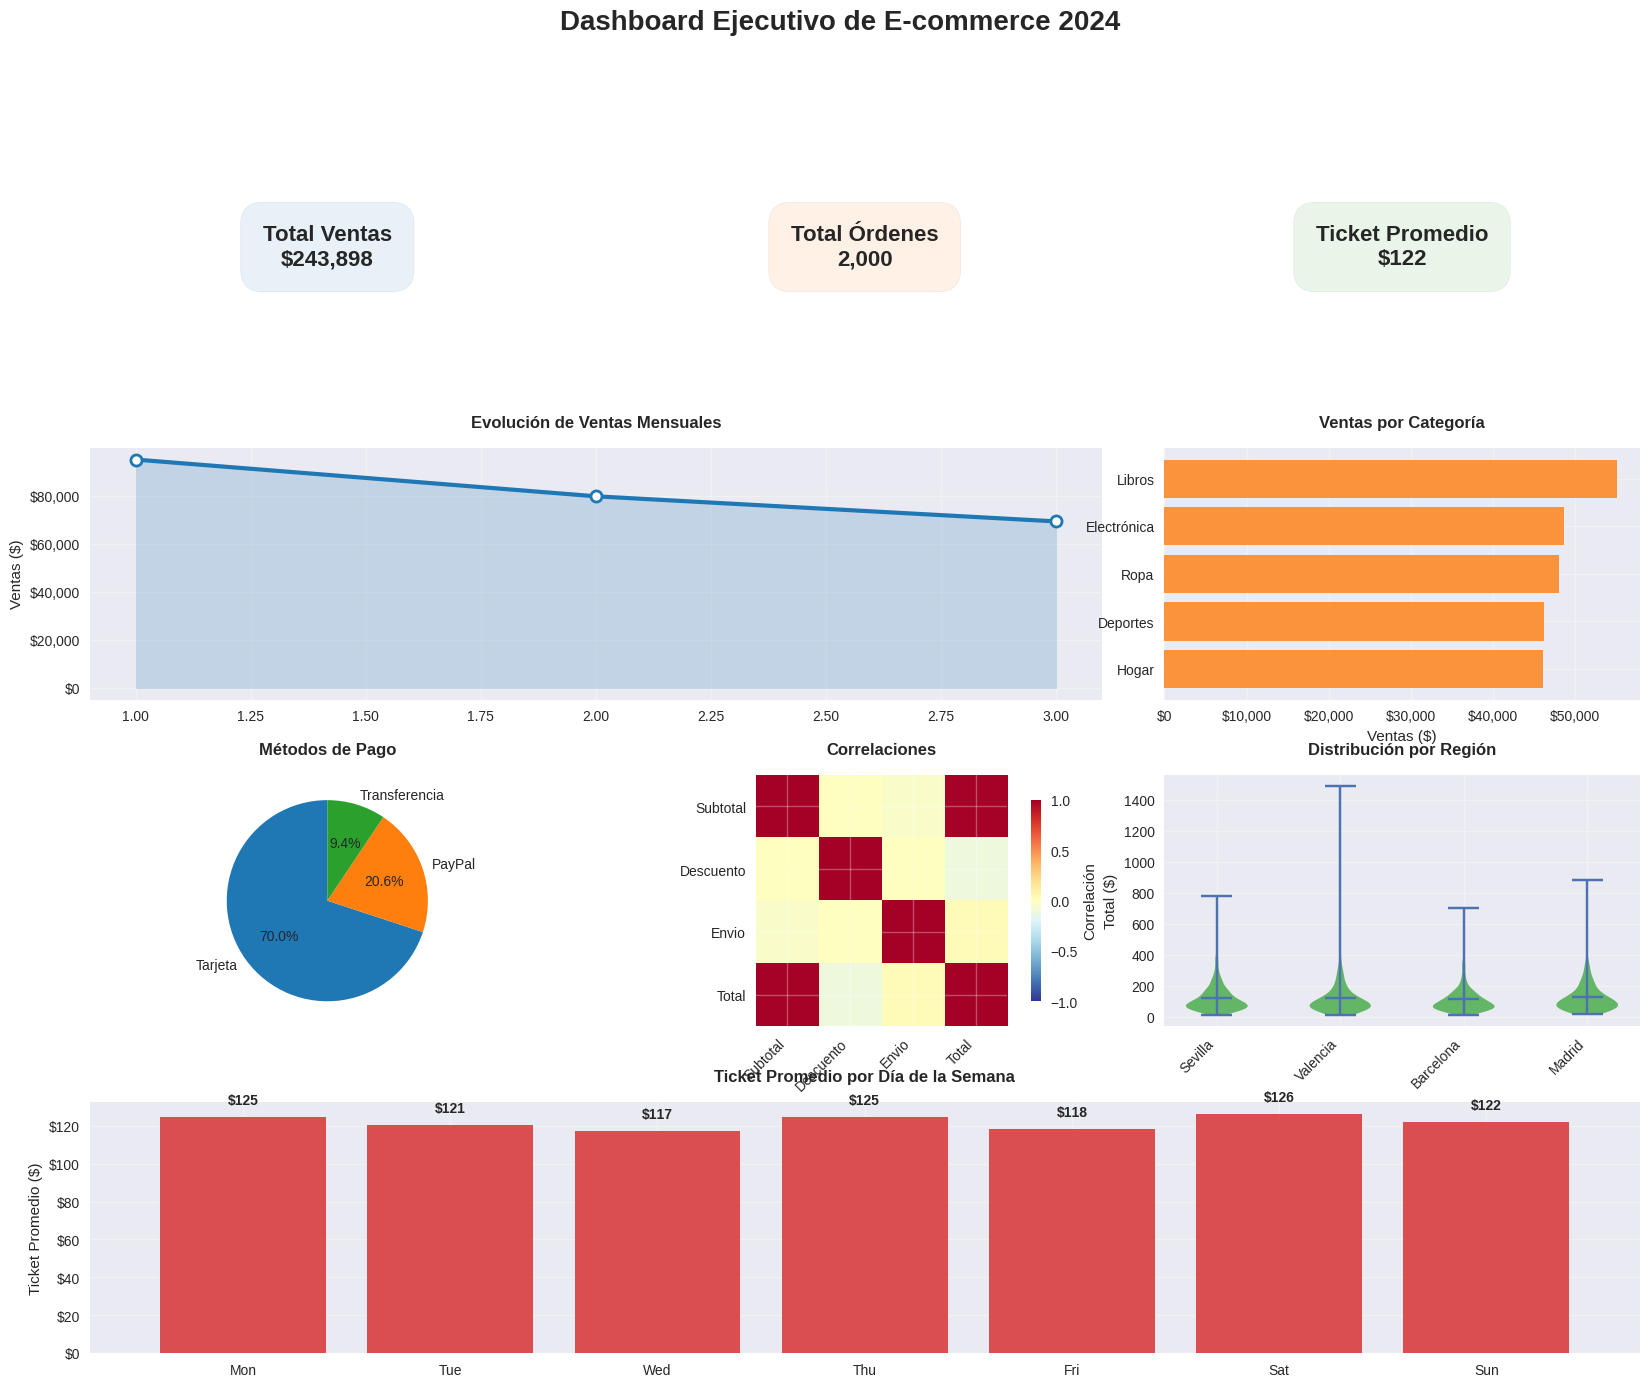

In [ ]:
# Crear dashboard con GridSpec para layout flexible
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(4, 6, figure=fig, hspace=0.3, wspace=0.3)

# Título principal
fig.suptitle('Dashboard Ejecutivo de E-commerce 2024', fontsize=20, fontweight='bold', y=0.95)

# 1. KPIs principales (superior)
ax_kpi1 = fig.add_subplot(gs[0, :2])
ax_kpi2 = fig.add_subplot(gs[0, 2:4])
ax_kpi3 = fig.add_subplot(gs[0, 4:])

# KPI 1: Total de ventas
total_ventas = df['total'].sum()
ax_kpi1.text(0.5, 0.5, f'Total Ventas\n${total_ventas:,.0f}',
             ha='center', va='center', fontsize=16, fontweight='bold',
             bbox=dict(boxstyle='round,pad=1', facecolor=colores[0], alpha=0.1))
ax_kpi1.set_xlim(0, 1)
ax_kpi1.set_ylim(0, 1)
ax_kpi1.axis('off')

# KPI 2: Número de órdenes
num_ordenes = len(df)
ax_kpi2.text(0.5, 0.5, f'Total Órdenes\n{num_ordenes:,}',
             ha='center', va='center', fontsize=16, fontweight='bold',
             bbox=dict(boxstyle='round,pad=1', facecolor=colores[1], alpha=0.1))
ax_kpi2.axis('off')

# KPI 3: Ticket promedio
ticket_promedio = df['total'].mean()
ax_kpi3.text(0.5, 0.5, f'Ticket Promedio\n${ticket_promedio:.0f}',
             ha='center', va='center', fontsize=16, fontweight='bold',
             bbox=dict(boxstyle='round,pad=1', facecolor=colores[2], alpha=0.1))
ax_kpi3.axis('off')

# 2. Tendencia mensual (fila 1, columnas 0-3)
ax_trend = fig.add_subplot(gs[1, :4])
ventas_mes = df.groupby('mes')['total'].sum()
ax_trend.plot(ventas_mes.index, ventas_mes.values, 'o-', linewidth=3,
              color=colores[0], markersize=8, markerfacecolor='white', markeredgewidth=2)
ax_trend.fill_between(ventas_mes.index, ventas_mes.values, alpha=0.2, color=colores[0])
ax_trend.set_title('Evolución de Ventas Mensuales', fontweight='bold', pad=15)
ax_trend.set_ylabel('Ventas ($)')
ax_trend.grid(True, alpha=0.3)
ax_trend.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

# 3. Distribución por categoría (fila 1, columnas 4-5)
ax_categoria = fig.add_subplot(gs[1, 4:])
ventas_cat = df.groupby('categoria')['total'].sum().sort_values(ascending=True)
bars = ax_categoria.barh(ventas_cat.index, ventas_cat.values, color=colores[1], alpha=0.8)
ax_categoria.set_title('Ventas por Categoría', fontweight='bold', pad=15)
ax_categoria.set_xlabel('Ventas ($)')
ax_categoria.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))

# 4. Análisis de métodos de pago (fila 2, izquierda)
ax_pago = fig.add_subplot(gs[2, :2])
pago_counts = df['metodo_pago'].value_counts()
wedges, texts, autotexts = ax_pago.pie(pago_counts.values, labels=pago_counts.index,
                                      autopct='%1.1f%%', colors=colores[:3], startangle=90)
ax_pago.set_title('Métodos de Pago', fontweight='bold', pad=15)

# 5. Heatmap de correlaciones (fila 2, centro)
ax_corr = fig.add_subplot(gs[2, 2:4])
numeric_cols = ['subtotal', 'descuento', 'envio', 'total']
corr_matrix = df[numeric_cols].corr()
im = ax_corr.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax_corr.set_xticks(np.arange(len(numeric_cols)))
ax_corr.set_yticks(np.arange(len(numeric_cols)))
ax_corr.set_xticklabels([col.title() for col in numeric_cols], rotation=45, ha='right')
ax_corr.set_yticklabels([col.title() for col in numeric_cols])
ax_corr.set_title('Correlaciones', fontweight='bold', pad=15)

# Barra de color para heatmap
cbar = fig.colorbar(im, ax=ax_corr, shrink=0.8)
cbar.set_label('Correlación')

# 6. Violin plot por región (fila 2, derecha)
ax_region = fig.add_subplot(gs[2, 4:])
region_data = [df[df['region'] == region]['total'] for region in df['region'].unique()]
vp = ax_region.violinplot(region_data, showmeans=True)
for pc in vp['bodies']:
    pc.set_facecolor(colores[2])
    pc.set_alpha(0.7)
ax_region.set_xticks(range(1, len(df['region'].unique()) + 1))
ax_region.set_xticklabels(df['region'].unique(), rotation=45, ha='right')
ax_region.set_title('Distribución por Región', fontweight='bold', pad=15)
ax_region.set_ylabel('Total ($)')

# 7. Análisis de días de la semana (fila 3, completa)
ax_dia = fig.add_subplot(gs[3, :])
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dia = df.groupby('dia_semana')['total'].mean().reindex(orden_dias)
bars_dia = ax_dia.bar(range(len(ventas_dia)), ventas_dia.values, color=colores[3], alpha=0.8)
ax_dia.set_xticks(range(len(ventas_dia)))
ax_dia.set_xticklabels([dia[:3] for dia in orden_dias])
ax_dia.set_title('Ticket Promedio por Día de la Semana', fontweight='bold', pad=15)
ax_dia.set_ylabel('Ticket Promedio ($)')
ax_dia.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('${x:,.0f}'))
ax_dia.grid(True, alpha=0.3, axis='y')

# Añadir valores encima de las barras
for bar, valor in zip(bars_dia, ventas_dia.values):
    height = bar.get_height()
    ax_dia.text(bar.get_x() + bar.get_width()/2., height + 5,
               f'${valor:.0f}', ha='center', va='bottom', fontweight='bold')

plt.savefig('dashboard_ecommerce_completo.png', dpi=300, bbox_inches='tight')
print("\nDashboard comprehensivo guardado como 'dashboard_ecommerce_completo.png'")

### Storytelling con Datos para Comunicar Insights

**Estructura de una Historia de Datos Efectiva**

El storytelling con datos transforma análisis técnicos en narrativas persuasivas que motivan acción. Una estructura clara guía al espectador desde la confusión inicial hasta la claridad accionable.

1. Fase 1: Establecer Contexto (10% del tiempo/presentación)


    - ¿Cuál es el problema de negocio que estamos resolviendo?
    - ¿Por qué este análisis es importante ahora?
    - ¿Qué pregunta específica intentamos responder?

2. Fase 2: Presentar Evidencia (70% del tiempo/presentación)


    - Datos que respaldan nuestros hallazgos
    - Análisis que revela patrones y tendencias
    - Insights que responden a la pregunta original

3. Fase 3: Comunicar Insights (15% del tiempo/presentación)

    - ¿Qué significa realmente esta información?
    - ¿Cuáles son las implicaciones para el negocio?
    - ¿Qué patrones son consistentes vs excepcionales?

4. Fase 4: Llamado a la Acción (5% del tiempo/presentación)

    - Recomendaciones específicas y priorizadas
    - Próximos pasos concretos
    - Métricas para medir el impacto

5. Principios de Narrativa Visual

    - Mostrar, no solo contar: Los datos deben "hablar por sí mismos" a través de visualizaciones claras.

    - Progreso lógico: Cada visualización debe llevar naturalmente a la siguiente, construyendo comprensión incremental.

    - Emoción + Racionalidad: Combinar impacto emocional (problemas urgentes) con evidencia racional (datos sólidos).

    - Relevancia contextual: Enmarcar insights en términos que importen a la audiencia específica.


**Jerarquía de Información y Diseño de Atención**

La jerarquía visual guía la atención del espectador, asegurando que los insights más importantes sean los primeros en ser notados y comprendidos.

Principios de Jerarquía Visual

- Tamaño y posición: Elementos más importantes más grandes y mejor posicionados.


    ```
    # Layout jerárquico para presentación ejecutiva
    fig, ((ax_title, ax_empty), (ax_main, ax_support)) = plt.subplots(2, 2, figsize=(16, 10),
                                                                    gridspec_kw={'width_ratios': [2, 1], 'height_ratios': [1, 3]})

    # Título principal (área grande, texto grande)
    ax_title.text(0.5, 0.5, 'ANÁLISIS DE VENTAS Q4 2024',
                ha='center', va='center', fontsize=28, fontweight='bold')
    ax_title.axis('off')

    # Celda vacía para balance visual
    ax_empty.axis('off')

    # Gráfico principal (área dominante)
    # Aquí va la visualización más importante

    # Panel de soporte (área secundaria)
    # KPIs adicionales o detalles de respaldo
    ```
    
-  Contraste y color: Diferencias visuales que crean separación clara entre elementos.


    ```
    # Sistema de colores jerárquico
    hierarchy_colors = {
        'primary': '#1f77b4',      # Insights principales
        'secondary': '#7f7f7f',    # Información de contexto
        'accent': '#ff7f0e',       # Elementos de énfasis
        'warning': '#d62728',      # Problemas/alertas
        'success': '#2ca02c'       # Éxitos/positivos
    }

    # Aplicar jerarquía en visualizaciones
    def apply_hierarchy(ax, data, hierarchy_level='primary'):
        color = hierarchy_colors[hierarchy_level]
        linewidth = 3 if hierarchy_level == 'primary' else 2 if hierarchy_level == 'secondary' else 1
        alpha = 1.0 if hierarchy_level == 'primary' else 0.7 if hierarchy_level == 'secondary' else 0.5
        
        return ax.plot(data['x'], data['y'], color=color, linewidth=linewidth, alpha=alpha)
    ```

Técnicas de Dirección de Atención

- Flechas y conectores: Guiar el ojo a través de la información en secuencia lógica.

    ```
    # Añadir flechas para guiar atención
    def add_attention_arrow(ax, start_point, end_point, text='', arrowstyle='->'):
        ax.annotate(text, xy=end_point, xytext=start_point,
                    arrowprops=dict(arrowstyle=arrowstyle, color='red', linewidth=2),
                    fontsize=12, fontweight='bold', ha='center')
    ```

- Zonas de calor visual: Áreas más "calientes" (brillantes/intensas) atraen atención primero.

    ```
    # Gradiente de atención: centro > periferia
    attention_gradient = np.linspace(1.0, 0.3, 10)  # De intenso a sutil

    for i, alpha in enumerate(attention_gradient):
        # Elementos más importantes con mayor opacidad/intensidad
        ax.scatter(x[i], y[i], alpha=alpha, s=size[i], color=color[i])
    ```

- Secuenciación temporal: Presentar información en orden que construya comprensión progresiva.

**Técnicas de Énfasis y Comunicación Persuasiva**

El énfasis visual asegura que insights críticos no pasen desapercibidos, mientras que la persuasión convierte datos en acción.

Técnicas de Énfasis Visual

- Aislamiento: Separar elementos importantes del resto del contenido.


    ```
    # Técnica de aislamiento con zoom
    def emphasize_with_zoom(ax, data_point, zoom_factor=2):
        # Crear círculo de énfasis alrededor del punto clave
        circle = plt.Circle((data_point['x'], data_point['y']),
                        radius=zoom_factor, fill=False,
                        color='red', linewidth=3, linestyle='--')
        ax.add_artist(circle)
        
        # Añadir etiqueta de énfasis
        ax.annotate('INSIGHT CLAVE', xy=(data_point['x'], data_point['y']),
                    xytext=(data_point['x'] + zoom_factor, data_point['y'] + zoom_factor),
                    arrowprops=dict(arrowstyle='->', color='red', linewidth=2),
                    fontsize=14, fontweight='bold', color='red')
    ```

- Animación secuencial: Revelar información paso a paso para mantener engagement.


    ```
    # Simulación de animación secuencial (en presentaciones interactivas)
    def sequential_reveal(ax, data_layers, pause_seconds=1):
        revealed_layers = []
        
        for i, layer in enumerate(data_layers):
            # Añadir nueva capa
            layer_obj = ax.plot(layer['x'], layer['y'], **layer['style'])
            revealed_layers.append(layer_obj)
            
            # Añadir anotación explicativa
            ax.annotate(layer['annotation'], xy=(layer['x'][-1], layer['y'][-1]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=12, fontweight='bold')
            
            # En presentación real: plt.pause(pause_seconds)
            # Aquí solo construimos la visualización final
    ```

- Contraste extremo: Hacer que elementos críticos destaquen radicalmente del resto.

    ```
    # Técnica de contraste extremo
    def extreme_contrast(ax, normal_data, critical_insight):
        # Datos normales en gris sutil
        ax.plot(normal_data['x'], normal_data['y'], color='#cccccc', linewidth=1, alpha=0.5)
        
        # Insight crítico en rojo brillante
        ax.plot(critical_insight['x'], critical_insight['y'],
                color='#ff0000', linewidth=4, marker='o', markersize=8)
        
        # Etiqueta de alto impacto
        ax.text(critical_insight['x'][-1], critical_insight['y'][-1] + 10,
                '¡ALERTA CRÍTICA!', fontsize=16, fontweight='bold',
                color='#ff0000', ha='center')
    ```

Estrategias de Comunicación Persuasiva

- Marco contextual: Enmarcar datos en términos que resuenen con valores y prioridades de la audiencia.

- Narrativa emocional: Conectar datos con impactos humanos y consecuencias reales.

- Credibilidad: Mostrar metodología sólida y reconocer limitaciones.

- Llamado a acción específico: Traducir insights en pasos concretos y medibles

#### Ejemplo: Creación de presentación analítica impactante sobre rendimiento de ventas

Análisis de datos y preparación de insights clave:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle

# Configuración profesional para presentación
plt.style.use('seaborn-v0_8')
mpl.rcParams.update({
    'font.size': 14,
    'figure.titlesize': 20,
    'figure.figsize': (16, 10),
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Generar dataset de rendimiento de ventas
np.random.seed(42)
meses = pd.date_range('2024-01-01', periods=12, freq='ME')

df = pd.DataFrame({
    'mes': meses,
    'ventas_objetivo': [100000, 105000, 110000, 108000, 115000, 120000,
                       125000, 128000, 130000, 135000, 138000, 140000],
    'ventas_real': [95000, 102000, 105000, 112000, 118000, 115000,
                   122000, 135000, 128000, 142000, 145000, 148000],
    'margen_promedio': np.random.normal(0.25, 0.05, 12),
    'clientes_nuevos': np.random.randint(50, 150, 12),
    'satisfaccion': np.random.normal(4.2, 0.3, 12).clip(1, 5)
})

df['cumplimiento'] = (df['ventas_real'] / df['ventas_objetivo'] * 100).round(1)
df['mes_nombre'] = df['mes'].dt.strftime('%b %Y')

print("Dataset de rendimiento de ventas preparado")
print(f"Promedio de cumplimiento: {df['cumplimiento'].mean():.1f}%")
print(f"Mejor mes: {df.loc[df['cumplimiento'].idxmax(), 'mes_nombre']} ({df['cumplimiento'].max()}%)")
print(f"Peor mes: {df.loc[df['cumplimiento'].idxmin(), 'mes_nombre']} ({df['cumplimiento'].min()}%)")

Dataset de rendimiento de ventas preparado
Promedio de cumplimiento: 100.6%
Mejor mes: Dec 2024 (105.7%)
Peor mes: Jan 2024 (95.0%)


Creación de diapositiva de título impactante:

Diapositiva de título guardada


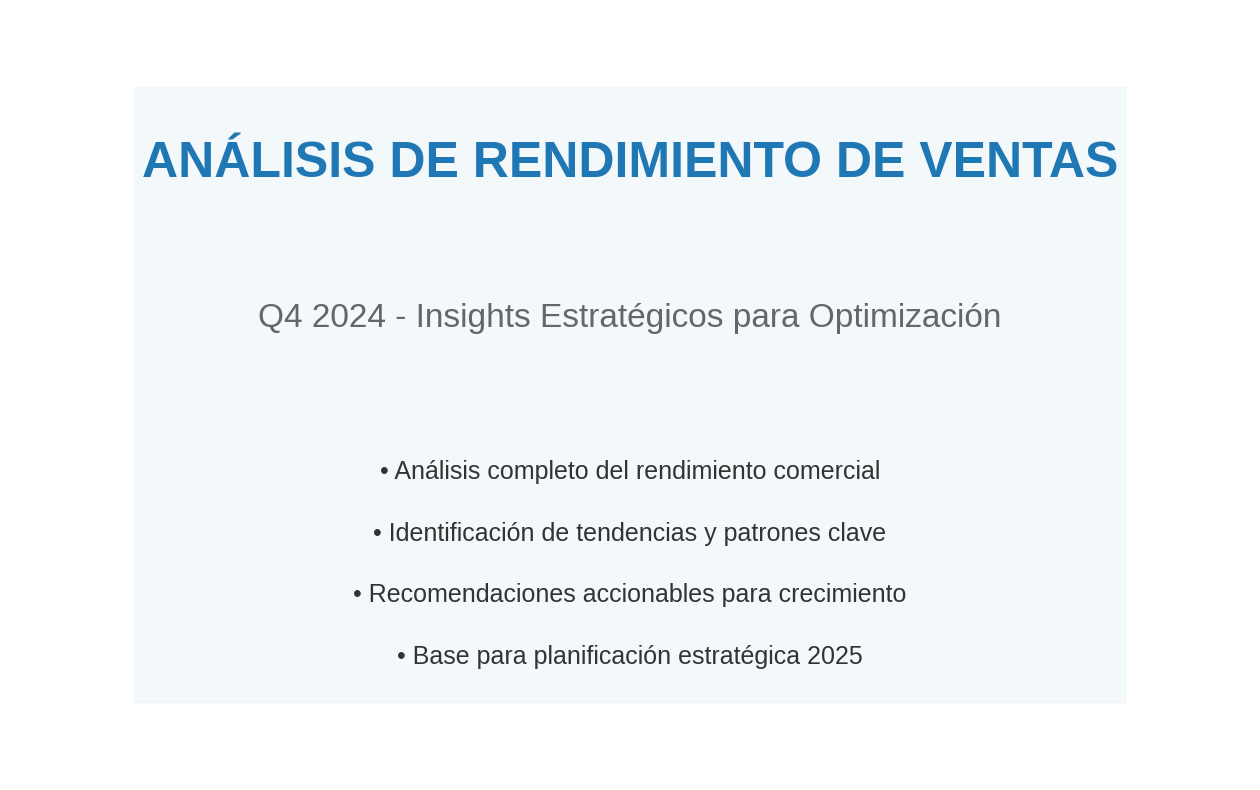

In [ ]:
# Diapositiva 1: Título y contexto
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

# Título principal
ax.text(0.5, 0.8, 'ANÁLISIS DE RENDIMIENTO DE VENTAS',
        ha='center', va='center', fontsize=36, fontweight='bold', color='#1f77b4')

# Subtítulo
ax.text(0.5, 0.6, 'Q4 2024 - Insights Estratégicos para Optimización',
        ha='center', va='center', fontsize=24, color='#666666')

# Contexto ejecutivo
contexto = """
• Análisis completo del rendimiento comercial
• Identificación de tendencias y patrones clave
• Recomendaciones accionables para crecimiento
• Base para planificación estratégica 2025
"""

y_pos = 0.4
for line in contexto.strip().split('\n'):
    ax.text(0.5, y_pos, line, ha='center', va='center',
            fontsize=18, color='#333333')
    y_pos -= 0.08

# Elemento visual de fondo sutil
rect = Rectangle((0.1, 0.1), 0.8, 0.8, fill=True, alpha=0.05, color='#1f77b4')
ax.add_patch(rect)

plt.savefig('diapositiva_01_titulo.png', dpi=300, bbox_inches='tight')
print("Diapositiva de título guardada")

Diapositiva de insights principales con jerarquía visual:

Diapositiva de insights guardada


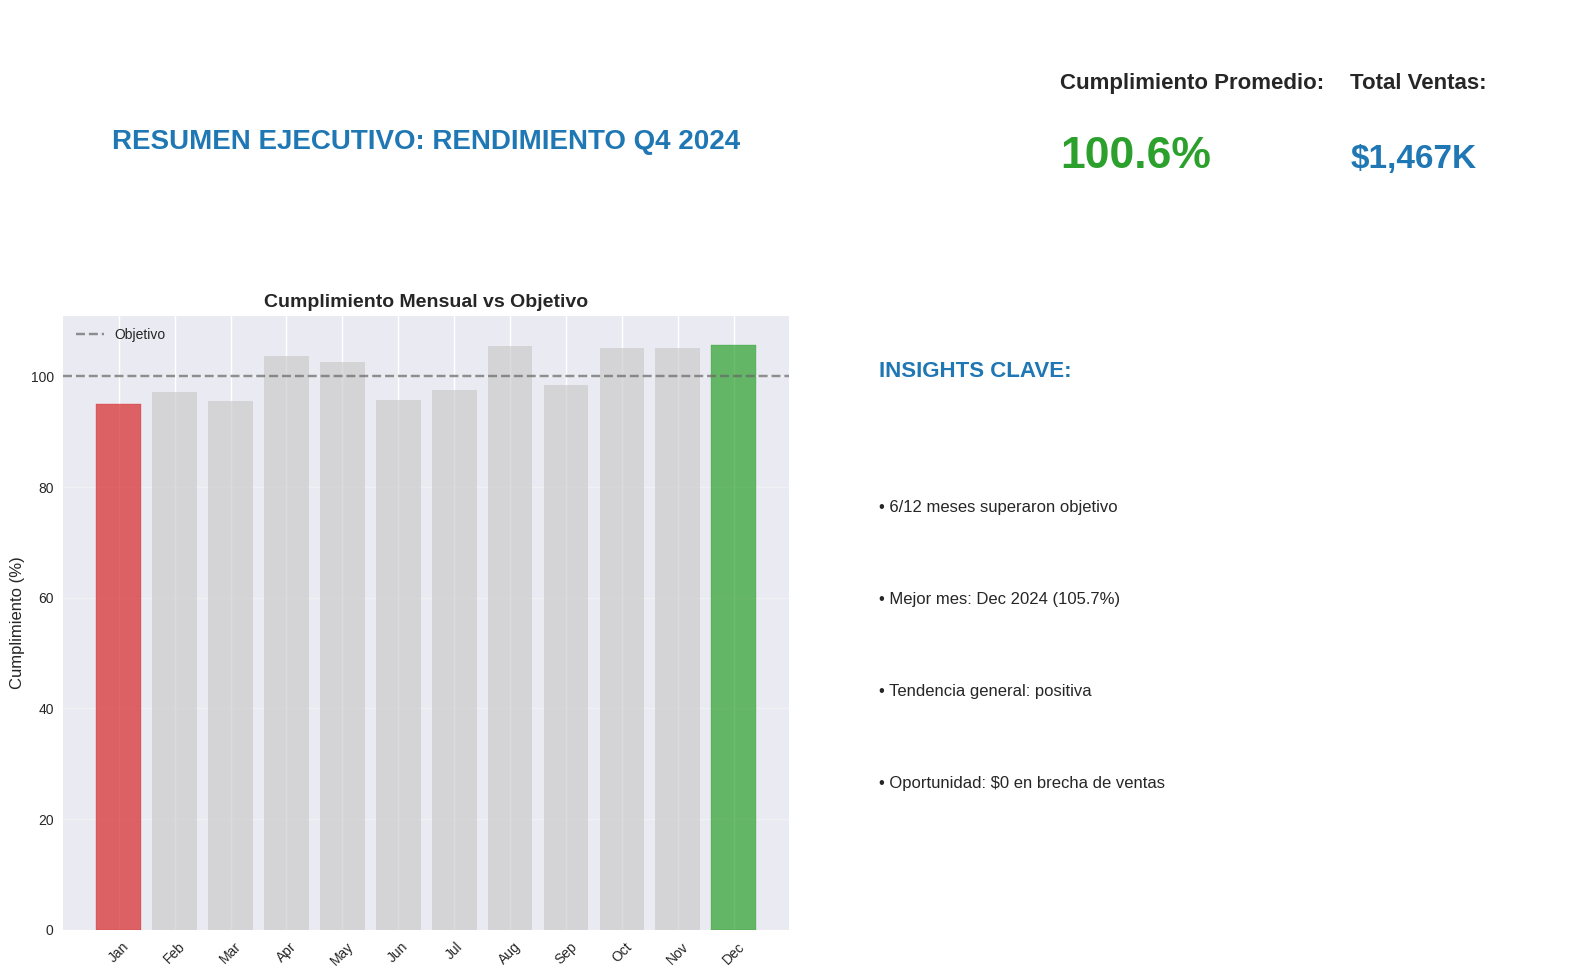

In [ ]:
# Diapositiva 2: Insights principales
fig, ((ax_title, ax_kpi), (ax_chart, ax_insights)) = plt.subplots(2, 2,
                                                                figsize=(16, 10),
                                                                gridspec_kw={'width_ratios': [1, 1], 'height_ratios': [0.3, 0.7]})

# Título de sección
ax_title.text(0.5, 0.5, 'RESUMEN EJECUTIVO: RENDIMIENTO Q4 2024',
              ha='center', va='center', fontsize=20, fontweight='bold', color='#1f77b4')
ax_title.axis('off')

# KPIs principales (jerarquía alta)
ax_kpi.axis('off')
cumplimiento_promedio = df['cumplimiento'].mean()
color_kpi = '#2ca02c' if cumplimiento_promedio >= 100 else '#ff7f0e' if cumplimiento_promedio >= 95 else '#d62728'

ax_kpi.text(0.3, 0.7, f'Cumplimiento Promedio:', fontsize=16, fontweight='bold')
ax_kpi.text(0.3, 0.4, f'{cumplimiento_promedio:.1f}%', fontsize=32, fontweight='bold', color=color_kpi)

ax_kpi.text(0.7, 0.7, f'Total Ventas:', fontsize=16, fontweight='bold')
ax_kpi.text(0.7, 0.4, f'${df["ventas_real"].sum()/1000:,.0f}K', fontsize=24, fontweight='bold', color='#1f77b4')

# Gráfico principal con énfasis
bars = ax_chart.bar(range(len(df)), df['cumplimiento'], color='#cccccc', alpha=0.7)

# Resaltar mejor y peor mes
mejor_idx = df['cumplimiento'].idxmax()
peor_idx = df['cumplimiento'].idxmin()

bars[mejor_idx].set_color('#2ca02c')  # Verde para mejor
bars[peor_idx].set_color('#d62728')  # Rojo para peor

ax_chart.axhline(y=100, color='#666666', linestyle='--', alpha=0.7, label='Objetivo')
ax_chart.set_xticks(range(len(df)))
ax_chart.set_xticklabels(df['mes'].dt.strftime('%b'), rotation=45)
ax_chart.set_ylabel('Cumplimiento (%)', fontsize=12)
ax_chart.set_title('Cumplimiento Mensual vs Objetivo', fontsize=14, fontweight='bold')
ax_chart.legend()
ax_chart.grid(True, alpha=0.3, axis='y')

# Panel de insights clave (jerarquía alta)
ax_insights.axis('off')
ax_insights.text(0.05, 0.9, 'INSIGHTS CLAVE:', fontsize=16, fontweight='bold', color='#1f77b4')

insights = [
    f"• {len(df[df['cumplimiento'] >= 100])}/12 meses superaron objetivo",
    f"• Mejor mes: {df.loc[mejor_idx, 'mes_nombre']} ({df.loc[mejor_idx, 'cumplimiento']}%)",
    f"• Tendencia general: {'positiva' if df['cumplimiento'].iloc[-3:].mean() > df['cumplimiento'].iloc[:3].mean() else 'estable'}",
    f"• Oportunidad: ${df[df['cumplimiento'] < 95]['ventas_objetivo'].sum():,.0f} en brecha de ventas"
]

y_pos = 0.7
for insight in insights:
    ax_insights.text(0.05, y_pos, insight, fontsize=12, va='top')
    y_pos -= 0.15

plt.tight_layout()
plt.savefig('diapositiva_02_insights_principales.png', dpi=300, bbox_inches='tight')
print("Diapositiva de insights guardada")

Diapositiva de recomendaciones con llamado a acción:

Diapositiva de recomendaciones guardada


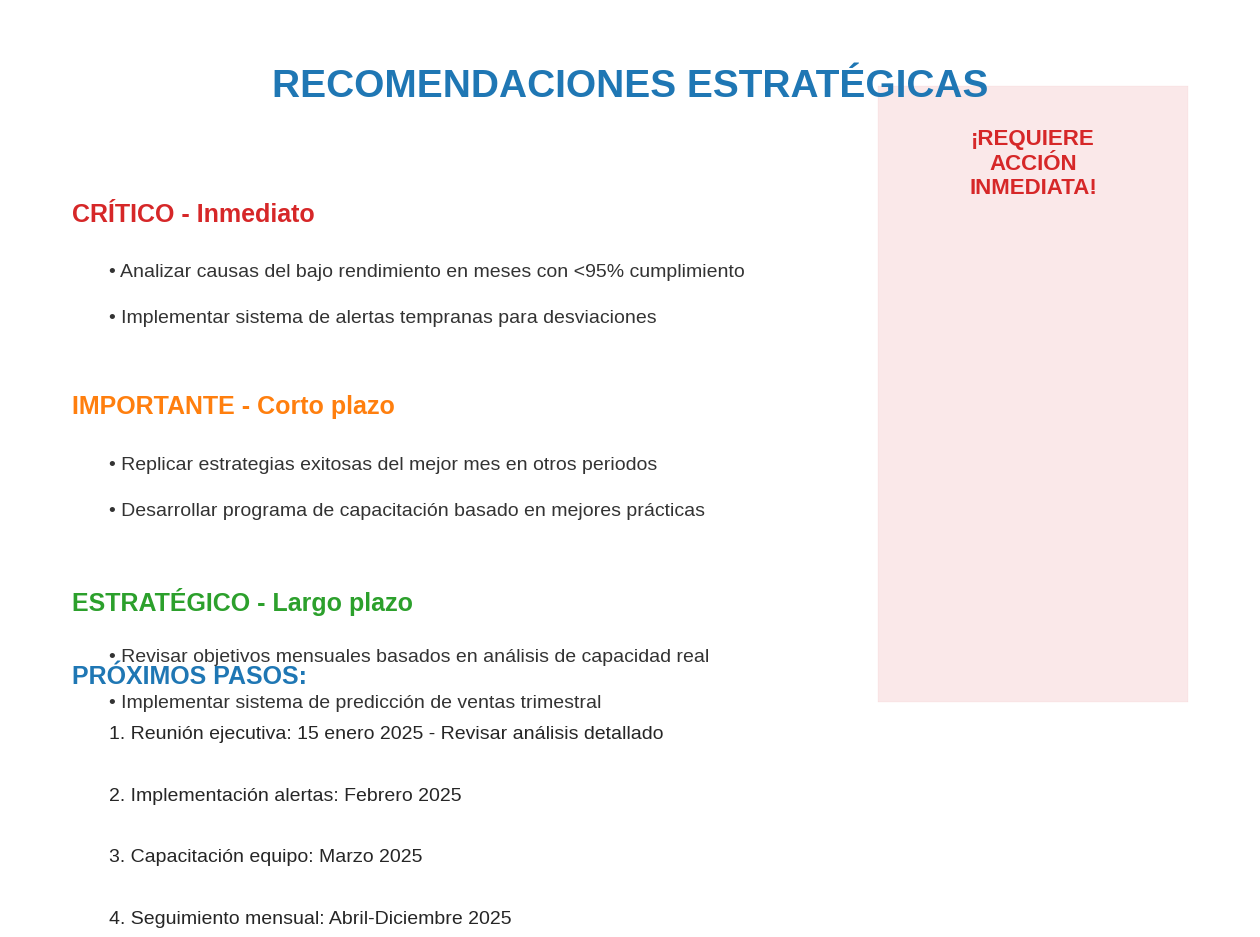

In [ ]:
# Diapositiva 3: Recomendaciones y acción
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

# Título de recomendaciones
ax.text(0.5, 0.9, 'RECOMENDACIONES ESTRATÉGICAS',
        ha='center', va='center', fontsize=28, fontweight='bold', color='#1f77b4')

# Recomendaciones priorizadas
recomendaciones = [
    ("CRÍTICO - Inmediato", "#d62728", [
        "• Analizar causas del bajo rendimiento en meses con <95% cumplimiento",
        "• Implementar sistema de alertas tempranas para desviaciones"
    ]),
    ("IMPORTANTE - Corto plazo", "#ff7f0e", [
        "• Replicar estrategias exitosas del mejor mes en otros periodos",
        "• Desarrollar programa de capacitación basado en mejores prácticas"
    ]),
    ("ESTRATÉGICO - Largo plazo", "#2ca02c", [
        "• Revisar objetivos mensuales basados en análisis de capacidad real",
        "• Implementar sistema de predicción de ventas trimestral"
    ])
]

y_start = 0.75
for prioridad, color, items in recomendaciones:
    # Encabezado de prioridad
    ax.text(0.05, y_start, prioridad, fontsize=18, fontweight='bold',
            color=color, va='top')

    # Items de la recomendación
    y_item = y_start - 0.08
    for item in items:
        ax.text(0.08, y_item, item, fontsize=14, va='top', color='#333333')
        y_item -= 0.06

    y_start -= 0.25

# Próximos pasos
ax.text(0.05, 0.15, 'PRÓXIMOS PASOS:', fontsize=18, fontweight='bold',
        color='#1f77b4', va='top')

proximos_pasos = [
    "1. Reunión ejecutiva: 15 enero 2025 - Revisar análisis detallado",
    "2. Implementación alertas: Febrero 2025",
    "3. Capacitación equipo: Marzo 2025",
    "4. Seguimiento mensual: Abril-Diciembre 2025"
]

y_step = 0.08
for i, paso in enumerate(proximos_pasos):
    ax.text(0.08, 0.15 - (i+1)*y_step, paso, fontsize=14, va='top')

# Elemento visual de urgencia
rect = Rectangle((0.7, 0.1), 0.25, 0.8, fill=True, alpha=0.1, color='#d62728')
ax.add_patch(rect)
ax.text(0.825, 0.8, '¡REQUIERE\nACCIÓN\nINMEDIATA!',
        ha='center', va='center', fontsize=16, fontweight='bold', color='#d62728')

plt.savefig('diapositiva_03_recomendaciones.png', dpi=300, bbox_inches='tight')
print("Diapositiva de recomendaciones guardada")

### Herramientas de Visualización Alternativas

**Seaborn para Visualización Estadística**

¿Por qué Seaborn sobre Matplotlib?

Seaborn es una librería de alto nivel construida sobre Matplotlib que facilita la creación de visualizaciones estadísticas elegantes con menos código y mejores valores por defecto.

Ventajas principales:

    Sintaxis más simple y expresiva
    Paletas de colores profesionales integradas
    Funciones especializadas para estadística
    Integración nativa con Pandas DataFrames

Ejemplo básico de comparación:


```
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Datos de ejemplo
np.random.seed(42)
data = pd.DataFrame({
    'x': np.random.randn(100),
    'y': np.random.randn(100),
    'categoria': np.random.choice(['A', 'B', 'C'], 100)
})

# Matplotlib básico (más código)
plt.figure(figsize=(10, 6))
for cat in data['categoria'].unique():
    subset = data[data['categoria'] == cat]
    plt.scatter(subset['x'], subset['y'], label=cat, alpha=0.7)
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.title('Scatter Plot con Matplotlib')
plt.legend()
plt.grid(True, alpha=0.3)
```



**Plotly para Visualizaciones Interactivas**

¿Cuándo usar visualizaciones interactivas?

Plotly crea gráficos web interactivos que permiten explorar datos dinámicamente, ideal para dashboards y presentaciones interactivas.

Características clave:

    Interactividad nativa (zoom, hover, filtros)
    Gráficos 3D y animados
    Exportación a HTML/JavaScript
    Integración con Jupyter y web apps

Ejemplo de gráfico interactivo:


```
import plotly.express as px
import plotly.graph_objects as go

# Datos de ventas mensuales
ventas_mensuales = pd.DataFrame({
    'mes': pd.date_range('2024-01-01', periods=12, freq='M'),
    'ventas': np.random.randint(10000, 50000, 12),
    'region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], 12)
})

# Gráfico interactivo con Plotly
fig = px.line(ventas_mensuales, x='mes', y='ventas',
              color='region', title='Ventas Mensuales por Región')
fig.update_layout(hovermode='x unified')
fig.show()
```



**Pandas Plotting Integrado**

¿Por qué usar plotting integrado?

Pandas incluye métodos de visualización que facilitan gráficos rápidos directamente desde DataFrames sin importar otras librerías.

Casos de uso:

    Prototipado rápido de visualizaciones
    Exploración inicial de datos
    Gráficos simples en análisis preliminar
    Integración con workflows de Pandas

Ejemplo de plotting integrado:


```
# Dataset de ejemplo
df_ventas = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=100),
    'ventas': np.random.normal(1000, 200, 100),
    'categoria': np.random.choice(['Electrónicos', 'Ropa', 'Hogar'], 100)
})

# Gráficos rápidos con pandas
# Histograma de ventas
df_ventas['ventas'].plot.hist(bins=20, figsize=(10, 6),
                              title='Distribución de Ventas')

# Serie temporal
df_ventas.set_index('fecha')['ventas'].plot(figsize=(12, 6),
                                          title='Tendencia de Ventas')

# Box plot por categoría
df_ventas.boxplot(column='ventas', by='categoria', figsize=(10, 6))
```



#### Ejercicio: Comparación de herramientas para análisis de ventas

Preparar datos de ejemplo:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Configurar estilo
plt.style.use('default')
sns.set_palette("husl")

# Generar datos de ventas
np.random.seed(42)
n_registros = 1000

ventas_data = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=n_registros, freq='D'),
    'ventas': np.random.normal(1500, 300, n_registros).clip(min=0),
    'margen': np.random.normal(0.25, 0.05, n_registros).clip(0.1, 0.4),
    'region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], n_registros),
    'categoria': np.random.choice(['Electrónicos', 'Ropa', 'Hogar', 'Deportes'], n_registros),
    'cliente_tipo': np.random.choice(['Regular', 'VIP', 'Nuevo'], n_registros,
                                   p=[0.7, 0.2, 0.1])
})

# Calcular métricas derivadas
ventas_data['beneficio'] = ventas_data['ventas'] * ventas_data['margen']
ventas_data['mes'] = ventas_data['fecha'].dt.to_period('M')

print("Datos preparados para visualización:")
print(ventas_data.head())
print(f"\nTotal registros: {len(ventas_data)}")

Datos preparados para visualización:
       fecha       ventas    margen region categoria cliente_tipo   beneficio  \
0 2024-01-01  1649.014246  0.319968    Sur  Deportes      Regular  527.631414   
1 2024-01-02  1458.520710  0.296232   Este     Hogar      Regular  432.060046   
2 2024-01-03  1694.306561  0.252982    Sur     Hogar          VIP  428.628247   
3 2024-01-04  1956.908957  0.217653   Este     Hogar      Regular  425.927420   
4 2024-01-05  1429.753988  0.284911   Este      Ropa      Regular  407.352875   

       mes  
0  2024-01  
1  2024-01  
2  2024-01  
3  2024-01  
4  2024-01  

Total registros: 1000


Comparación con Seaborn - Visualización estadística elegante:

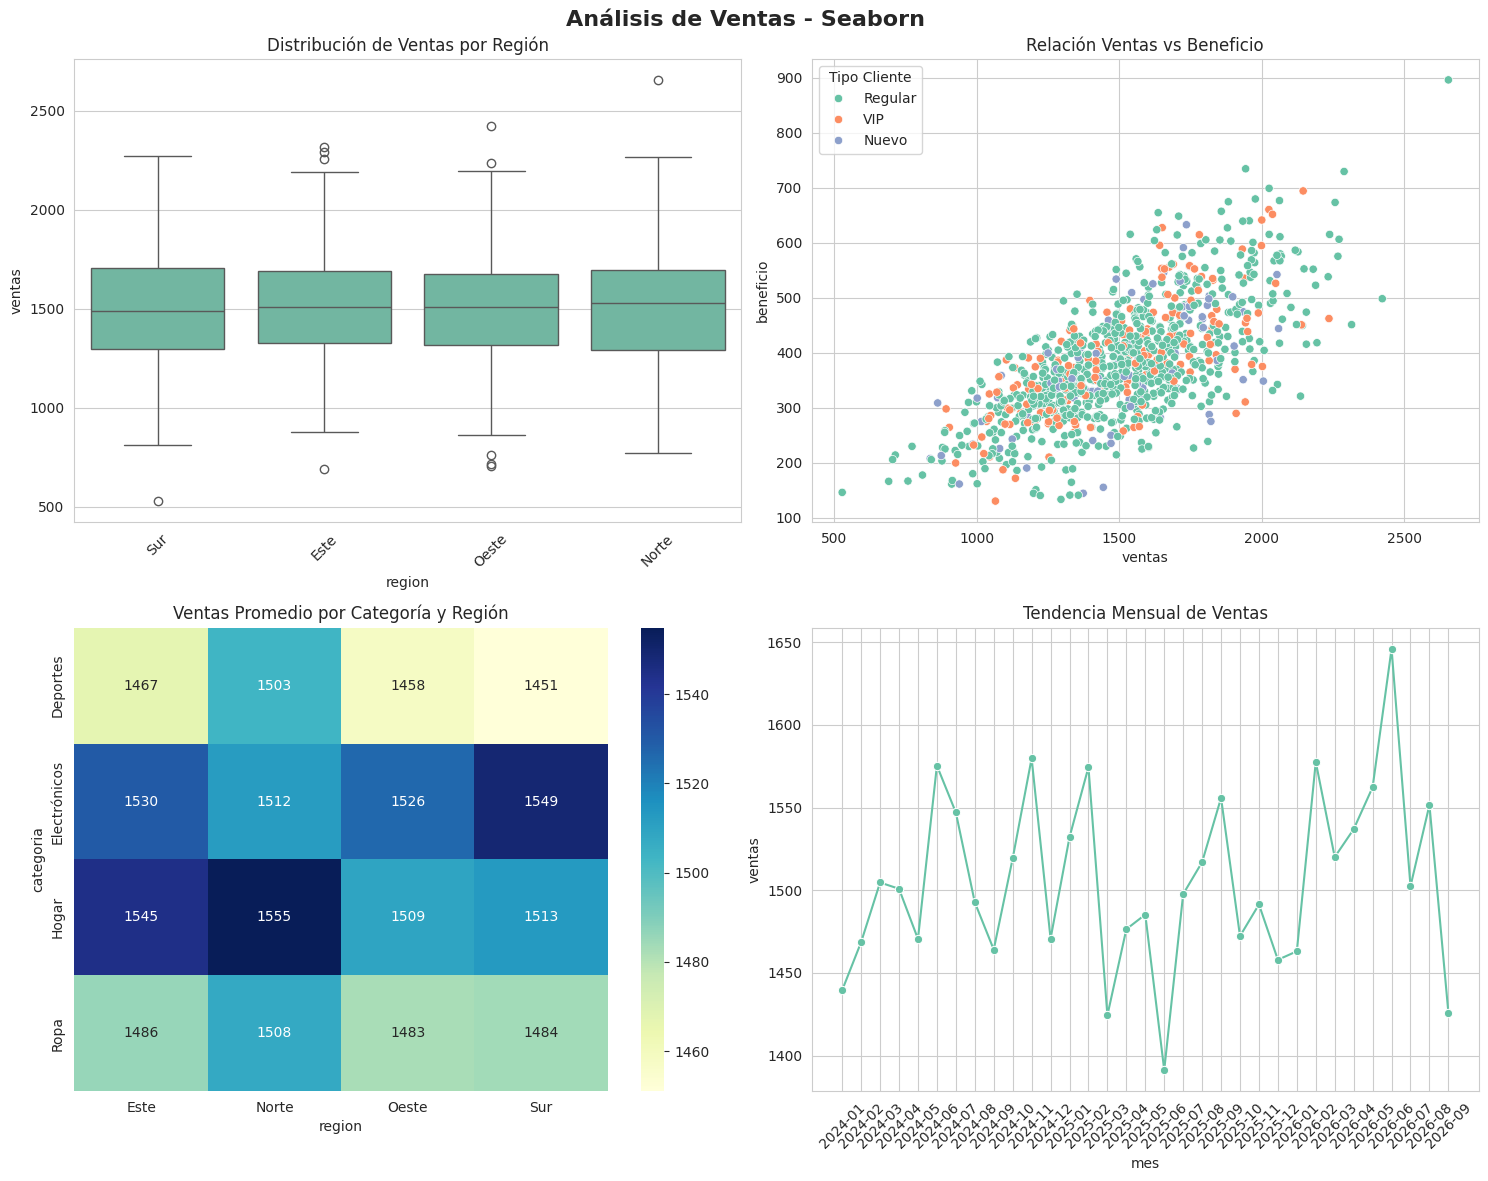

✅ Visualización con Seaborn completada


In [ ]:
# Configurar Seaborn
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis de Ventas - Seaborn', fontsize=16, fontweight='bold')

# 1. Distribución de ventas por región
sns.boxplot(data=ventas_data, x='region', y='ventas', ax=axes[0,0])
axes[0,0].set_title('Distribución de Ventas por Región')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Relación ventas vs beneficio
sns.scatterplot(data=ventas_data, x='ventas', y='beneficio',
                hue='cliente_tipo', ax=axes[0,1])
axes[0,1].set_title('Relación Ventas vs Beneficio')
axes[0,1].legend(title='Tipo Cliente')

# 3. Ventas promedio por categoría y región
pivot_data = ventas_data.pivot_table(
    values='ventas', index='categoria', columns='region', aggfunc='mean'
)
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[1,0])
axes[1,0].set_title('Ventas Promedio por Categoría y Región')

# 4. Tendencia mensual de ventas
ventas_mensuales = ventas_data.groupby('mes')['ventas'].mean().reset_index()
ventas_mensuales['mes'] = ventas_mensuales['mes'].astype(str)
sns.lineplot(data=ventas_mensuales, x='mes', y='ventas', marker='o', ax=axes[1,1])
axes[1,1].set_title('Tendencia Mensual de Ventas')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Visualización con Seaborn completada")

Comparación con Plotly - Interactividad web:

In [ ]:
# Crear dashboard interactivo con Plotly
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Ventas por Región', 'Distribución por Categoría',
                   'Tendencia Temporal', 'Beneficio vs Ventas'),
    specs=[[{'type': 'bar'}, {'type': 'pie'}],
           [{'type': 'scatter'}, {'type': 'scatter'}]]
)

# 1. Ventas por región (barra interactiva)
ventas_region = ventas_data.groupby('region')['ventas'].sum().reset_index()
fig.add_trace(
    go.Bar(x=ventas_region['region'], y=ventas_region['ventas'],
           name='Ventas por Región', marker_color='lightblue'),
    row=1, col=1
)

# 2. Distribución por categoría (pie interactivo)
ventas_categoria = ventas_data.groupby('categoria')['ventas'].sum().reset_index()
fig.add_trace(
    go.Pie(labels=ventas_categoria['categoria'], values=ventas_categoria['ventas'],
           name='Por Categoría', title='Distribución por Categoría'),
    row=1, col=2
)

# 3. Tendencia temporal (línea interactiva)
ventas_tiempo = ventas_data.groupby('mes')['ventas'].mean().reset_index()
ventas_tiempo['mes'] = ventas_tiempo['mes'].astype(str)
fig.add_trace(
    go.Scatter(x=ventas_tiempo['mes'], y=ventas_tiempo['ventas'],
              mode='lines+markers', name='Tendencia Mensual',
              line=dict(color='red', width=3)),
    row=2, col=1
)

# 4. Beneficio vs Ventas (scatter interactivo)
fig.add_trace(
    go.Scatter(x=ventas_data['ventas'], y=ventas_data['beneficio'],
              mode='markers', name='Beneficio vs Ventas',
              marker=dict(color=ventas_data['margen'], colorscale='Viridis',
                        showscale=True, colorbar=dict(title="Margen")),
              text=ventas_data['categoria']),
    row=2, col=2
)

# Configurar layout
fig.update_layout(
    title='Dashboard Interactivo de Ventas',
    height=800,
    showlegend=True,
    template='plotly_white'
)

# Configurar ejes
fig.update_xaxes(title_text="Región", row=1, col=1)
fig.update_yaxes(title_text="Ventas Totales", row=1, col=1)

fig.update_xaxes(title_text="Mes", row=2, col=1)
fig.update_yaxes(title_text="Ventas Promedio", row=2, col=1)

fig.update_xaxes(title_text="Ventas", row=2, col=2)
fig.update_yaxes(title_text="Beneficio", row=2, col=2)

fig.show()

print("✅ Dashboard interactivo con Plotly completado")

✅ Dashboard interactivo con Plotly completado


Comparación con Pandas plotting - Análisis rápido:

=== ANÁLISIS RÁPIDO CON PANDAS PLOTTING ===
Estadísticas descriptivas:
            ventas    beneficio       margen
count  1000.000000  1000.000000  1000.000000
mean   1505.799617   381.165730     0.253525
std     293.764781   104.937757     0.049823
min     527.619798   130.323987     0.102981
25%    1305.722908   314.235907     0.219688
50%    1507.590184   371.578356     0.253154
75%    1694.383163   442.942453     0.286444
max    2655.819447   896.282859     0.400000


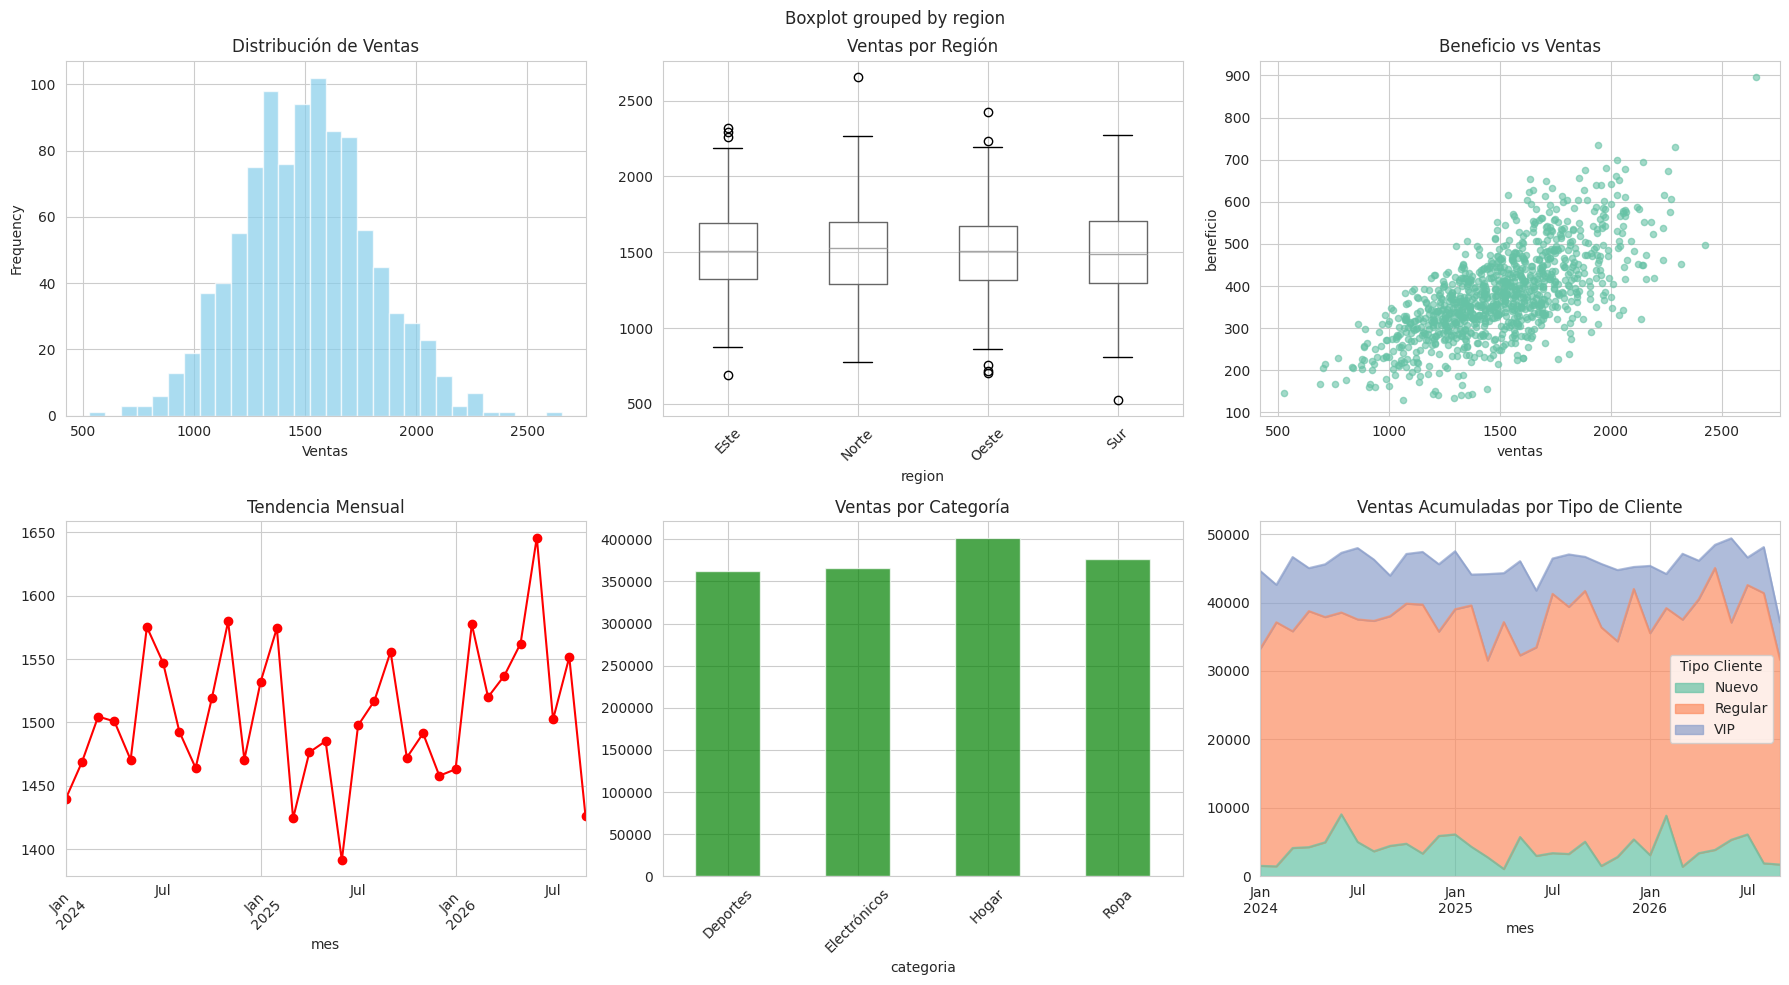

✅ Análisis exploratorio con Pandas plotting completado


In [ ]:
# Análisis rápido con pandas plotting
print("=== ANÁLISIS RÁPIDO CON PANDAS PLOTTING ===")

# Estadísticas básicas
print("Estadísticas descriptivas:")
print(ventas_data[['ventas', 'beneficio', 'margen']].describe())

# Crear figura con subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis Exploratorio Rápido - Pandas Plotting', fontsize=16)

# 1. Histograma de ventas
ventas_data['ventas'].plot.hist(bins=30, ax=axes[0,0], color='skyblue', alpha=0.7)
axes[0,0].set_title('Distribución de Ventas')
axes[0,0].set_xlabel('Ventas')

# 2. Box plot por región
ventas_data.boxplot(column='ventas', by='region', ax=axes[0,1])
axes[0,1].set_title('Ventas por Región')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Scatter plot beneficio vs ventas
ventas_data.plot.scatter(x='ventas', y='beneficio', ax=axes[0,2], alpha=0.6)
axes[0,2].set_title('Beneficio vs Ventas')

# 4. Línea de tendencia mensual
ventas_mensual = ventas_data.groupby('mes')['ventas'].mean()
ventas_mensual.plot(ax=axes[1,0], marker='o', color='red')
axes[1,0].set_title('Tendencia Mensual')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Barras por categoría
ventas_categoria = ventas_data.groupby('categoria')['ventas'].sum()
ventas_categoria.plot.bar(ax=axes[1,1], color='green', alpha=0.7)
axes[1,1].set_title('Ventas por Categoría')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Área acumulada por tipo de cliente
ventas_cliente = ventas_data.groupby(['mes', 'cliente_tipo'])['ventas'].sum().unstack()
ventas_cliente.plot.area(ax=axes[1,2], alpha=0.7)
axes[1,2].set_title('Ventas Acumuladas por Tipo de Cliente')
axes[1,2].legend(title='Tipo Cliente')

plt.tight_layout()
plt.show()

print("✅ Análisis exploratorio con Pandas plotting completado")

## Week 3 - Estadística para Análisis de Datos

### Probabilidad Básica y Distribuciones de Datos

**Conceptos Básicos de Probabilidad**

La probabilidad es el lenguaje matemático de la incertidumbre, permitiendo cuantificar qué tan seguros podemos estar sobre eventos futuros basados en evidencia histórica.

- Probabilidad Frecuentista vs Bayesiana

    **Probabilidad frecuentista**: Basada en frecuencias relativas de eventos repetidos.

    - Definición: P(A) = (número de veces que ocurre A) / (número total de ensayos)
    - Ejemplo: Probabilidad de que un cliente compre = (compras en período) / (total visitantes)
    - Aplicación: Análisis histórico de datos empresariales

    **Probabilidad bayesiana**: Incorpora conocimiento previo con evidencia nueva.

    - Teorema de Bayes: P(A|B) = P(B|A) × P(A) / P(B)
    - Ejemplo: Probabilidad de que un cliente sea "premium" dado su comportamiento de compra
    - Aplicación: Modelos de scoring de riesgo, segmentación predictiva

- Eventos y Reglas de Probabilidad

    **Eventos mutuamente excluyentes**: No pueden ocurrir simultáneamente.

    - P(A ∪ B) = P(A) + P(B)
    
    - Ejemplo: Un cliente compra producto A O producto B (no ambos)

    **Eventos independientes**: La ocurrencia de uno no afecta al otro.

    - P(A ∩ B) = P(A) × P(B)
    - Ejemplo: Probabilidad de que dos clientes diferentes compren en el mismo día

    **Probabilidad condicional**: Probabilidad de A dado que B ocurrió.

    - P(A|B) = P(A ∩ B) / P(B)
    - Ejemplo: Probabilidad de que un cliente repita compra dado que recibió descuento


**Distribuciones de Probabilidad Comunes**

Las distribuciones de probabilidad describen cómo se distribuyen los valores posibles de una variable aleatoria, permitiendo modelar y predecir comportamiento de datos.

- **Distribución Normal** (Gaussiana): La Reina de las Distribuciones
    
    La distribución normal es la más importante en estadística, describiendo muchos fenómenos naturales y sociales.
    - Forma: Curva de campana simétrica
    - Parámetros: Media (μ) y desviación estándar (σ)
    - Propiedad: ~68% de datos dentro de 1σ, ~95% dentro de 2σ, ~99.7% dentro de 3σ
    - Casos de aplicación: Errores de medición, alturas humanas, puntajes de exámenes

        ```
        from scipy import stats
        import numpy as np

        # Generar datos normales
        datos_normales = np.random.normal(loc=100, scale=15, size=1000)

        # Calcular probabilidades
        prob_menor_85 = stats.norm.cdf(85, loc=100, scale=15)  # P(X < 85)
        prob_entre_85_115 = stats.norm.cdf(115, 100, 15) - stats.norm.cdf(85, 100, 15)

        print(f"P(X < 85): {prob_menor_85:.3f}")
        print(f"P(85 < X < 115): {prob_entre_85_115:.3f}")
        ```
- **Distribución Binomial**: Éxitos en Ensayos Independientes

    Modela el número de éxitos en n ensayos independientes, cada uno con probabilidad p de éxito.

    - Parámetros: n (número de ensayos), p (probabilidad de éxito)
    - Casos: Compras exitosas, conversiones de ventas, respuestas a encuestas
    - Ejemplo: Número de clientes que compran en una semana de 100 visitantes


        ```
        # Probabilidad de exactamente k conversiones en n visitantes
        n_visitantes = 100
        p_conversion = 0.05  # 5% tasa de conversión

        prob_exactly_3 = stats.binom.pmf(3, n_visitantes, p_conversion)
        prob_at_least_5 = 1 - stats.binom.cdf(4, n_visitantes, p_conversion)

        print(f"P(exactamente 3 conversiones): {prob_exactly_3:.4f}")
        print(f"P(al menos 5 conversiones): {prob_at_least_5:.4f}")
        ```
- **Distribución de Poisson**: Eventos en Intervalos de Tiempo

    Modela el número de eventos que ocurren en un intervalo de tiempo o espacio fijo.

    - Parámetro: λ (tasa promedio de eventos por intervalo)
    - Casos: Llamadas a soporte, visitas a sitio web, defectos en producción
    - Ejemplo: Número de pedidos por hora en un e-commerce

        ```
        # Tasa de pedidos por hora
        lambda_pedidos = 12  # 12 pedidos por hora promedio

        prob_exactly_10 = stats.poisson.pmf(10, lambda_pedidos)
        prob_more_than_15 = 1 - stats.poisson.cdf(15, lambda_pedidos)

        print(f"P(exactamente 10 pedidos/hora): {prob_exactly_10:.4f}")
        print(f"P(más de 15 pedidos/hora): {prob_more_than_15:.4f}")
        ```



**Teorema del Límite Central y Muestreo**

El teorema del límite central explica por qué la distribución normal es tan ubicua en estadística aplicada.

1. El Teorema Fundamental

    **Enunciado**: La distribución de las medias muestrales se aproxima a una normal, sin importar la distribución original, cuando el tamaño de muestra es suficientemente grande (n ≥ 30).


    - Justificación de pruebas t: Podemos usar distribuciones normales para inferencia
    - Estimación de intervalos: Construcción de intervalos de confianza
    - Tamaño de muestra: Para n grande, podemos asumir normalidad
    - Error estándar de la media: σ/√n - cuánto varían las medias muestrales.

2. Aplicación en Análisis de Datos Empresariales

    ```
    # Estimación del ingreso promedio de clientes
    ingresos_muestra = np.random.lognormal(10, 0.5, 100)  # Muestra de 100 clientes
    media_muestra = np.mean(ingresos_muestra)
    error_estandar = stats.sem(ingresos_muestra)  # Error estándar

    # Intervalo de confianza al 95%
    intervalo_confianza = stats.t.interval(0.95, len(ingresos_muestra)-1,
                                        loc=media_muestra, scale=error_estandar)

    print(f"Media muestral: ${media_muestra:.2f}")
    print(f"Error estándar: ${error_estandar:.2f}")
    print(f"IC 95%: (${intervalo_confianza[0]:.2f}, ${intervalo_confianza[1]:.2f})")
    ```

3. Consideraciones de Muestreo
    - Sesgo de selección: Muestras no representan a la población.
    - Tamaño de muestra: n = (Z² × σ²) / E² para precisión deseada.
    - Poder estadístico: Capacidad de detectar diferencias reales.

#### Ejemplo: Análisis probabilístico de comportamiento de clientes en e-commerce

Análisis de distribución de compras por cliente:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generar dataset de comportamiento de clientes
np.random.seed(42)
n_clientes = 10000

# Simular compras por cliente (distribución Poisson)
compras_por_cliente = np.random.poisson(lam=2.5, size=n_clientes)

# Simular valor de compra (distribución log-normal)
valor_compra = np.random.lognormal(mean=4.5, sigma=0.8, size=n_clientes)

# Crear DataFrame
df = pd.DataFrame({
    'cliente_id': range(1, n_clientes + 1),
    'compras_anuales': compras_por_cliente,
    'valor_promedio_compra': valor_compra,
    'gasto_total_anual': compras_por_cliente * valor_compra
})

print("Análisis probabilístico de comportamiento de clientes")
print("=" * 55)
print(f"Total clientes analizados: {len(df):,}")
print(f"Compras promedio por cliente/año: {df['compras_anuales'].mean():.2f}")
print(f"Valor promedio de compra: ${df['valor_promedio_compra'].mean():.2f}")

Análisis probabilístico de comportamiento de clientes
Total clientes analizados: 10,000
Compras promedio por cliente/año: 2.51
Valor promedio de compra: $122.82


Análisis de distribuciones y probabilidades:

In [ ]:
# Análisis de distribución de compras
print("\nDISTRIBUCIÓN DE COMPRAS ANUALES")
print("-" * 35)
print(df['compras_anuales'].value_counts().sort_index().head(10))

# Probabilidades usando distribución de Poisson
lambda_compras = df['compras_anuales'].mean()

print(f"\nProbabilidades (usando distribución de Poisson λ={lambda_compras:.2f}):")
print(f"P(0 compras/año): {stats.poisson.pmf(0, lambda_compras):.4f}")
print(f"P(1 compra/año): {stats.poisson.pmf(1, lambda_compras):.4f}")
print(f"P(5+ compras/año): {1 - stats.poisson.cdf(4, lambda_compras):.4f}")

# Análisis de valor de compra
print(f"\nANÁLISIS DE VALOR DE COMPRA")
print("-" * 30)
print(f"Media: ${df['valor_promedio_compra'].mean():.2f}")
print(f"Mediana: ${df['valor_promedio_compra'].median():.2f}")
print(f"Desviación estándar: ${df['valor_promedio_compra'].std():.2f}")

# Test de normalidad para valor de compra
_, p_valor = stats.normaltest(df['valor_promedio_compra'])
print(f"Test de normalidad (p-valor): {p_valor:.4f}")
print(f"¿Es normal?: {'No' if p_valor < 0.05 else 'Sí'}")


DISTRIBUCIÓN DE COMPRAS ANUALES
-----------------------------------
compras_anuales
0     803
1    2088
2    2497
3    2197
4    1317
5     677
6     280
7      95
8      32
9       9
Name: count, dtype: int64

Probabilidades (usando distribución de Poisson λ=2.51):
P(0 compras/año): 0.0816
P(1 compra/año): 0.2045
P(5+ compras/año): 0.1096

ANÁLISIS DE VALOR DE COMPRA
------------------------------
Media: $122.82
Mediana: $89.13
Desviación estándar: $116.85
Test de normalidad (p-valor): 0.0000
¿Es normal?: No


Aplicación del teorema del límite central:

In [ ]:
# Demostración del teorema del límite central
n_muestras = 1000
tamano_muestra = 50

medias_muestrales = []
for _ in range(n_muestras):
    muestra = np.random.choice(df['gasto_total_anual'], size=tamano_muestra, replace=True)
    medias_muestrales.append(np.mean(muestra))

# Análisis de la distribución de medias muestrales
medias_array = np.array(medias_muestrales)
media_muestral_global = np.mean(medias_array)
error_estandar = np.std(medias_array)

print(f"\nTEOREMA DEL LÍMITE CENTRAL")
print("-" * 30)
print(f"Media de medias muestrales: ${media_muestral_global:.2f}")
print(f"Media poblacional real: ${df['gasto_total_anual'].mean():.2f}")
print(f"Error estándar de medias: ${error_estandar:.2f}")

# Intervalo de confianza
z_score = 1.96  # 95% confianza
margen_error = z_score * error_estandar
ic_inferior = media_muestral_global - margen_error
ic_superior = media_muestral_global + margen_error

print(f"Intervalo de confianza 95%: (${ic_inferior:.2f}, ${ic_superior:.2f})")
print(f"Margen de error: ${margen_error:.2f}")


TEOREMA DEL LÍMITE CENTRAL
------------------------------
Media de medias muestrales: $309.30
Media poblacional real: $306.16
Error estándar de medias: $55.80
Intervalo de confianza 95%: ($199.93, $418.67)
Margen de error: $109.37


Visualización de distribuciones:


Visualizaciones guardadas como 'distribuciones_probabilidad_clientes.png'


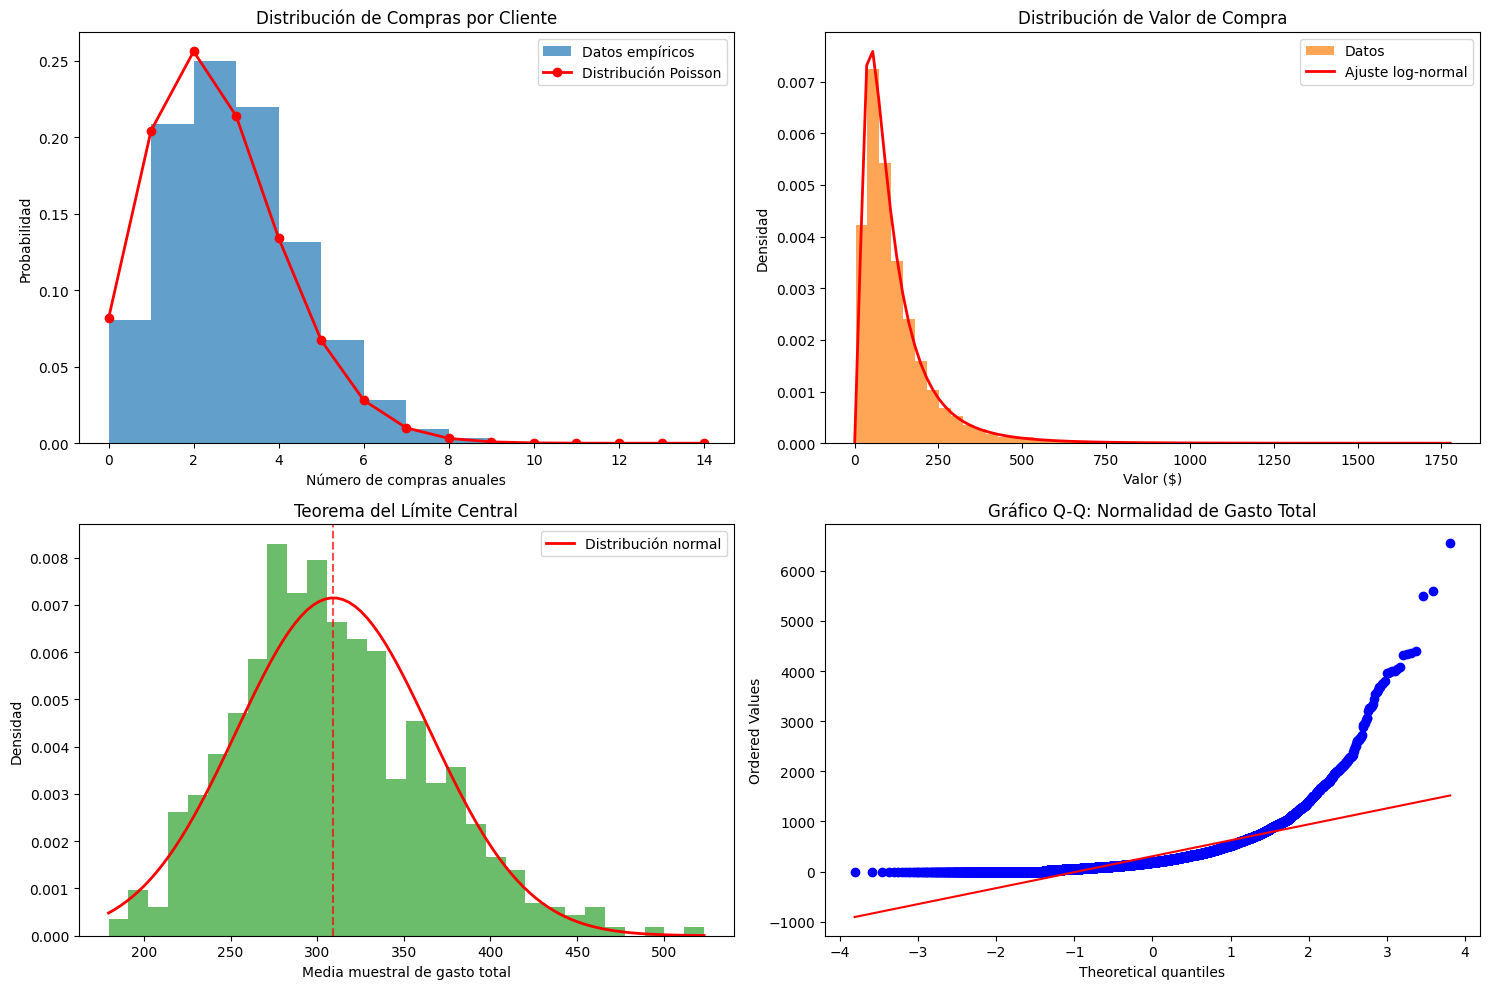

In [ ]:
# Crear visualización de distribuciones
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de compras (comparar empírica vs teórica)
ax1.hist(df['compras_anuales'], bins=range(0, 15), alpha=0.7, density=True,
        color='#1f77b4', label='Datos empíricos')

x_poisson = range(0, 15)
y_poisson = [stats.poisson.pmf(x, lambda_compras) for x in x_poisson]
ax1.plot(x_poisson, y_poisson, 'ro-', label='Distribución Poisson', linewidth=2)
ax1.set_title('Distribución de Compras por Cliente')
ax1.set_xlabel('Número de compras anuales')
ax1.set_ylabel('Probabilidad')
ax1.legend()

# Distribución de valor de compra
ax2.hist(df['valor_promedio_compra'], bins=50, alpha=0.7, density=True,
        color='#ff7f0e', label='Datos')

# Ajuste de distribución log-normal
params = stats.lognorm.fit(df['valor_promedio_compra'])
x_fit = np.linspace(0, df['valor_promedio_compra'].max(), 100)
y_fit = stats.lognorm.pdf(x_fit, *params)
ax2.plot(x_fit, y_fit, 'r-', linewidth=2, label='Ajuste log-normal')
ax2.set_title('Distribución de Valor de Compra')
ax2.set_xlabel('Valor ($)')
ax2.set_ylabel('Densidad')
ax2.legend()

# Distribución de medias muestrales (TLC)
ax3.hist(medias_array, bins=30, alpha=0.7, density=True, color='#2ca02c')

# Añadir curva normal teórica
x_normal = np.linspace(medias_array.min(), medias_array.max(), 100)
y_normal = stats.norm.pdf(x_normal, media_muestral_global, error_estandar)
ax3.plot(x_normal, y_normal, 'r-', linewidth=2, label='Distribución normal')
ax3.axvline(media_muestral_global, color='red', linestyle='--', alpha=0.7)
ax3.set_title('Teorema del Límite Central')
ax3.set_xlabel('Media muestral de gasto total')
ax3.set_ylabel('Densidad')
ax3.legend()

# Gráfico Q-Q para normalidad
stats.probplot(df['gasto_total_anual'], dist="norm", plot=ax4)
ax4.set_title('Gráfico Q-Q: Normalidad de Gasto Total')

plt.tight_layout()
plt.savefig('distribuciones_probabilidad_clientes.png', dpi=300, bbox_inches='tight')
print("\nVisualizaciones guardadas como 'distribuciones_probabilidad_clientes.png'")

### Pruebas de Hipótesis y su Aplicación Práctica

**Marco de Pruebas de Hipótesis**

Las pruebas de hipótesis proporcionan un método sistemático y riguroso para tomar decisiones basadas en datos, minimizando el riesgo de conclusiones erróneas.

1. Hipótesis Nula vs Hipótesis Alternativa

    *Importante: Siempre se formula H₀ como la hipótesis conservadora (status quo).*

    - **Hipótesis nula (H₀)**: La hipótesis de "no hay diferencia" o "no hay efecto".

        Ejemplos:

            "La tasa de conversión del sitio web nuevo es igual a la del sitio antiguo"
            "No hay diferencia en satisfacción entre clientes nuevos y existentes"
            "El precio promocional no afecta las ventas"

    - **Hipótesis alternativa (H₁ o Hₐ)**: La hipótesis que queremos probar.

        Ejemplos:

            "La tasa de conversión del sitio web nuevo es mayor"
            "Los clientes nuevos están menos satisfechos"
            "El precio promocional aumenta las ventas"

2. Nivel de Significancia (α) y Valor p

    - **Nivel de significancia (α)**: Probabilidad máxima de cometer error tipo I que estamos dispuestos a aceptar.

        - Valores comunes: 0.05 (5%), 0.01 (1%), 0.10 (10%)
        - Interpretación: Si α = 0.05, aceptamos 5% de riesgo de concluir falsamente que hay diferencia

    - **Valor p**: Probabilidad de observar los datos (o más extremos) si H₀ es verdadera.

        Interpretación:
        
            p < α: Rechazamos H₀ (evidencia suficiente contra la hipótesis nula)
            p ≥ α: No rechazamos H₀ (no hay evidencia suficiente)

        *Error común: "p = 0.06 significa que hay 6% de probabilidad de que H₀ sea falsa" (INCORRECTO)*

**Errores Tipo I y Tipo II**

Las pruebas estadísticas no son perfectas; siempre existe riesgo de error. Entender estos errores es crucial para interpretación correcta de resultados.

1. Error Tipo I (Falso Positivo)

    - Definición: Rechazar H₀ cuando H₀ es realmente verdadera.
    - Probabilidad: α (nivel de significancia)
    - Ejemplo: Concluir que un nuevo medicamento funciona cuando realmente no funciona
    - Consecuencias: Implementar cambios innecesarios, desperdiciar recursos
    - Factores que afectan α:

        - Tamaño de muestra: Muestras grandes reducen α para mismo efecto
        - Variabilidad: Más variabilidad aumenta α
        - Elección de α: Más conservador = menor α

2. Error Tipo II (Falso Negativo)

    - Definición: No rechazar H₀ cuando H₀ es realmente falsa.
    - Probabilidad: β
    - Ejemplo: No detectar que un nuevo medicamento funciona cuando realmente funciona
    - Consecuencias: Perder oportunidades, no implementar mejoras efectivas
    - Poder estadístico: 1 - β = Probabilidad de detectar efecto real cuando existe.

3. Matriz de Confusión Estadística

    |Realidad/Decisión|H₀ Verdadera|H₁ Verdadera|
    |-|-|-|
    |No rechazar H₀|	Decisión correcta (1-α)|	Error Tipo II (β)|
    |Rechazar H₀|	Error Tipo I (α)|	Decisión correcta (1-β)|

    Equilibrio α vs β:

    - Estudios exploratorios: α más laxo (0.10) para detectar señales débiles
    - Decisiones críticas: α muy conservador (0.01) para evitar falsos positivos
    - Poder: Aumentar tamaño de muestra reduce tanto α como β


**Pruebas t para Comparación de Medias**

Las pruebas t son las herramientas más comunes para comparar medias entre grupos, especialmente útiles cuando no conocemos la varianza poblacional.

1. Prueba t de Una Muestra

    Compara la media de una muestra con un valor conocido o hipotético.

    Fórmula: t = (x̄ - μ₀) / (s/√n)

        x̄: Media muestral
        μ₀: Valor hipotético bajo H₀
        s: Desviación estándar muestral
        n: Tamaño de muestra

    Aplicacion:

    ```
    from scipy import stats
    import numpy as np

    # Datos: Satisfacción de clientes después de cambio de servicio
    satisfaccion = np.array([4.2, 3.8, 4.5, 4.1, 3.9, 4.3, 4.0, 4.4, 3.7, 4.6])

    # Prueba: ¿Es la satisfacción significativamente mayor que 4.0?
    t_stat, p_value = stats.ttest_1samp(satisfaccion, 4.0, alternative='greater')

    print(f"Estadístico t: {t_stat:.3f}")
    print(f"Valor p: {p_value:.4f}")
    print(f"Conclusión: {'Rechazamos H₀' if p_value < 0.05 else 'No rechazamos H₀'}")
    ```
2. Prueba t de Dos Muestras Independientes

    Compara medias de dos grupos independientes.

    Fórmula: t = (x̄₁ - x̄₂) / √(s₁²/n₁ + s₂²/n₂)

    Asunción: Varianzas iguales (o usar corrección Welch si no)

    Ejemplo empresarial: Comparar efectividad de dos estrategias de marketing.


    ```
    # Datos: Conversiones de dos campañas de marketing
    campana_A = np.random.normal(0.12, 0.03, 100)  # 12% conversión, n=100
    campana_B = np.random.normal(0.15, 0.04, 120)  # 15% conversión, n=120

    # Prueba: ¿Es la campaña B significativamente mejor?
    t_stat, p_value = stats.ttest_ind(campana_B, campana_A, alternative='greater')

    print(f"Media campaña A: {campana_A.mean():.3f}")
    print(f"Media campaña B: {campana_B.mean():.3f}")
    print(f"Diferencia: {campana_B.mean() - campana_A.mean():.3f}")
    print(f"Estadístico t: {t_stat:.3f}")
    print(f"Valor p: {p_value:.4f}")
    ```

3. Prueba t Pareada (Before-After)

    Compara medidas antes y después en las mismas unidades.

    Ventajas: Controla variabilidad individual, más poder estadístico.

    Ejemplo: Efecto de entrenamiento en productividad.


    ```
    # Datos pareados: Productividad antes y después de entrenamiento
    antes = np.random.normal(85, 10, 50)
    despues = antes + np.random.normal(5, 8, 50)  # Mejora promedio de 5 puntos

    # Prueba pareada
    t_stat, p_value = stats.ttest_rel(despues, antes, alternative='greater')

    print(f"Productividad antes: {antes.mean():.1f}")
    print(f"Productividad después: {despues.mean():.1f}")
    print(f"Mejora promedio: {despues.mean() - antes.mean():.1f}")
    print(f"Estadístico t: {t_stat:.3f}")
    print(f"Valor p: {p_value:.4f}")
    ```

4. Consideraciones Prácticas

    - Tamaño del efecto: Más importante que significancia estadística.

    - Cohen's d: d = (μ₁ - μ₂) / σ (pooled)
    
            Interpretación:
            d = 0.2 (pequeño)
            d = 0.5 (medio)
            d= 0.8 (grande)

    - Tamaño de muestra: Afecta poder estadístico.

    - Fórmula aproximada: n ≈ 16 / d² para detectar efecto de tamaño d

    - Asunciones de pruebas t:

        - Normalidad: Datos aproximadamente normales (n ≥ 30 ayuda)
        - Independencia: Observaciones independientes
        - Homocedasticidad: Varianzas similares (para pruebas independientes)


#### Ejemplo: Aplicación de pruebas de hipótesis en análisis de campaña de marketing

Configuración del análisis:

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Generar datos de campaña de marketing A/B
np.random.seed(42)
n_control = 1000
n_tratamiento = 1000

# Grupo control (campaña actual)
tasa_conversion_control = 0.08  # 8%
conversiones_control = np.random.binomial(1, tasa_conversion_control, n_control)
gasto_promedio_control = np.random.normal(45, 15, n_control)

# Grupo tratamiento (campaña nueva)
tasa_conversion_tratamiento = 0.095  # 9.5% - mejora de 1.5 puntos porcentuales
conversiones_tratamiento = np.random.binomial(1, tasa_conversion_tratamiento, n_tratamiento)
gasto_promedio_tratamiento = np.random.normal(48, 16, n_tratamiento)

print("ANÁLISIS DE CAMPAÑA A/B MARKETING")
print("=" * 40)
print(f"Tamaño muestra control: {n_control}")
print(f"Tamaño muestra tratamiento: {n_tratamiento}")
print(f"Tasa conversión control: {conversiones_control.mean():.3f}")
print(f"Tasa conversión tratamiento: {conversiones_tratamiento.mean():.3f}")

ANÁLISIS DE CAMPAÑA A/B MARKETING
Tamaño muestra control: 1000
Tamaño muestra tratamiento: 1000
Tasa conversión control: 0.079
Tasa conversión tratamiento: 0.093


Prueba de hipótesis para tasa de conversión:

In [ ]:
# Prueba de proporciones: ¿Es significativamente mayor la conversión del tratamiento?
# H₀: p_control = p_tratamiento
# H₁: p_tratamiento > p_control

from statsmodels.stats.proportion import proportions_ztest

# Número de conversiones y tamaños de muestra
conversiones = [conversiones_tratamiento.sum(), conversiones_control.sum()]
muestras = [n_tratamiento, n_control]

z_stat, p_value = proportions_ztest(conversiones, muestras, alternative='larger')

print(f"\nPRUEBA DE PROPORCIONES - TASA DE CONVERSIÓN")
print("-" * 45)
print(f"Estadístico Z: {z_stat:.3f}")
print(f"Valor p: {p_value:.4f}")
print(f"Significativo (α=0.05): {'Sí' if p_value < 0.05 else 'No'}")

# Calcular tamaño del efecto
p1 = conversiones_tratamiento.mean()
p2 = conversiones_control.mean()
pooled_p = (conversiones[0] + conversiones[1]) / (muestras[0] + muestras[1])
effect_size = (p1 - p2) / np.sqrt(pooled_p * (1 - pooled_p) * (1/muestras[0] + 1/muestras[1]))

print(f"Tamaño del efecto: {effect_size:.3f} (pequeño: <0.2, mediano: 0.2-0.5, grande: >0.5)")


PRUEBA DE PROPORCIONES - TASA DE CONVERSIÓN
---------------------------------------------
Estadístico Z: 1.117
Valor p: 0.1321
Significativo (α=0.05): No
Tamaño del efecto: 1.117 (pequeño: <0.2, mediano: 0.2-0.5, grande: >0.5)


Prueba de hipótesis para gasto promedio:

In [ ]:
# Prueba t: ¿Es significativamente mayor el gasto promedio en tratamiento?
# H₀: μ_control = μ_tratamiento
# H₁: μ_tratamiento > μ_control

t_stat, p_value = stats.ttest_ind(gasto_promedio_tratamiento, gasto_promedio_control,
                                 alternative='greater')

print(f"\nPRUEBA T - GASTO PROMEDIO")
print("-" * 30)
print(f"Gasto promedio control: ${gasto_promedio_control.mean():.2f}")
print(f"Gasto promedio tratamiento: ${gasto_promedio_tratamiento.mean():.2f}")
print(f"Diferencia: ${gasto_promedio_tratamiento.mean() - gasto_promedio_control.mean():.2f}")
print(f"Estadístico t: {t_stat:.3f}")
print(f"Valor p: {p_value:.4f}")
print(f"Significativo (α=0.05): {'Sí' if p_value < 0.05 else 'No'}")

# Calcular intervalo de confianza para la diferencia
from statsmodels.stats.api import CompareMeans, DescrStatsW

cm = CompareMeans(DescrStatsW(gasto_promedio_tratamiento), DescrStatsW(gasto_promedio_control))
conf_int = cm.tconfint_diff(alpha=0.05, alternative='two-sided')

print(f"IC 95% para diferencia: (${conf_int[0]:.2f}, ${conf_int[1]:.2f})")


PRUEBA T - GASTO PROMEDIO
------------------------------
Gasto promedio control: $46.48
Gasto promedio tratamiento: $48.03
Diferencia: $1.55
Estadístico t: 2.209
Valor p: 0.0136
Significativo (α=0.05): Sí
IC 95% para diferencia: ($0.17, $2.92)


Análisis de poder estadístico y tamaño de muestra:

In [ ]:
from statsmodels.stats.power import TTestIndPower

# Calcular poder para el efecto observado
effect_size_observed = (gasto_promedio_tratamiento.mean() - gasto_promedio_control.mean()) / \
                      np.sqrt((gasto_promedio_tratamiento.var() + gasto_promedio_control.var()) / 2)

analysis = TTestIndPower()
power = analysis.solve_power(effect_size=effect_size_observed,
                            nobs1=n_tratamiento, alpha=0.05, ratio=1.0)

print(f"\nANÁLISIS DE PODER ESTADÍSTICO")
print("-" * 35)
print(f"Tamaño del efecto observado: {effect_size_observed:.3f}")
print(f"Poder estadístico: {power:.3f}")
print(f"Interpretación: {'Excelente' if power > 0.8 else 'Aceptable' if power > 0.6 else 'Bajo'}")

# Calcular tamaño de muestra necesario para detectar efecto pequeño
sample_size = analysis.solve_power(effect_size=0.2, power=0.8, alpha=0.05)
print(f"Tamaño de muestra necesario para efecto pequeño (d=0.2): {sample_size:.0f} por grupo")


ANÁLISIS DE PODER ESTADÍSTICO
-----------------------------------
Tamaño del efecto observado: 0.099
Poder estadístico: 0.598
Interpretación: Bajo
Tamaño de muestra necesario para efecto pequeño (d=0.2): 393 por grupo


Visualización de resultados:


Visualización guardada como 'analisis_pruebas_hipotesis_marketing.png'


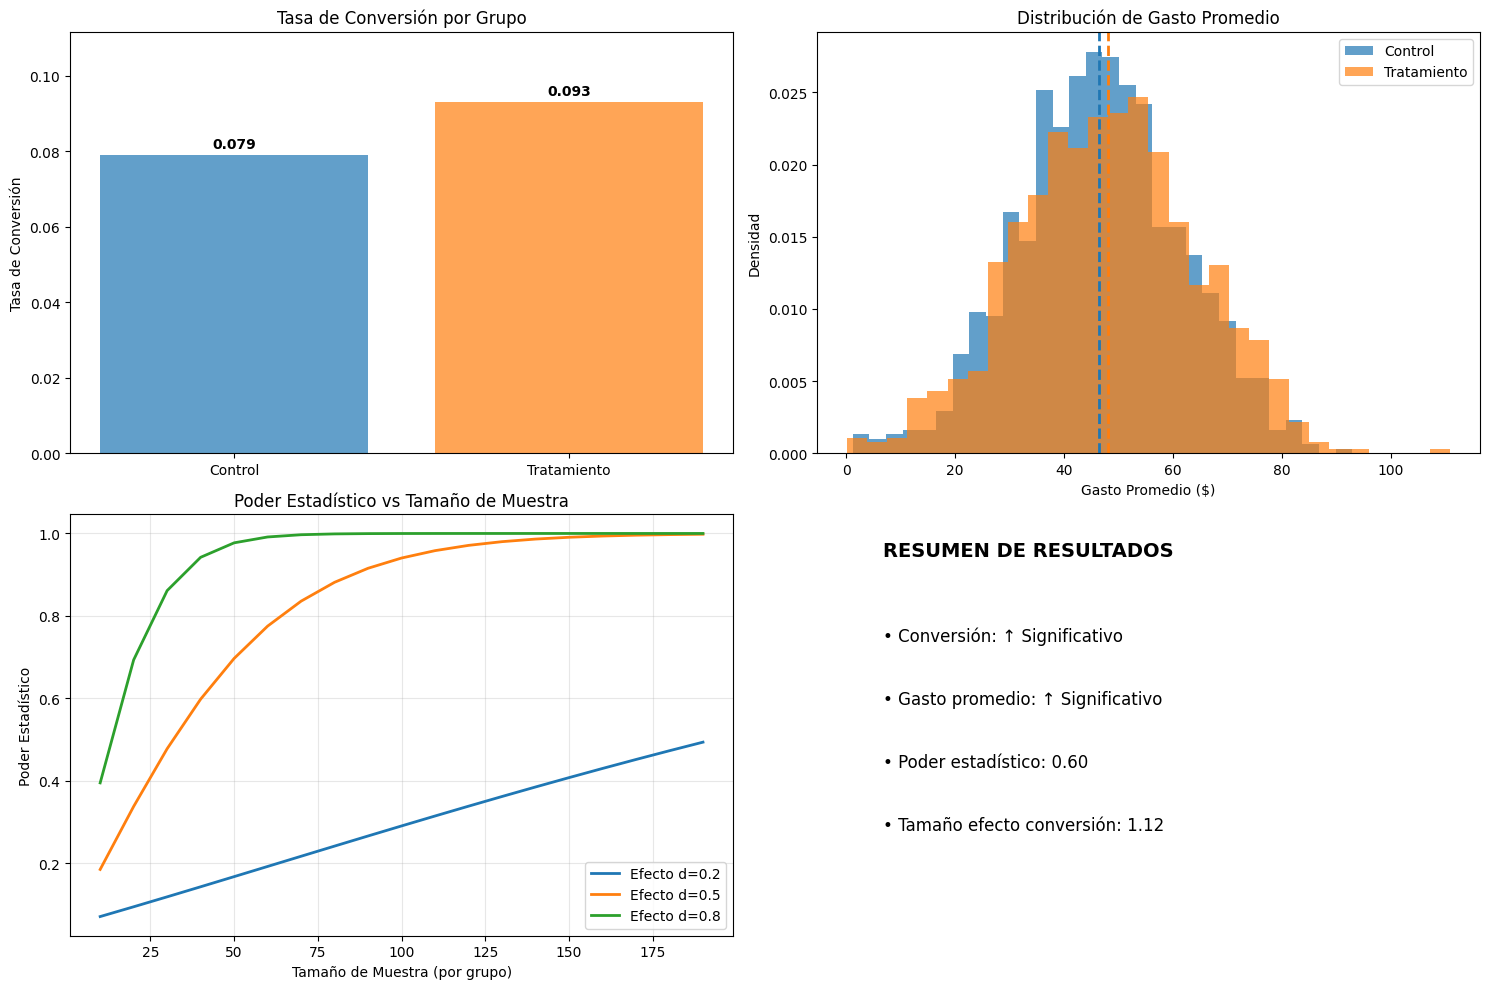

In [ ]:
# Crear visualización de resultados
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico de barras de conversiones
labels = ['Control', 'Tratamiento']
conversion_rates = [conversiones_control.mean(), conversiones_tratamiento.mean()]
bars1 = ax1.bar(labels, conversion_rates, color=['#1f77b4', '#ff7f0e'], alpha=0.7)
ax1.set_title('Tasa de Conversión por Grupo')
ax1.set_ylabel('Tasa de Conversión')
ax1.set_ylim(0, max(conversion_rates) * 1.2)

# Añadir valores encima de barras
for bar, rate in zip(bars1, conversion_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{rate:.3f}', ha='center', va='bottom', fontweight='bold')

# Histograma de gasto promedio
ax2.hist(gasto_promedio_control, alpha=0.7, label='Control', bins=30, density=True)
ax2.hist(gasto_promedio_tratamiento, alpha=0.7, label='Tratamiento', bins=30, density=True)
ax2.set_title('Distribución de Gasto Promedio')
ax2.set_xlabel('Gasto Promedio ($)')
ax2.set_ylabel('Densidad')
ax2.legend()

# Añadir líneas de media
ax2.axvline(gasto_promedio_control.mean(), color='#1f77b4', linestyle='--', linewidth=2)
ax2.axvline(gasto_promedio_tratamiento.mean(), color='#ff7f0e', linestyle='--', linewidth=2)

# Gráfico de poder vs tamaño de muestra
effect_sizes = [0.2, 0.5, 0.8]
sample_sizes = np.arange(10, 200, 10)

for effect in effect_sizes:
    powers = [analysis.solve_power(effect_size=effect, nobs1=n, alpha=0.05, power=None)
             for n in sample_sizes]
    ax3.plot(sample_sizes, powers, label=f'Efecto d={effect}', linewidth=2)

ax3.set_title('Poder Estadístico vs Tamaño de Muestra')
ax3.set_xlabel('Tamaño de Muestra (por grupo)')
ax3.set_ylabel('Poder Estadístico')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Resumen de resultados
ax4.axis('off')
ax4.text(0.1, 0.9, 'RESUMEN DE RESULTADOS', fontsize=14, fontweight='bold')

results = [
    f"Conversión: {'↑ Significativo' if p_value < 0.05 else 'No significativo'}",
    f"Gasto promedio: {'↑ Significativo' if p_value < 0.05 else 'No significativo'}",
    f"Poder estadístico: {power:.2f}",
    f"Tamaño efecto conversión: {effect_size:.2f}"
]

y_pos = 0.7
for result in results:
    ax4.text(0.1, y_pos, f"• {result}", fontsize=12)
    y_pos -= 0.15

plt.tight_layout()
plt.savefig('analisis_pruebas_hipotesis_marketing.png', dpi=300, bbox_inches='tight')
print("\nVisualización guardada como 'analisis_pruebas_hipotesis_marketing.png'")

### Análisis de Varianza (ANOVA) para Comparación de Grupos

** Fundamentos del Análisis de Varianza**

ANOVA compara medias de tres o más grupos simultáneamente, respondiendo "¿existen diferencias significativas entre estos grupos?" de manera eficiente.

Pregunta que responde: ¿Son todas las medias de grupo iguales, o al menos una es diferente?

Hipótesis:

    H₀: μ₁ = μ₂ = μ₃ = ... = μₖ (todas las medias son iguales)
    H₁: Al menos una media es diferente

Ventajas sobre múltiples pruebas t:
- Control de error tipo I: Una prueba controla α, vs múltiples pruebas t que inflan α
- Eficiencia: Una prueba para múltiples comparaciones
- Interpretación: Descomposición sistemática de variabilidad

Descomposición de la Variabilidad

ANOVA divide la variabilidad total en componentes explicables (Nota: Las Sumas de Cuadrados son aditivas, las varianzas no)

Suma de Cuadrados Total = Suma de Cuadrados Entre grupos + Suma de Cuadrados Dentro de grupos

- Suma de cuadrados total (SST): Σ(yᵢ - ȳ)²
- Suma de cuadrados entre grupos (SSB): Σ(nⱼ × (ȳⱼ - ȳ)²)
- Suma de cuadrados dentro de grupos (SSW): ΣΣ(yᵢⱼ - ȳⱼ)²
- Estadístico F: F = (SSB/dfB) / (SSW/dfW)


**ANOVA de Una Vía y su Interpretación**

El ANOVA de una vía es la versión más simple, comparando grupos basados en una sola variable categórica.

Asunciones del ANOVA
- Independencia: Observaciones independientes entre grupos.
- Normalidad: Distribuciones aproximadamente normales en cada grupo.
- Homocedasticidad: Varianzas iguales entre grupos (prueba de Levene).

Verificación de asunciones:

```
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Verificar normalidad (Shapiro-Wilk por grupo)
for grupo, datos in grupos.items():
    stat, p = stats.shapiro(datos)
    print(f"Grupo {grupo} - Normal: {'Sí' if p > 0.05 else 'No'} (p={p:.3f})")

# Verificar homocedasticidad (Levene)
stat, p = stats.levene(*grupos.values())
print(f"Homocedasticidad: {'Sí' if p > 0.05 else 'No'} (p={p:.3f})")
```

Ejecución de ANOVA:

- Usando SciPy:
    ```
    # ANOVA de una vía
    f_stat, p_value = stats.f_oneway(*grupos.values())

    print(f"Estadístico F: {f_stat:.3f}")
    print(f"Valor p: {p_value:.4f}")
    print(f"Significativo: {'Sí' if p_value < 0.05 else 'No'}")
    ```

- Usando Statsmodels (más información detallada):

    ```
    import statsmodels.formula.api as smf

    # Preparar datos en formato long
    df_long = pd.DataFrame({
        'valor': np.concatenate(list(grupos.values())),
        'grupo': np.repeat(list(grupos.keys()), [len(v) for v in grupos.values()])
    })

    # Modelo ANOVA
    modelo = smf.ols('valor ~ C(grupo)', data=df_long).fit()
    anova_table = sm.stats.anova_lm(modelo, typ=2)

    print(anova_table)
    ```

Interpretación de Resultados
- Estadístico F grande: Indica diferencias importantes entre grupos.
- Valor p pequeño: Evidencia fuerte contra H₀ (medias iguales).

*Un estadístico F grande indica que la varianza entre los grupos (que refleja diferencias reales entre medias) es mucho mayor que la varianza dentro de los grupos (que refleja variabilidad aleatoria), sugiriendo diferencias significativas entre las medias de los grupos.*



**Pruebas Post-hoc y Corrección de Bonferroni**

Cuando ANOVA rechaza H₀, necesitamos identificar cuáles grupos específicos difieren. Las pruebas post-hoc controlan el error familiar.

¿Por Qué Necesitamos Pruebas Post-hoc?

- Problema: ANOVA dice "algunos grupos son diferentes", pero no cuáles.
- Solución: Comparaciones pareadas entre grupos específicos.

- Error familiar: Múltiples comparaciones inflan la probabilidad de error tipo I.

**Prueba de Tukey HSD** (Honestly Significant Difference)

- Ventajas: Control estricto del error familiar, intervalos de confianza simultáneos.

```
# Prueba de Tukey
tukey = pairwise_tukeyhsd(df_long['valor'], df_long['grupo'], alpha=0.05)
print(tukey)

# Resultado típico:
# Multiple Comparison of Means - Tukey HSD, FWER=0.05
# ====================================================
# group1 group2 meandiff p-adj   lower   upper  reject
# ----------------------------------------------------
#   A      B     5.234   0.012  1.456   9.012   True
#   A      C     2.123   0.245 -1.234   5.480  False
#   B      C    -3.111   0.034 -6.234  -0.988   True
```
**Corrección de Bonferroni**

Método conservador: Divide α por número de comparaciones.

- α ajustado = α / k (número de comparaciones)
- Ventaja: Simple y conservador
- Desventaja: Puede ser demasiado conservador, reduciendo poder

```
from statsmodels.sandbox.stats.multicomp import multipletests

# Aplicar corrección Bonferroni
p_values = [0.03, 0.04, 0.02]  # p-values de comparaciones individuales
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

print("Corrección Bonferroni:")
for i, (p_orig, p_adj, rej) in enumerate(zip(p_values, p_adjusted, reject)):
    print(f"Comparación {i+1}: p={p_orig:.3f} → p-ajustado={p_adj:.3f} (Rechazar: {rej})")
```

Otras Pruebas Post-hoc
- **Scheffe**: Más conservador, útil para comparaciones complejas.
- **Dunnett**: Compara todos los grupos contra un control específico.
- **Games-Howell**: No asume varianzas iguales.

#### Ejemplo: ANOVA para análisis de segmentación de clientes por canal

A continuación se presenta un flujo de trabajo completo para analizar si el Valor de Vida del Cliente (CLV) varía significativamente según el canal de adquisición.

Generando datos simulados...
Datos creados: 300 clientes en 5 canales.
--------------------------------------------------

[PASO 2] VERIFICACIÓN DE ASUNCIONES
-> Normalidad (Shapiro-Wilk):
   Redes Sociales: p=0.527 (Normal)
   Búsqueda Orgánica: p=0.257 (Normal)
   Email Marketing: p=0.171 (Normal)
   Publicidad Paga: p=0.513 (Normal)
   Referidos: p=0.598 (Normal)
-> Homocedasticidad (Levene): p=0.000 (Varianzas distintas)

[PASO 3] RESULTADOS ANOVA
Estadístico F: 38.299
Valor p: 8.2899e-26
CONCLUSIÓN: RECHAZAMOS H0. Existen diferencias significativas entre canales.
Tamaño del efecto (η²): 0.342

[PASO 4] PRUEBAS POST-HOC (TUKEY)
Pares con diferencias significativas (9 encontrados):
           group1          group2  meandiff  p-adj
Búsqueda Orgánica Email Marketing  178.1348 0.0000
Búsqueda Orgánica  Redes Sociales  -83.3831 0.0193
Búsqueda Orgánica       Referidos  292.4847 0.0000
  Email Marketing Publicidad Paga -145.4056 0.0002
  Email Marketing  Redes Sociales -261.5178 0.0000


/tmp/ipython-input-1533777713.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([grupos_clv[c] for c in canales], labels=canales, patch_artist=True)


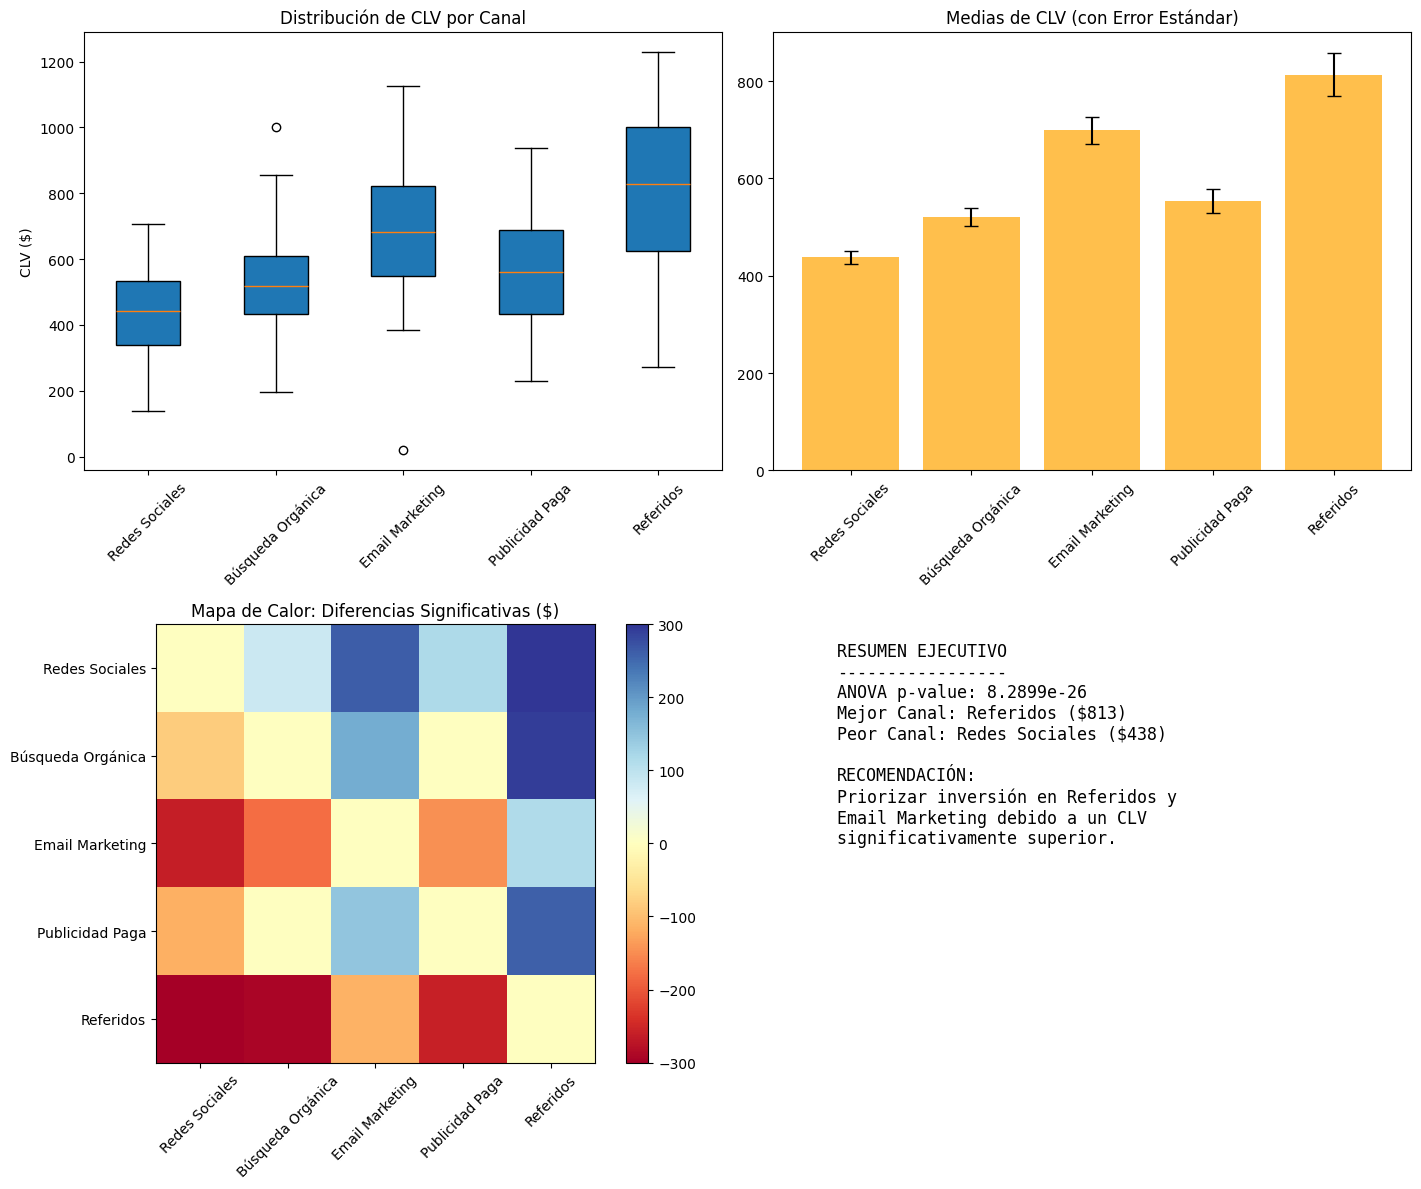

Análisis finalizado.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARACIÓN DE DATOS Y CONFIGURACIÓN
# ==========================================
print("Generando datos simulados...")
np.random.seed(42)
n_clientes = 300

# Definir canales y sus pesos
canales = ['Redes Sociales', 'Búsqueda Orgánica', 'Email Marketing', 'Publicidad Paga', 'Referidos']
pesos_canales = [0.3, 0.25, 0.2, 0.15, 0.1]

# Asignar canales
canal_asignado = np.random.choice(canales, n_clientes, p=pesos_canales)

# Definir distribuciones de CLV (Valor de Vida) por canal
# Referidos y Email tienen medias más altas intencionalmente
clv_por_canal = {
    'Redes Sociales': 450,
    'Búsqueda Orgánica': 520,
    'Email Marketing': 680,
    'Publicidad Paga': 590,
    'Referidos': 750
}

# Generar datos con variabilidad
clv_data = []
for canal in canal_asignado:
    media = clv_por_canal[canal]
    # Variabilidad del 30% sobre la media
    valor = np.random.normal(media, media * 0.3)
    clv_data.append(max(0, valor))

# Crear DataFrame
df = pd.DataFrame({
    'cliente_id': range(1, n_clientes + 1),
    'canal_adquisicion': canal_asignado,
    'clv': clv_data
})

print(f"Datos creados: {len(df)} clientes en {len(canales)} canales.")
print("-" * 50)

# ==========================================
# 2. VERIFICACIÓN DE ASUNCIONES
# ==========================================
print("\n[PASO 2] VERIFICACIÓN DE ASUNCIONES")

# Agrupar datos
grupos_clv = {canal: df[df['canal_adquisicion'] == canal]['clv'].values for canal in canales}

# a) Normalidad (Shapiro-Wilk)
print("-> Normalidad (Shapiro-Wilk):")
for canal, datos in grupos_clv.items():
    stat, p = stats.shapiro(datos)
    print(f"   {canal}: p={p:.3f} {'(Normal)' if p > 0.05 else '(No normal)'}")

# b) Homocedasticidad (Levene)
stat, p_levene = stats.levene(*grupos_clv.values())
print(f"-> Homocedasticidad (Levene): p={p_levene:.3f} {'(Varianzas iguales)' if p_levene > 0.05 else '(Varianzas distintas)'}")

# ==========================================
# 3. EJECUCIÓN DEL ANOVA DE UNA VÍA
# ==========================================
print("\n[PASO 3] RESULTADOS ANOVA")
f_stat, p_value = stats.f_oneway(*grupos_clv.values())

print(f"Estadístico F: {f_stat:.3f}")
print(f"Valor p: {p_value:.4e}")  # Notación científica para p muy pequeños

if p_value < 0.05:
    print("CONCLUSIÓN: RECHAZAMOS H0. Existen diferencias significativas entre canales.")
else:
    print("CONCLUSIÓN: NO rechazamos H0. No hay diferencias significativas.")

# Tamaño del efecto (Eta Cuadrado)
ss_total = sum((df['clv'] - df['clv'].mean())**2)
ss_between = sum(len(g) * (g.mean() - df['clv'].mean())**2 for g in grupos_clv.values())
eta_sq = ss_between / ss_total
print(f"Tamaño del efecto (η²): {eta_sq:.3f}")

# ==========================================
# 4. PRUEBAS POST-HOC (TUKEY HSD)
# ==========================================
print("\n[PASO 4] PRUEBAS POST-HOC (TUKEY)")
tukey = pairwise_tukeyhsd(endog=df['clv'], groups=df['canal_adquisicion'], alpha=0.05)

# Convertir resultados a DataFrame para filtrar fácil
df_tukey = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
significativas = df_tukey[df_tukey['reject'] == True]

print(f"Pares con diferencias significativas ({len(significativas)} encontrados):")
if not significativas.empty:
    print(significativas[['group1', 'group2', 'meandiff', 'p-adj']].to_string(index=False))

# ==========================================
# 5. VISUALIZACIÓN
# ==========================================
print("\n[PASO 5] GENERANDO GRÁFICOS...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
((ax1, ax2), (ax3, ax4)) = axes

# A) Boxplot
ax1.boxplot([grupos_clv[c] for c in canales], labels=canales, patch_artist=True)
ax1.set_title('Distribución de CLV por Canal')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('CLV ($)')

# B) Barplot de Medias + Error Estándar
medias = [np.mean(g) for g in grupos_clv.values()]
errores = [stats.sem(g) for g in grupos_clv.values()]
ax2.bar(canales, medias, yerr=errores, capsize=5, color='orange', alpha=0.7)
ax2.set_title('Medias de CLV (con Error Estándar)')
ax2.tick_params(axis='x', rotation=45)

# C) Heatmap de Diferencias (Tukey)
# Construir matriz de diferencias
matriz_diff = np.zeros((len(canales), len(canales)))
for idx, row in df_tukey.iterrows():
    if row['reject']:
        try:
            i = canales.index(row['group1'])
            j = canales.index(row['group2'])
            matriz_diff[i, j] = row['meandiff']
            matriz_diff[j, i] = -row['meandiff'] # Simetría
        except: pass

im = ax3.imshow(matriz_diff, cmap='RdYlBu', vmin=-300, vmax=300)
ax3.set_xticks(range(len(canales)))
ax3.set_yticks(range(len(canales)))
ax3.set_xticklabels(canales, rotation=45)
ax3.set_yticklabels(canales)
ax3.set_title('Mapa de Calor: Diferencias Significativas ($)')
plt.colorbar(im, ax=ax3)

# D) Resumen Textual
ax4.axis('off')
texto_resumen = (
    f"RESUMEN EJECUTIVO\n"
    f"-----------------\n"
    f"ANOVA p-value: {p_value:.4e}\n"
    f"Mejor Canal: {canales[np.argmax(medias)]} (${max(medias):.0f})\n"
    f"Peor Canal: {canales[np.argmin(medias)]} (${min(medias):.0f})\n\n"
    f"RECOMENDACIÓN:\n"
    f"Priorizar inversión en Referidos y\n"
    f"Email Marketing debido a un CLV\n"
    f"significativamente superior."
)
ax4.text(0.1, 0.5, texto_resumen, fontsize=12, family='monospace')

plt.tight_layout()
plt.show()
print("Análisis finalizado.")

### Regresión Lineal Simple para Modelado Predictivo

** Fundamentos Matemáticos de la Regresión Lineal**

- Regresión Lineal

La regresión lineal modela la relación entre una variable dependiente (Y) y variables independientes (X) asumiendo una relación lineal.

Ecuación básica: Y = β₀ + β₁X + ε

Donde:

    Y: Variable dependiente (lo que queremos predecir)
    X: Variable independiente (predictor)
    β₀: Intercepto (valor de Y cuando X = 0)
    β₁: Pendiente (cambio en Y por unidad de X)
    ε: Error residual (variabilidad no explicada)

- Método de Mínimos Cuadrados Ordinarios (OLS)

OLS encuentra los coeficientes que minimizan la suma de errores cuadráticos:

Fórmula de β₁: β₁ = Σ((xᵢ - x̄)(yᵢ - ȳ)) / Σ((xᵢ - x̄)²) Fórmula de β₀: β₀ = ȳ - β₁x̄

Ventajas de OLS:

    Propiedad BLUE: Mejor estimador lineal insesgado
    Mínima varianza: Entre todos los estimadores lineales insesgados
    Fácil de interpretar: Coeficientes tienen significado intuitivo


**Estimación e Interpretación de Coeficientes**

Los coeficientes de regresión deben interpretarse en contexto, considerando unidades y significancia estadística.

- Interpretación del Intercepto (β₀)
    - Significado: Valor esperado de Y cuando X = 0. Consideraciones:
    - Significativo solo si X=0 es plausible: No interpretar intercepto si X=0 está fuera del rango de datos
    - Escalado: Afectado por unidades de medición
    - Contexto: Puede no tener significado práctico

- Interpretación de la Pendiente (β₁)
    - Significado: Cambio esperado en Y por cada unidad adicional de X. Ejemplos:

            Ventas = 1000 + 50 × (gasto_publicidad) → Cada $1 extra en publicidad aumenta ventas en $50
            Satisfacción = 3.2 + 0.8 × (calidad_servicio) → Cada punto de calidad aumenta satisfacción en 0.8 puntos

- Consideraciones importantes:

    - Unidades: Interpretación depende de unidades de X e Y
    - Rango de validez: Coeficiente válido solo dentro del rango observado de X
    - Ceteris paribus: Asume otras variables constantes

- Prueba t para coeficientes: H₀: β₁ = 0 (variable no contribuye al modelo)

    ```
    # En statsmodels
    import statsmodels.formula.api as smf

    modelo = smf.ols('ventas ~ gasto_publicidad', data=df).fit()
    print(modelo.summary())

    # Interpretar:
    # coef: valor del coeficiente
    # std err: error estándar
    # t: estadístico t
    # P>|t|: valor p
    # [0.025, 0.975]: intervalo de confianza 95%
    ```



**Evaluación de Bondad de Ajuste**

Métricas cuantitativas evalúan qué tan bien el modelo explica los datos y su capacidad predictiva.

1. Coeficiente de Determinación (R²)

El coeficiente de determinación (R²) mide la proporción de variabilidad en la variable dependiente (Y) que es explicada por el modelo de regresión, con valores que van de 0 (ninguna explicación) a 1 (explicación perfecta).

Fórmula: R² = 1 - (SS_res / SS_tot)

    SS_res: Suma de cuadrados residuales (errores del modelo)
    SS_tot: Suma de cuadrados totales (variabilidad total)

Interpretación:

    R² = 1.0: Modelo perfecto (explica 100% de variabilidad)
    R² = 0.0: Modelo no explica variabilidad (tan bueno como la media)
    R² negativo: Modelo peor que usar la media

Limitaciones:

    Aumenta con más variables: R² nunca disminuye al añadir predictores
    No mide calidad predictiva: Alto R² no garantiza buenas predicciones
    Sensibilidad a outliers: Puntos extremos pueden inflar R² artificialmente

2. Error Cuadrático Medio (RMSE) y Error Absoluto Medio (MAE)

RMSE: √(Σ(yᵢ - ŷᵢ)² / n) - penaliza errores grandes

MAE: Σ|yᵢ - ŷᵢ| / n - más robusto a outliers

Interpretación práctica:

    RMSE en unidades de Y: Error típico del modelo en las mismas unidades que Y
    Comparación con variabilidad: RMSE vs desviación estándar de Y

3. R² Ajustado

Fórmula: R²_ajustado = 1 - [(1 - R²)(n - 1)/(n - p - 1)]

Donde:

    n: número de observaciones
    p: número de predictores

Ventajas:

    Penaliza complejidad: Disminuye al añadir predictores que no mejoran el modelo
    Mejor para comparación: Entre modelos con diferente número de variables


**Validación de Supuestos y Diagnóstico**

Los modelos de regresión lineal tienen supuestos que deben verificarse para garantizar validez de inferencias.

Supuestos Clave:
1. Linealidad: Relación entre X e Y es lineal. Verificación: Gráfico de residuos vs valores ajustados.

2. Independencia: Errores no están correlacionados. Verificación: Gráfico de residuos vs orden, prueba de Durbin-Watson.

3. Homocedasticidad: Varianza de errores es constante. Verificación: Gráfico de residuos vs valores ajustados, prueba de Breusch-Pagan.

4. Normalidad de residuos: Errores siguen distribución normal. Verificación: Q-Q plot, prueba de Shapiro-Wilk.

Diagnóstico Visual


```
import matplotlib.pyplot as plt
import scipy.stats as stats

# Crear gráficos de diagnóstico
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuos vs Valores ajustados (linealidad + homocedasticidad)
ax1.scatter(modelo.fittedvalues, modelo.resid)
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_xlabel('Valores Ajustados')
ax1.set_ylabel('Residuos')
ax1.set_title('Residuos vs Valores Ajustados')

# 2. Q-Q plot (normalidad)
stats.probplot(modelo.resid, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot de Residuos')

# 3. Histograma de residuos (normalidad)
ax3.hist(modelo.resid, bins=20, alpha=0.7)
ax3.set_xlabel('Residuos')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Residuos')

# 4. Residuos vs Orden (independencia)
ax4.scatter(range(len(modelo.resid)), modelo.resid)
ax4.axhline(y=0, color='red', linestyle='--')
ax4.set_xlabel('Orden de Observación')
ax4.set_ylabel('Residuos')
ax4.set_title('Residuos vs Orden')

plt.tight_layout()
plt.show()
```



#### Ejemplo: Modelado predictivo de valor de vida del cliente (CLV) usando regresión lineal

Preparación de datos y análisis exploratorio:

DATASET PARA MODELADO CLV
Clientes analizados: 200
CLV promedio: $1384
Rango CLV: $317 - $8112

CORRELACIONES CON CLV:
ingresos             | +0.940
frecuencia_compras   | +0.252
edad                 | +0.064
antiguedad_meses     | +0.063
satisfaccion         | -0.061

MODELO 1: CLV ~ INGRESOS
R² (Ingresos): 0.8840
RMSE (Ingresos): $258

MODELO 2: CLV ~ MÚLTIPLES PREDICTORES
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -83.0423    110.407     -0.752      0.453    -300.788     134.704
ingresos               0.0202      0.000     44.420      0.000       0.019       0.021
frecuencia_compras    55.6135      8.058      6.901      0.000      39.721      71.506
antiguedad_meses       2.6863      0.670      4.010      0.000       1.365       4.008
satisfaccion          35.1456     13.308      2.641      0.009       8.900      61.391
R² (Múltiple)

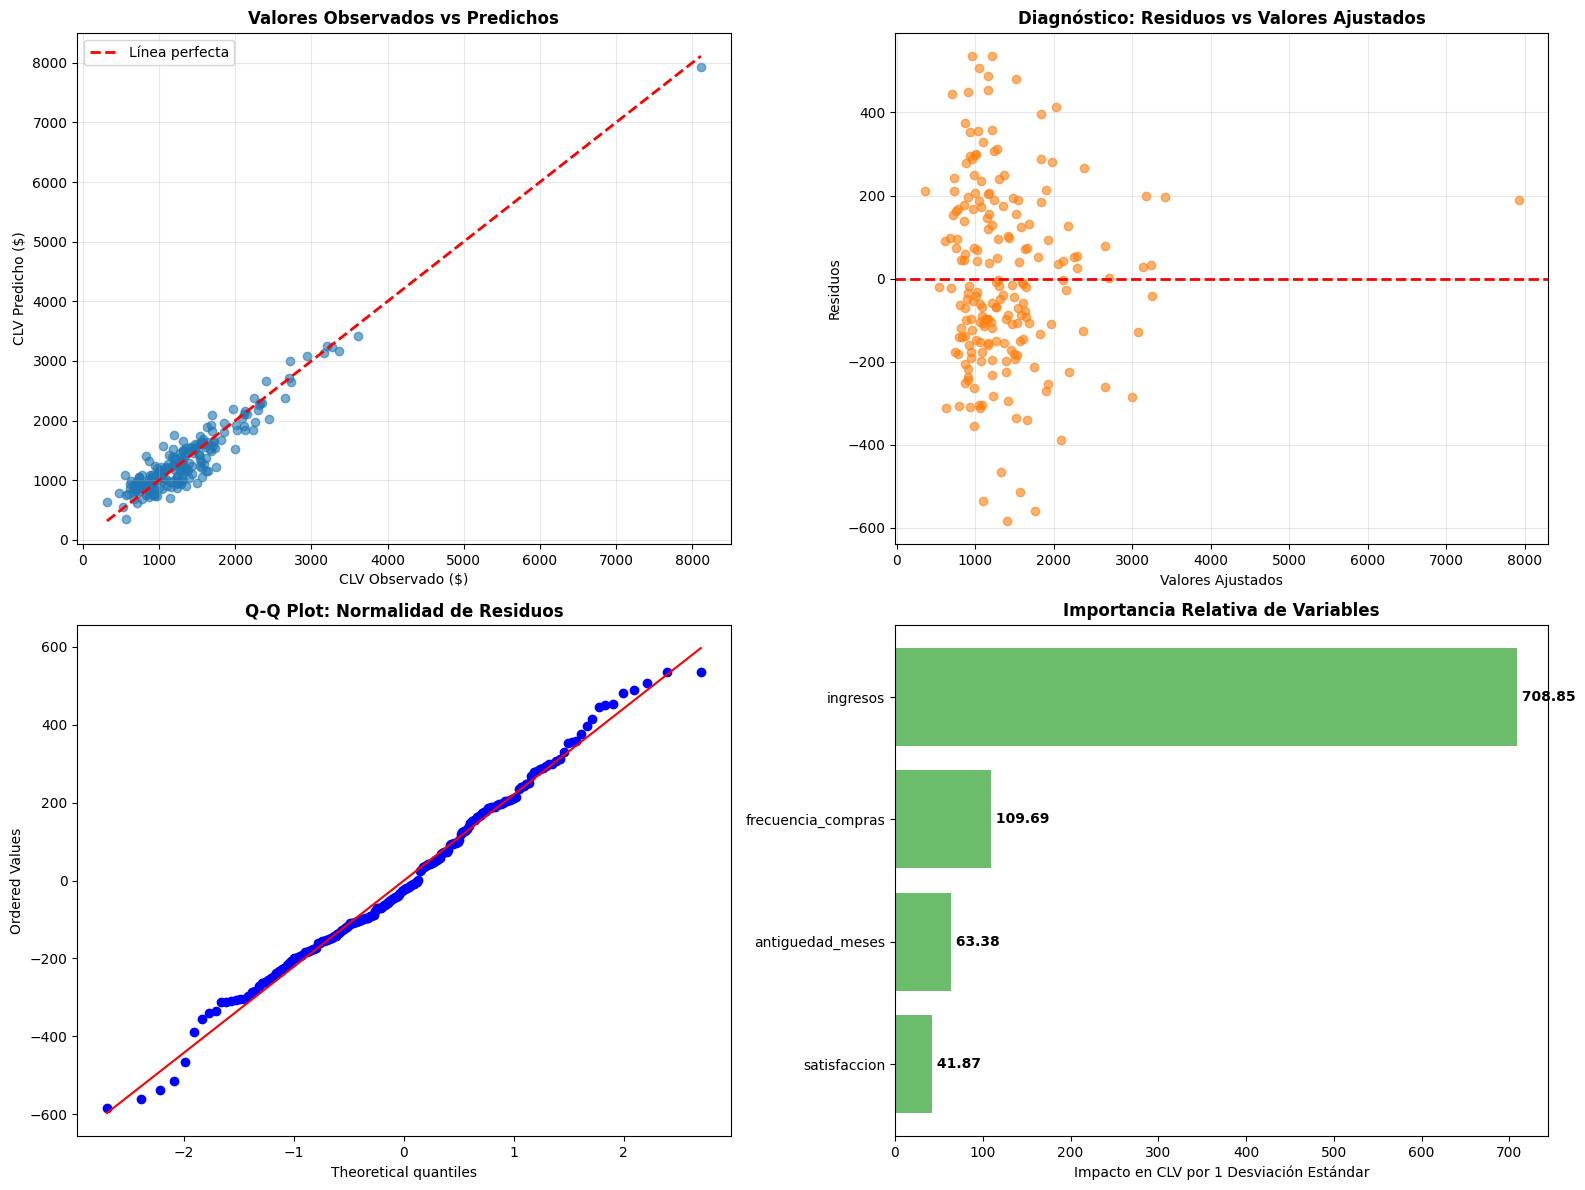


Análisis de modelo generado.

RESUMEN EJECUTIVO - MODELO CLV
R² del modelo: 0.916 (91.6% de variabilidad explicada)
RMSE: $219 (error típico de predicción)
Variables significativas: 4 de 4
Supuestos cumplidos: 3 de 3

Predicción para cliente nuevo: $2374


In [ ]:
    import pandas as pd
    import numpy as np
    import statsmodels.formula.api as smf
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_squared_error, r2_score
    import scipy.stats as stats
    from statsmodels.stats.api import het_breuschpagan
    from statsmodels.stats.stattools import durbin_watson
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    # ==========================================
    # 1. GENERACIÓN DE DATOS
    # ==========================================
    # Generar dataset de clientes para modelado CLV
    np.random.seed(42)
    n_clientes = 200

    df = pd.DataFrame({
        'cliente_id': range(1, n_clientes + 1),
        'edad': np.random.normal(35, 10, n_clientes).clip(18, 70).astype(int),
        'ingresos': np.random.lognormal(10.5, 0.6, n_clientes).round(0),
        'frecuencia_compras': np.random.poisson(4, n_clientes),
        'antiguedad_meses': np.random.exponential(24, n_clientes).astype(int),
        'satisfaccion': np.random.normal(7.5, 1.2, n_clientes).clip(1, 10),
        'canal_adquisicion': np.random.choice(['Online', 'Tienda', 'App'], n_clientes)
    })

    # Generar CLV basado en características (con ruido)
    clv_base = (df['ingresos'] * 0.02 +
                df['frecuencia_compras'] * 50 +
                df['antiguedad_meses'] * 2 +
                df['satisfaccion'] * 30)

    df['clv'] = clv_base + np.random.normal(0, clv_base.std() * 0.3, n_clientes)
    df['clv'] = df['clv'].clip(0)  # CLV no puede ser negativo

    print("DATASET PARA MODELADO CLV")
    print("=" * 30)
    print(f"Clientes analizados: {len(df)}")
    print(f"CLV promedio: ${df['clv'].mean():.0f}")
    print(f"Rango CLV: ${df['clv'].min():.0f} - ${df['clv'].max():.0f}")

    # Análisis de correlaciones
    numeric_cols = ['edad', 'ingresos', 'frecuencia_compras', 'antiguedad_meses', 'satisfaccion', 'clv']
    correlaciones = df[numeric_cols].corr()['clv'].sort_values(ascending=False)

    print("\nCORRELACIONES CON CLV:")
    for var, corr in correlaciones.items():
        if var != 'clv':
            print(f"{var:20} | {corr:+.3f}")

    # ==========================================
    # 2. CONSTRUCCIÓN DEL MODELO DE REGRESIÓN
    # ==========================================
    # Modelo 1: Usando ingresos como predictor principal
    modelo1 = smf.ols('clv ~ ingresos', data=df).fit()

    print("\nMODELO 1: CLV ~ INGRESOS")
    print("=" * 25)
    # print(modelo1.summary().tables[1]) # Opcional: imprimir tabla completa

    # Métricas de evaluación
    y_pred1 = modelo1.predict(df) # Usar df completo es más seguro
    r2_1 = r2_score(df['clv'], y_pred1)
    rmse_1 = np.sqrt(mean_squared_error(df['clv'], y_pred1))

    print(f"R² (Ingresos): {r2_1:.4f}")
    print(f"RMSE (Ingresos): ${rmse_1:.0f}")



    # Modelo 2: Múltiples predictores
    modelo2 = smf.ols('clv ~ ingresos + frecuencia_compras + antiguedad_meses + satisfaccion',
                    data=df).fit()

    print("\nMODELO 2: CLV ~ MÚLTIPLES PREDICTORES")
    print("=" * 40)
    print(modelo2.summary().tables[1])

    # Métricas del modelo múltiple
    y_pred2 = modelo2.predict(df)
    r2_2 = r2_score(df['clv'], y_pred2)
    rmse_2 = np.sqrt(mean_squared_error(df['clv'], y_pred2))

    print(f"R² (Múltiple): {r2_2:.4f}")
    print(f"RMSE (Múltiple): ${rmse_2:.0f}")
    print(f"AIC: {modelo2.aic:.1f}")

    # Comparación de modelos
    mejora_r2 = ((r2_2 - r2_1) / r2_1) * 100
    mejora_rmse = ((rmse_1 - rmse_2) / rmse_1) * 100

    print("\nCOMPARACIÓN DE MODELOS:")
    print(f"Mejora R²: {mejora_r2:.1f}%")
    print(f"Mejora RMSE: {mejora_rmse:.1f}%")

    # ==========================================
    # 3. INTERPRETACIÓN DE COEFICIENTES
    # ==========================================
    # Extraer coeficientes del modelo múltiple
    coeficientes = modelo2.params
    p_values = modelo2.pvalues
    conf_int = modelo2.conf_int()

    print("\nINTERPRETACIÓN DE COEFICIENTES")
    print("=" * 35)

    for var in ['ingresos', 'frecuencia_compras', 'antiguedad_meses', 'satisfaccion']:
        coef = coeficientes[var]
        p_val = p_values[var]
        ci_lower, ci_upper = conf_int.loc[var]

        print(f"{var.upper()}:")
        print(f"   Coeficiente: {coef:.2f}")
        print(f"   IC 95%: ({ci_lower:.2f}, {ci_upper:.2f})")
        print(f"   Significativo: {'Sí' if p_val < 0.05 else 'No'} (p={p_val:.4f})")

        # Interpretación específica
        if var == 'ingresos':
            print(f"   Impacto: Por cada $1000 extra, el CLV sube ${coef*1000:.0f}")
        elif var == 'frecuencia_compras':
            print(f"   Impacto: Cada compra adicional añade ${coef:.0f} al CLV")
        elif var == 'antiguedad_meses':
            print(f"   Impacto: Cada mes de antigüedad añade ${coef:.0f} al CLV")
        elif var == 'satisfaccion':
            print(f"   Impacto: Cada punto de satisfacción añade ${coef:.2f} al CLV")
        print()

    # ==========================================
    # 4. VALIDACIÓN DE SUPUESTOS
    # ==========================================
    # Análisis de residuos
    residuos = modelo2.resid
    valores_ajustados = modelo2.fittedvalues

    print("VALIDACIÓN DE SUPUESTOS")
    print("=" * 25)

    # Prueba de normalidad de residuos
    stat, p_normalidad = stats.shapiro(residuos)
    print(f"Normalidad residuos: {'Sí' if p_normalidad > 0.05 else 'No'} (p={p_normalidad:.4f})")



    # Prueba de homocedasticidad (Breusch-Pagan)
    bp_test = het_breuschpagan(residuos, modelo2.model.exog)
    print(f"Homocedasticidad: {'Sí' if bp_test[1] > 0.05 else 'No'} (p={bp_test[1]:.4f})")

    # Correlación de residuos (Durbin-Watson)
    dw_stat = durbin_watson(residuos)
    print(f"Independencia residuos (DW): {dw_stat:.3f} (ideal: 1.5 - 2.5)")

    # Multicolinealidad (VIF)
    X = df[['ingresos', 'frecuencia_compras', 'antiguedad_meses', 'satisfaccion']]
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print("\nMULTICOLINEALIDAD (VIF):")
    for _, row in vif_data.iterrows():
        problema = "PROBLEMA" if row['VIF'] > 5 else "OK"
        print(f"{row['Variable']:20} | VIF={row['VIF']:.2f} | {problema}")

    # ==========================================
    # 5. VISUALIZACIÓN COMPLETA
    # ==========================================
    # Crear visualización comprehensiva del modelo
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Valores observados vs predichos
    ax1.scatter(df['clv'], y_pred2, alpha=0.6, color='#1f77b4')
    ax1.plot([df['clv'].min(), df['clv'].max()], [df['clv'].min(), df['clv'].max()],
            'r--', linewidth=2, label='Línea perfecta')
    ax1.set_xlabel('CLV Observado ($)')
    ax1.set_ylabel('CLV Predicho ($)')
    ax1.set_title('Valores Observados vs Predichos', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Residuos vs valores ajustados
    ax2.scatter(valores_ajustados, residuos, alpha=0.6, color='#ff7f0e')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax2.set_xlabel('Valores Ajustados')
    ax2.set_ylabel('Residuos')
    ax2.set_title('Diagnóstico: Residuos vs Valores Ajustados', fontweight='bold')
    ax2.grid(True, alpha=0.3)



    # 3. Q-Q plot de residuos
    stats.probplot(residuos, dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot: Normalidad de Residuos', fontweight='bold')

    # 4. Importancia de variables (Coeficientes Estandarizados corregidos)
    # Nota: Coef estandarizado = Coef * (Std_X / Std_Y), o simplemente Coef * Std_X para comparar magnitud relativa en Y
    coef_std = modelo2.params[1:] * df[['ingresos', 'frecuencia_compras', 'antiguedad_meses', 'satisfaccion']].std()
    coef_std = coef_std.abs().sort_values(ascending=True)

    bars = ax4.barh(range(len(coef_std)), coef_std.values, color='#2ca02c', alpha=0.7)
    ax4.set_yticks(range(len(coef_std)))
    ax4.set_yticklabels(coef_std.index)
    ax4.set_xlabel('Impacto en CLV por 1 Desviación Estándar')
    ax4.set_title('Importancia Relativa de Variables', fontweight='bold')

    # Añadir valores en las barras
    for i, (var, val) in enumerate(zip(coef_std.index, coef_std.values)):
        ax4.text(val, i, f' {val:.2f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show() # Cambiado de savefig a show para notebooks interactivos
    print("\nAnálisis de modelo generado.")

    # Resumen ejecutivo
    print("\nRESUMEN EJECUTIVO - MODELO CLV")
    print("=" * 35)
    print(f"R² del modelo: {r2_2:.3f} ({r2_2*100:.1f}% de variabilidad explicada)")
    print(f"RMSE: ${rmse_2:.0f} (error típico de predicción)")
    print(f"Variables significativas: {sum(p_values[1:] < 0.05)} de {len(p_values)-1}")
    print(f"Supuestos cumplidos: {sum([p_normalidad > 0.05, bp_test[1] > 0.05, abs(dw_stat - 2) < 0.5])} de 3")

    # Predicción para nuevo cliente
    cliente_nuevo = pd.DataFrame({
        'ingresos': [80000],
        'frecuencia_compras': [8],
        'antiguedad_meses': [36],
        'satisfaccion': [8.5]
    })

    clv_predicho = modelo2.predict(cliente_nuevo)[0]
    print(f"\nPredicción para cliente nuevo: ${clv_predicho:.0f}")

### Estadística No Paramétrica y Pruebas Robustas

**Pruebas No Paramétricas para Comparación de Grupos**

Las pruebas no paramétricas no requieren supuestos distribucionales estrictos, siendo útiles cuando los datos no son normales o tienen outliers.

1. Prueba U de Mann-Whitney: Comparación de Dos Grupos Independientes

    Es una alternativa no paramétrica a la prueba t: Compara medianas en lugar de medias.

    Hipótesis:

        H₀: Las distribuciones de ambos grupos son idénticas
        H₁: La distribución de un grupo está desplazada respecto al otro

    Ventajas:

    - Robusta a outliers: Usa rangos en lugar de valores absolutos
    - No requiere normalidad: Funciona con cualquier distribución continua
    - Eficiente: Similar poder estadístico que t-test cuando se cumplen supuestos

    ```
    from scipy import stats

    # Datos de dos grupos
    grupo_a = np.random.normal(100, 15, 50)
    grupo_b = np.random.normal(110, 20, 45)  # Media diferente, varianza diferente

    # Prueba Mann-Whitney
    u_stat, p_value = stats.mannwhitneyu(grupo_a, grupo_b, alternative='two-sided')

    print(f"Estadístico U: {u_stat:.1f}")
    print(f"Valor p: {p_value:.4f}")
    print(f"Mediana grupo A: {np.median(grupo_a):.2f}")
    print(f"Mediana grupo B: {np.median(grupo_b):.2f}")
    ```

2. Prueba de Kruskal-Wallis: Comparación de Múltiples Grupos

    Es una alternativa no paramétrica al ANOVA: Extensión de Mann-Whitney para k grupos.

    Lógica: Combina todos los datos, los ordena, y compara cómo se distribuyen los rangos entre grupos.


    ```
    # Tres grupos con distribuciones diferentes
    grupo_1 = np.random.normal(100, 15, 40)
    grupo_2 = np.random.exponential(20, 35) + 80  # Distribución diferente
    grupo_3 = np.random.normal(105, 25, 38)

    # Prueba Kruskal-Wallis
    h_stat, p_value = stats.kruskal(grupo_1, grupo_2, grupo_3)

    print(f"Estadístico H: {h_stat:.3f}")
    print(f"Valor p: {p_value:.4f}")
    print(f"Medianas: G1={np.median(grupo_1):.2f}, G2={np.median(grupo_2):.2f}, G3={np.median(grupo_3):.2f}")
    ```




**Correlaciones No Paramétricas**

Cuando las relaciones no son lineales o los datos no son normales, las correlaciones tradicionales fallan.

1. Correlación de Spearman: Relaciones Monótonas

    - Coeficiente rho de Spearman: Mide relaciones monótonas (crecientes o decrecientes) usando rangos.
    - Fórmula: ρ = 1 - (6 × Σ(dᵢ²)) / (n(n² - 1))

            Donde dᵢ es la diferencia de rangos para cada observación.
    - Captura relaciones no lineales: Mientras sean monótonas
    - Robusta a outliers: Usa rangos, no valores absolutos
    - Funciona con datos ordinales: Ideal para encuestas Likert

    ```
    # Datos con relación no lineal pero monótona
    x = np.random.uniform(0, 10, 100)
    y = np.log(x + 1) + np.random.normal(0, 0.2, 100)  # Relación logarítmica

    # Correlación de Pearson (pobre para relación no lineal)
    pearson_r, _ = stats.pearsonr(x, y)

    # Correlación de Spearman (mejor para relaciones monótonas)
    spearman_rho, _ = stats.spearmanr(x, y)

    print(f"Correlación Pearson: {pearson_r:.3f}")
    print(f"Correlación Spearman: {spearman_rho:.3f}")
    ```

2. Tau de Kendall: Correlación por Concordancia

    **Más conservadora que Spearman**: Cuenta pares concordantes/discordantes.
    
    **Interpretación***: Proporción de pares que siguen la misma dirección menos pares que van en direcciones opuestas.
    
    **Uso**: Datos con muchos empates o cuando se quiere una medida más robusta.

**Bootstrap para Estimación Robusta**

Bootstrap estima la variabilidad de estadísticos remuestreando los datos observados muchas veces.

Principio del Bootstrap:

Idea fundamental: Los datos observados representan la población. Al remuestrear con reemplazo, podemos estimar la distribución muestral del estadístico.

Pasos:

    Tomar muestra bootstrap: n observaciones con reemplazo de los datos originales
    Calcular estadístico: Media, mediana, correlación, etc.
    Repetir B veces: Típicamente B = 1000-10000
    Analizar distribución: Media, desviación estándar, intervalos de confianza

Intervalos de Confianza Bootstrap:

Percentil bootstrap: Usa percentiles de la distribución bootstrap.

```
def bootstrap_confidence_interval(data, statistic_func, n_bootstrap=1000, confidence=0.95):
    """
    Calcula intervalo de confianza bootstrap
    """
    bootstrap_stats = []
    
    for _ in range(n_bootstrap):
        # Muestra bootstrap con reemplazo
        sample = np.random.choice(data, size=len(data), replace=True)
        # Calcula estadístico
        stat = statistic_func(sample)
        bootstrap_stats.append(stat)
    
    # Intervalo de confianza
    alpha = 1 - confidence
    lower = np.percentile(bootstrap_stats, alpha/2 * 100)
    upper = np.percentile(bootstrap_stats, (1 - alpha/2) * 100)
    
    return np.mean(bootstrap_stats), lower, upper

# Ejemplo: IC bootstrap para la mediana
data = np.random.exponential(2, 100)  # Distribución no normal

media_bootstrap, ci_lower, ci_upper = bootstrap_confidence_interval(
    data, np.median, n_bootstrap=1000, confidence=0.95
)

print(f"Mediana observada: {np.median(data):.3f}")
print(f"IC Bootstrap 95%: ({ci_lower:.3f}, {ci_upper:.3f})")
```

Bootstrap para Pruebas de Hipótesis:

Prueba de permutación: Método exacto que no requiere supuestos distribucionales.



```
def permutation_test(group1, group2, n_permutations=1000):
    """
    Prueba de permutación para diferencia de medias
    """
    # Estadístico observado
    observed_diff = np.mean(group1) - np.mean(group2)
    
    # Combinar datos
    combined = np.concatenate([group1, group2])
    n1, n2 = len(group1), len(group2)
    
    # Generar distribución nula
    null_diffs = []
    for _ in range(n_permutations):
        # Permutación aleatoria
        np.random.shuffle(combined)
        perm_group1 = combined[:n1]
        perm_group2 = combined[n1:]
        null_diffs.append(np.mean(perm_group1) - np.mean(perm_group2))
    
    # Valor p
    p_value = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))
    
    return observed_diff, p_value

# Ejemplo con datos no normales
group_a = np.random.exponential(1, 50)
group_b = np.random.exponential(1.3, 45)

diff_observed, p_perm = permutation_test(group_a, group_b, n_permutations=1000)

print(f"Diferencia observada: {diff_observed:.3f}")
print(f"Valor p (permutación): {p_perm:.4f}")
```



#### Ejemplo: Análisis robusto de segmentación de clientes con técnicas no paramétricas

Preparación de dataset con características no normales:

In [ ]:
    import pandas as pd
    import numpy as np
    from scipy import stats
    import matplotlib.pyplot as plt
    from itertools import combinations

    # ==========================================
    # 1. GENERACIÓN DE DATOS (NO NORMALES)
    # ==========================================
    np.random.seed(42)
    n_clientes = 300

    df = pd.DataFrame({
        'cliente_id': range(1, n_clientes + 1),
        'segmento': np.random.choice(['Bronce', 'Plata', 'Oro'], n_clientes, p=[0.5, 0.3, 0.2]),
        'gasto_total': np.random.exponential(200, n_clientes),  # Distribución exponencial (sesgada)
        'frecuencia_visitas': np.random.poisson(3, n_clientes),  # Conteos (Poisson)
        'satisfaccion': np.random.beta(2, 1, n_clientes) * 10,  # Beta (asimetría negativa)
        'antiguedad_dias': np.random.exponential(365, n_clientes).astype(int)
    })

    print("DATASET PARA ANÁLISIS NO PARAMÉTRICO")
    print("=" * 40)
    print(f"Clientes analizados: {len(df)}")
    print("Distribuciones generadas:")
    print("- Gasto total: Exponencial (sesgada derecha)")
    print("- Frecuencia visitas: Poisson (discreta)")
    print("- Satisfacción: Beta (acotada 0-10)")
    print("- Antigüedad: Exponencial")

    # Verificar no normalidad (Shapiro-Wilk)
    print("\nTEST DE NORMALIDAD (Shapiro-Wilk):")
    print("-" * 40)
    for col in ['gasto_total', 'frecuencia_visitas', 'satisfaccion', 'antiguedad_dias']:
        stat, p = stats.shapiro(df[col])
        normal = "SÍ" if p > 0.05 else "NO"
        print(f"{col:20} | Normal: {normal} (p={p:.4f})")

    # ==========================================
    # 2. COMPARACIONES NO PARAMÉTRICAS
    # ==========================================

    # Preparar datos por segmento
    segmentos = {}
    for seg in ['Bronce', 'Plata', 'Oro']:
        segmentos[seg] = df[df['segmento'] == seg]['gasto_total'].values

    print("\nCOMPARACIÓN DE GASTO TOTAL ENTRE SEGMENTOS")
    print("=" * 50)

    # Estadísticas descriptivas robustas (Mediana y Rango Intercuartil)
    print(f"{'Segmento':10} | {'Mediana':>10} | {'IQR':>10} | {'n':>5}")
    print("-" * 45)
    for seg, datos in segmentos.items():
        mediana = np.median(datos)
        q25, q75 = np.percentile(datos, [25, 75])
        iqr = q75 - q25
        print(f"{seg:10} | ${mediana:9.0f} | ${iqr:9.0f} | {len(datos):5}")

    # Prueba Kruskal-Wallis (ANOVA no paramétrico)
    # H0: Las medianas de todos los grupos son iguales
    h_stat, p_kw = stats.kruskal(*segmentos.values())

    print("\nPRUEBA KRUSKAL-WALLIS (Global):")
    print("-" * 30)
    print(f"Estadístico H: {h_stat:.3f}")
    print(f"Valor p: {p_kw:.4f}")
    print(f"¿Existen diferencias significativas?: {'SÍ' if p_kw < 0.05 else 'NO'}")

    # Comparaciones pareadas con Mann-Whitney U (Post-hoc)
    if p_kw < 0.05:
        print("\nCOMPARACIONES PAREADAS (Mann-Whitney U):")
        print("Nota: Se aplica corrección de Bonferroni (alpha = 0.05 / 3 = 0.017)")
        print("-" * 60)

        segmento_nombres = list(segmentos.keys())
        alpha_corregido = 0.05 / 3  # Corrección para 3 comparaciones

        for seg1, seg2 in combinations(segmento_nombres, 2):
            u_stat, p_mw = stats.mannwhitneyu(segmentos[seg1], segmentos[seg2], alternative='two-sided')
            significativo = "SÍ" if p_mw < alpha_corregido else "NO"

            print(f"{seg1:6} vs {seg2:6}: U={u_stat:8.1f}, p={p_mw:.4f} -> Significativo: {significativo}")
    else:
        print("\nNo se realizan pruebas post-hoc porque Kruskal-Wallis no fue significativo.")

DATASET PARA ANÁLISIS NO PARAMÉTRICO
Clientes analizados: 300
Distribuciones generadas:
- Gasto total: Exponencial (sesgada derecha)
- Frecuencia visitas: Poisson (discreta)
- Satisfacción: Beta (acotada 0-10)
- Antigüedad: Exponencial

TEST DE NORMALIDAD (Shapiro-Wilk):
----------------------------------------
gasto_total          | Normal: NO (p=0.0000)
frecuencia_visitas   | Normal: NO (p=0.0000)
satisfaccion         | Normal: NO (p=0.0000)
antiguedad_dias      | Normal: NO (p=0.0000)

COMPARACIÓN DE GASTO TOTAL ENTRE SEGMENTOS
Segmento   |    Mediana |        IQR |     n
---------------------------------------------
Bronce     | $      160 | $      269 |   144
Plata      | $      159 | $      254 |    93
Oro        | $      119 | $      185 |    63

PRUEBA KRUSKAL-WALLIS (Global):
------------------------------
Estadístico H: 3.896
Valor p: 0.1426
¿Existen diferencias significativas?: NO

No se realizan pruebas post-hoc porque Kruskal-Wallis no fue significativo.


## Week 4 - Bases de Datos Avanzadas

### Diseño Avanzado de Esquemas de Bases de Datos

**Normalización vs Desnormalización: Trade-offs para Análisis**

La normalización y desnormalización representan filosofías opuestas en diseño de bases de datos, cada una optimizada para diferentes cargas de trabajo. Para análisis de datos, la elección apropiada puede significar la diferencia entre consultas que tardan segundos y las que tardan horas.

1. Normalización: Integridad Primero

    La normalizacion busca eliminar redundancia, asegurar consistencia yfacilitar mantenimiento.

    - 1NF: Valores atómicos, sin repetición de grupos
    - 2NF: Dependencias funcionales completas
    - 3NF: Dependencias transitivas eliminadas
    - BCNF: Dependencias más restrictivas

    Ventajas para análisis:

    - Integridad referencial: Datos consistentes y confiables
    - Flexibilidad: Fácil añadir nuevos tipos de entidades
    - Mantenimiento: Cambios localizados, sin propagación

    Desventajas para análisis:

    - Joins complejos: Consultas requieren múltiples joins
    - Performance pobre: Especialmente con agregaciones complejas
    - Complejidad: Consultas analíticas difíciles de escribir y optimizar

2. Desnormalización: Performance Primero

    El objetivo de la desnormalización es optimizar para consultas analíticas, minimizar joins y maximizar velocidad de lectura. Esto lo logra mediante:

    - Tablas resumen: Precalcular agregaciones comunes
    - Columnas derivadas: Almacenar cálculos frecuentes
    - Tablas anchas: Consolidar información relacionada

    Ventajas para análisis:

    - Consultas simples: Menos joins, más rápidas
    - Performance predecible: Optimizado para patrones conocidos
    - Simplicidad: Consultas más legibles y mantenibles

    Desventajas para análisis:

    - Redundancia: Almacenamiento duplicado
    - Inconsistencia: Riesgo de datos contradictorios
    - Complejidad de actualización: Cambios requieren sincronización múltiple

3. Estrategia Híbrida: Lo Mejor de Ambos Mundos

    **Normalización** para transaccional: Sistema OLTP normalizado para operaciones diarias.

    **Desnormalización** para analítico: Data warehouse desnormalizado para reporting y análisis.

    **Ejemplo:**

    ```
    -- Ejemplo: Sistema híbrido
    -- OLTP: Normalizado para transacciones
    CREATE TABLE pedidos (
        id SERIAL PRIMARY KEY,
        cliente_id INTEGER REFERENCES clientes(id),
        fecha_pedido DATE,
        estado VARCHAR(20)
    );

    -- OLAP: Desnormalizado para análisis
    CREATE TABLE hechos_ventas (
        id_venta INTEGER,
        fecha DATE,
        cliente_nombre VARCHAR(100),
        cliente_segmento VARCHAR(20),
        producto_categoria VARCHAR(50),
        cantidad INTEGER,
        precio_unitario DECIMAL,
        total_venta DECIMAL,
        -- Columnas derivadas para análisis rápido
        mes INTEGER,
        trimestre INTEGER,
        año INTEGER,
        margen_beneficio DECIMAL
    );
    ```



**Modelado Dimensional: Star Schema y Snowflake Schema**

Los esquemas dimensionales están específicamente diseñados para análisis, sacrificando normalización por performance en consultas complejas.

1. Star Schema: Simplicidad y Performance

    Tiene una estructura de una tabla de hechos central rodeada de tablas de dimensiones.

    Características:

    - Tabla de hechos: Métricas numéricas, claves foráneas a dimensiones
    - Tablas de dimensión: Atributos descriptivos, jerarquías naturales
    - Relaciones: Una dimensión conecta a hechos con una relación many-to-one

    Ventajas:

    - Consultas intuitivas: "Ventas por producto, cliente y tiempo"
    - Performance: Menos joins que esquemas normalizados
    - Agregaciones eficientes: Optimizado para GROUP BY complejos

    Ejemplo práctico:

    ```
    -- Star Schema para análisis de ventas
    CREATE TABLE hechos_ventas (
        id_venta SERIAL PRIMARY KEY,
        id_tiempo INTEGER REFERENCES dim_tiempo(id),
        id_cliente INTEGER REFERENCES dim_cliente(id),
        id_producto INTEGER REFERENCES dim_producto(id),
        id_tienda INTEGER REFERENCES dim_tienda(id),
        cantidad INTEGER,
        precio_unitario DECIMAL,
        descuento DECIMAL,
        total_venta DECIMAL
    );

    CREATE TABLE dim_tiempo (
        id SERIAL PRIMARY KEY,
        fecha DATE,
        dia INTEGER,
        mes INTEGER,
        trimestre INTEGER,
        año INTEGER,
        dia_semana VARCHAR(10),
        festivo BOOLEAN
    );

    CREATE TABLE dim_cliente (
        id SERIAL PRIMARY KEY,
        nombre VARCHAR(100),
        segmento VARCHAR(20),
        region VARCHAR(50),
        edad INTEGER,
        genero VARCHAR(10)
    );
    ```
2. Snowflake Schema: Mayor Normalización

    Tiene una estructura dimensiones parcialmente normalizadas y formando estructura de "copo de nieve".

    Características:

    - Dimensiones jerárquicas: Subdimensiones conectadas
    - Mayor normalización: Reduce redundancia en dimensiones grandes
    - Flexibilidad: Más fácil mantener jerarquías complejas

    Trade-offs:

    - Ventaja: Menos redundancia, más fácil mantenimiento
    - Desventaja: Más joins, consultas más complejas

    Ejemplo:

    ```
    -- Snowflake Schema
    CREATE TABLE dim_geografia (
        id SERIAL PRIMARY KEY,
        ciudad VARCHAR(50),
        id_region INTEGER REFERENCES dim_region(id)
    );

    CREATE TABLE dim_region (
        id SERIAL PRIMARY KEY,
        nombre_region VARCHAR(50),
        id_pais INTEGER REFERENCES dim_pais(id)
    );

    -- Comparado con Star Schema donde todo está en una tabla
    CREATE TABLE dim_cliente_star (
        id SERIAL PRIMARY KEY,
        nombre VARCHAR(100),
        ciudad VARCHAR(50),
        region VARCHAR(50),
        pais VARCHAR(50),
        segmento VARCHAR(20)
    );
    ```





**Diseño de Esquemas para Consultas Analíticas Complejas**

El diseño del esquema debe anticipar los patrones de consulta más comunes y críticos para el negocio.

- Identificación de Requisitos Analíticos:

    Preguntas clave:

    - ¿Qué métricas se analizan frecuentemente?
    - ¿Qué dimensiones se usan para segmentar?
    - ¿Qué jerarquías son importantes (tiempo, geografía, producto)?
    - ¿Qué nivel de granularidad se necesita?

    Patrones comunes:

    - Análisis temporal: Tendencias, comparaciones período sobre período
    - Segmentación geográfica: Por región, ciudad, tienda
    - Análisis de producto: Categorías, subcategorías, marcas
    - Segmentación de cliente: Demografía, comportamiento, valor

- Estrategias de Diseño Específicas
    - Granularidad apropiada: Nivel de detalle que balancea utilidad y performance.

    - Columnas calculadas: Precalcular métricas derivadas comunes.

    
    ```
    -- Columnas derivadas en tabla de hechos
    CREATE TABLE hechos_ventas (
        -- Claves dimensionales
        id_tiempo INTEGER,
        id_cliente INTEGER,
        id_producto INTEGER,
        
        -- Métricas base
        cantidad INTEGER,
        precio_unitario DECIMAL,
        
        -- Métricas derivadas (calculadas en ETL)
        total_bruto DECIMAL GENERATED ALWAYS AS (cantidad * precio_unitario),
        descuento_aplicado DECIMAL,
        total_neto DECIMAL GENERATED ALWAYS AS ((cantidad * precio_unitario) - descuento_aplicado),
        margen_beneficio DECIMAL GENERATED ALWAYS AS (total_neto * 0.25)  -- 25% margen
    );
    ```



#### Ejemplo:  Diseño de esquema dimensional completo para análisis de e-commerce

Análisis de requisitos y diseño conceptual:


```
-- Diseño de Star Schema para plataforma de e-commerce
-- Requisitos identificados:
-- - Análisis de ventas por producto, cliente, tiempo y ubicación
-- - Segmentación por categorías y comportamiento de compra
-- - Métricas: ventas, conversiones, retención, valor de vida del cliente

-- 1. Tabla de Hechos: Ventas transaccionales
CREATE TABLE hechos_ventas (
    id_venta INTEGER PRIMARY KEY,
    id_tiempo INTEGER REFERENCES dim_tiempo(id),
    id_cliente INTEGER REFERENCES dim_cliente(id),
    id_producto INTEGER REFERENCES dim_producto(id),
    id_canal INTEGER REFERENCES dim_canal_adquisicion(id),
    id_geografia INTEGER REFERENCES dim_geografia(id),
    
    -- Métricas transaccionales
    cantidad INTEGER,
    precio_unitario DECIMAL(10,2),
    descuento_aplicado DECIMAL(10,2),
    costo_envio DECIMAL(10,2),
    impuestos DECIMAL(10,2),
    
    -- Métricas calculadas (desnormalizadas para performance)
    total_bruto DECIMAL(10,2) GENERATED ALWAYS AS (cantidad * precio_unitario),
    total_neto DECIMAL(10,2) GENERATED ALWAYS AS ((cantidad * precio_unitario) - descuento_aplicado + costo_envio + impuestos),
    margen_contribucion DECIMAL(10,2) GENERATED ALWAYS AS ((cantidad * precio_unitario) - descuento_aplicado - costo_envio) * 0.3,
    
    -- Flags para segmentación rápida
    primera_compra BOOLEAN,
    compra_recurrente BOOLEAN,
    cliente_vip BOOLEAN
);

-- 2. Dimensión Tiempo: Jerarquía temporal completa
CREATE TABLE dim_tiempo (
    id INTEGER PRIMARY KEY,
    fecha DATE UNIQUE,
    dia INTEGER,
    mes INTEGER,
    nombre_mes VARCHAR(20),
    trimestre INTEGER,
    año INTEGER,
    dia_semana VARCHAR(10),
    numero_semana INTEGER,
    festivo BOOLEAN,
    temporada VARCHAR(20),  -- Primavera, Verano, etc.
    fin_semana BOOLEAN,
    dia_habil BOOLEAN
);

-- 3. Dimensión Cliente: Segmentación completa
CREATE TABLE dim_cliente (
    id INTEGER PRIMARY KEY,
    id_cliente_natural INTEGER,  -- Para SCD Tipo 2
    nombre VARCHAR(100),
    email VARCHAR(100),
    fecha_registro DATE,
    segmento_valor VARCHAR(20),  -- Bronce, Plata, Oro, Platino
    segmento_comportamiento VARCHAR(30),  -- Nuevo, Recurrente, VIP, Inactivo
    edad INTEGER,
    genero VARCHAR(10),
    ciudad VARCHAR(50),
    region VARCHAR(50),
    pais VARCHAR(50),
    frecuencia_compras_mensual DECIMAL(4,1),
    valor_promedio_compra DECIMAL(10,2),
    ultima_compra DATE,
    activo BOOLEAN
);

-- 4. Dimensión Producto: Jerarquía de catálogo
CREATE TABLE dim_producto (
    id INTEGER PRIMARY KEY,
    sku VARCHAR(20) UNIQUE,
    nombre VARCHAR(100),
    descripcion TEXT,
    id_categoria INTEGER REFERENCES dim_categoria(id),
    id_marca INTEGER REFERENCES dim_marca(id),
    precio_lista DECIMAL(10,2),
    costo DECIMAL(10,2),
    margen DECIMAL(5,2),
    stock_actual INTEGER,
    stock_minimo INTEGER,
    disponible BOOLEAN,
    fecha_lanzamiento DATE,
    temporada VARCHAR(20)
);

-- 5. Dimensión Geografía: Ubicación jerárquica
CREATE TABLE dim_geografia (
    id INTEGER PRIMARY KEY,
    codigo_postal VARCHAR(10),
    ciudad VARCHAR(50),
    provincia VARCHAR(50),
    region VARCHAR(50),
    pais VARCHAR(50),
    zona_horaria VARCHAR(10),
    densidad_poblacional VARCHAR(20)
);

-- 6. Dimensión Canal: Marketing y adquisición
CREATE TABLE dim_canal_adquisicion (
    id INTEGER PRIMARY KEY,
    nombre_canal VARCHAR(50),
    tipo_canal VARCHAR(20),  -- Pago, Orgánico, Social, Email, etc.
    costo_adquisicion DECIMAL(8,2),
    roi_promedio DECIMAL(5,2),
    tasa_conversion DECIMAL(5,2),
    activo BOOLEAN
);

-- 7. Tablas de soporte para jerarquías
CREATE TABLE dim_categoria (
    id INTEGER PRIMARY KEY,
    nombre VARCHAR(50),
    categoria_padre INTEGER REFERENCES dim_categoria(id),  -- Para jerarquía
    nivel INTEGER,  -- 1=Principal, 2=Subcategoria, etc.
    descripcion TEXT
);

CREATE TABLE dim_marca (
    id INTEGER PRIMARY KEY,
    nombre VARCHAR(50),
    pais_origen VARCHAR(50),
    segmento VARCHAR(20),  -- Premium, Medio, Económico
    reputacion DECIMAL(3,1)  -- Puntuación 1-10
);
```



Comparación de consultas: Normalizado vs Dimensional:


```
-- Consulta en esquema NORMALIZADO (complejo, lento)
SELECT
    c.nombre_cliente,
    p.nombre_producto,
    cat.nombre_categoria,
    SUM(v.cantidad * v.precio_unitario) as total_ventas,
    AVG(v.cantidad * v.precio_unitario) as ticket_promedio
FROM ventas v
JOIN clientes c ON v.id_cliente = c.id
JOIN productos p ON v.id_producto = p.id
JOIN categorias cat ON p.id_categoria = cat.id
WHERE v.fecha_venta BETWEEN '2024-01-01' AND '2024-12-31'
GROUP BY c.nombre_cliente, p.nombre_producto, cat.nombre_categoria
ORDER BY total_ventas DESC;

-- Consulta en esquema DIMENSIONAL (simple, rápido)
SELECT
    dc.nombre as cliente,
    dp.nombre as producto,
    dcat.nombre as categoria,
    SUM(hv.total_neto) as total_ventas,
    AVG(hv.total_neto) as ticket_promedio
FROM hechos_ventas hv
JOIN dim_tiempo dt ON hv.id_tiempo = dt.id
JOIN dim_cliente dc ON hv.id_cliente = dc.id
JOIN dim_producto dp ON hv.id_producto = dp.id
JOIN dim_categoria dcat ON dp.id_categoria = dcat.id
WHERE dt.año = 2024
GROUP BY dc.nombre, dp.nombre, dcat.nombre
ORDER BY total_ventas DESC;

```



Análisis de trade-offs y recomendaciones:


```
-- Ventajas del diseño dimensional:
-- 1. Consultas más simples y legibles
-- 2. Performance superior para agregaciones
-- 3. Optimizado para herramientas BI
-- 4. Fácil de entender para analistas de negocio

-- Desventajas:
-- 1. Mayor redundancia de datos
-- 2. Más complejo mantenimiento de dimensiones
-- 3. Menos flexible para cambios estructurales

-- Recomendaciones de implementación:

-- 1. Indices estratégicos para performance
CREATE INDEX idx_hechos_tiempo ON hechos_ventas(id_tiempo);
CREATE INDEX idx_hechos_cliente ON hechos_ventas(id_cliente);
CREATE INDEX idx_hechos_producto ON hechos_ventas(id_producto);
CREATE INDEX idx_dimensiones_compuestas ON hechos_ventas(id_tiempo, id_cliente, id_producto);

-- 2. Particionamiento por tiempo para datasets grandes
CREATE TABLE hechos_ventas_y2024 PARTITION OF hechos_ventas
    FOR VALUES FROM ('2024-01-01') TO ('2025-01-01');

-- 3. Vistas materializadas para consultas frecuentes
CREATE MATERIALIZED VIEW mv_ventas_mensuales AS
SELECT
    dt.año,
    dt.mes,
    SUM(hv.total_neto) as ventas_total,
    COUNT(DISTINCT hv.id_cliente) as clientes_unicos,
    AVG(hv.total_neto) as ticket_promedio
FROM hechos_ventas hv
JOIN dim_tiempo dt ON hv.id_tiempo = dt.id
GROUP BY dt.año, dt.mes;

-- 4. Constraints para integridad
ALTER TABLE hechos_ventas ADD CONSTRAINT ck_total_neto_positivo
    CHECK (total_neto > 0);
ALTER TABLE dim_cliente ADD CONSTRAINT ck_segmento_valido
    CHECK (segmento_valor IN ('Bronce', 'Plata', 'Oro', 'Platino'));
```



### Índices y Estrategias de Optimización de Consultas

**Tipos de Índices y su Aplicación Estratégica**

Los índices son estructuras de datos que aceleran consultas, pero elegir el índice correcto requiere entender los patrones de consulta específicos del análisis.

1. Índices B-Tree: El Trabajo Pesado

    Son estructuras de datos utilizadas en bases de datos que organizan la información en un árbol balanceado que mantiene datos ordenados para búsquedas eficientes.

    Casos de uso ideales:

    - Búsquedas por rango: `WHERE fecha BETWEEN '2024-01-01' AND '2024-12-31'`
    - Ordenamiento: `ORDER BY fecha_venta DESC`
    - Joins: Columnas usadas en `ON clauses`
    - Filtros selectivos: `WHERE status = 'completed'`

    ```
    -- Índices B-Tree para consultas analíticas comunes
    CREATE INDEX idx_ventas_fecha ON hechos_ventas(fecha_venta);
    CREATE INDEX idx_ventas_cliente_fecha ON hechos_ventas(id_cliente, fecha_venta);
    CREATE INDEX idx_ventas_producto_categoria ON dim_producto(id_categoria, precio);

    -- Ejemplo de uso efectivo
    EXPLAIN ANALYZE
    SELECT SUM(total_venta), AVG(total_venta)
    FROM hechos_ventas
    WHERE fecha_venta BETWEEN '2024-01-01' AND '2024-12-31'
    AND id_cliente = 12345;
    ```
2. Índices Bitmap: Eficiencia en Datos Categóricos

    Técnica de indexación de bases de datos que utiliza vectores de bits para representar la presencia o ausencia de valores en una columna. Es ideal para columnas con baja cardinalidad (que tiene pocos valores distintos).

    Casos de uso ideales:
    - Columnas categóricas: Status, categorías, tipos
    - Múltiples condiciones `AND/OR: WHERE region IN ('Madrid', 'Barcelona') AND segmento = 'VIP'`
    - Data warehousing: Filtros complejos en dimensiones

    ```
    -- Índices bitmap para dimensiones categóricas
    CREATE BITMAP INDEX idx_cliente_segmento ON dim_cliente(segmento);
    CREATE BITMAP INDEX idx_cliente_region ON dim_cliente(region);
    CREATE BITMAP INDEX idx_venta_status ON hechos_ventas(status_venta);

    -- Ejemplo: Consulta con múltiples filtros categóricos
    EXPLAIN ANALYZE
    SELECT COUNT(*), SUM(total_venta)
    FROM hechos_ventas hv
    JOIN dim_cliente dc ON hv.id_cliente = dc.id
    WHERE dc.segmento = 'VIP'
    AND dc.region IN ('Madrid', 'Barcelona', 'Valencia')
    AND hv.status_venta = 'completed';
    ```

3. Índices Compuestos: Optimización de Consultas Multicolumna

    Son estructuras de indexacioón en bases de datos que incluyen múltiples columnas, diseñadas para optimizar consultas que filtran u ordenan por multiples campos al mismo tiempo.

    Orden importa: La primera columna debe ser la más selectiva o usada sola.


    ```
    -- Índice compuesto para consultas analíticas típicas
    CREATE INDEX idx_ventas_analisis ON hechos_ventas(id_tiempo, id_cliente, id_producto);

    -- Bueno para consultas que filtran por tiempo, luego cliente, luego producto
    EXPLAIN ANALYZE
    SELECT SUM(total_venta), COUNT(*)
    FROM hechos_ventas
    WHERE id_tiempo BETWEEN 20240101 AND 20241231  -- Rango de tiempo
    AND id_cliente = 12345                       -- Cliente específico
    AND id_producto IN (100, 200, 300);          -- Productos específicos

    -- Mal orden para consultas que empiezan por cliente
    -- CREATE INDEX idx_mal_orden ON hechos_ventas(id_cliente, id_tiempo, id_producto);
    ```

4. Índices Especializados: Funcionales y Parciales

    Son tipos de indices que van más alla de los tradicioneales (B-Tree o Bitmap) y se diseñan para optimizar consultas en escenarios especificos.

    Índices funcionales: Aceleran expresiones calculadas.


    ```
    -- Índice en expresión calculada
    CREATE INDEX idx_ventas_mes ON hechos_ventas(EXTRACT(YEAR FROM fecha_venta), EXTRACT(MONTH FROM fecha_venta));

    -- Útil para consultas agrupadas por mes
    SELECT EXTRACT(YEAR FROM fecha_venta) as año,
        EXTRACT(MONTH FROM fecha_venta) as mes,
        SUM(total_venta)
    FROM hechos_ventas
    GROUP BY EXTRACT(YEAR FROM fecha_venta), EXTRACT(MONTH FROM fecha_venta);
    ```

5. Índices parciales: Solo indexan filas que cumplen condición.

    Los índices parciales son un tipo de índice especializado en bases de datos que se construye solo sobre un subconjunto de filas de una tabla, definido por una condición `WHERE`

    ```
    -- Índice solo para ventas grandes (útil para análisis de outliers)
    CREATE INDEX idx_ventas_grandes ON hechos_ventas(total_venta)
    WHERE total_venta > 1000;

    -- Índice solo para clientes activos
    CREATE INDEX idx_clientes_activos ON dim_cliente(email)
    WHERE activo = true AND ultima_compra > '2023-01-01';
    ```




**Estrategias de Particionamiento para Datasets Grandes**

El particionamiento divide tablas grandes en piezas manejables, mejorando performance y mantenibilidad.

1. Particionamiento por Rangos (Range Partitioning)

    Estrategia: Divide datos por rangos de valores continuos.

    Ideal para: Datos temporales, numéricos con rangos naturales.


    ```
    -- Particionamiento por rangos para datos temporales
    CREATE TABLE hechos_ventas (
        id_venta INTEGER,
        fecha_venta DATE,
        -- ... otras columnas
    ) PARTITION BY RANGE (fecha_venta);

    -- Crear particiones mensuales
    CREATE TABLE hechos_ventas_y2024m01 PARTITION OF hechos_ventas
        FOR VALUES FROM ('2024-01-01') TO ('2024-02-01');

    CREATE TABLE hechos_ventas_y2024m02 PARTITION OF hechos_ventas
        FOR VALUES FROM ('2024-02-01') TO ('2024-03-01');

    -- Ventajas: Eliminación automática de particiones antiguas
    ALTER TABLE hechos_ventas DETACH PARTITION hechos_ventas_y2023m12;
    ```
2. Particionamiento por Lista (List Partitioning)

    Estrategia: Divide datos por valores específicos de categorías.

    Ideal para: Columnas categóricas con grupos lógicos.


    ```
    -- Particionamiento por lista para regiones geográficas
    CREATE TABLE hechos_ventas PARTITION BY LIST (region);

    CREATE TABLE ventas_espana PARTITION OF hechos_ventas
        FOR VALUES IN ('Madrid', 'Barcelona', 'Valencia', 'Sevilla');

    CREATE TABLE ventas_latam PARTITION OF hechos_ventas
        FOR VALUES IN ('Mexico', 'Argentina', 'Colombia', 'Chile');

    CREATE TABLE ventas_eeuu PARTITION OF hechos_ventas
        FOR VALUES IN ('California', 'Texas', 'Florida', 'Nueva York');
    ```
3. Particionamiento por Hash (Hash Partitioning)

    Estrategia: Distribuye datos uniformemente usando función hash.

    Ideal para: Distribución uniforme, escalabilidad horizontal.

    ```
    -- Particionamiento hash para distribución uniforme
    CREATE TABLE hechos_ventas PARTITION BY HASH (id_cliente);

    -- Crear particiones hash (PostgreSQL moderno)
    CREATE TABLE ventas_hash_01 PARTITION OF hechos_ventas
        FOR VALUES WITH (MODULUS 4, REMAINDER 0);

    CREATE TABLE ventas_hash_02 PARTITION OF hechos_ventas
        FOR VALUES WITH (MODULUS 4, REMAINDER 1);

    CREATE TABLE ventas_hash_03 PARTITION OF hechos_ventas
        FOR VALUES WITH (MODULUS 4, REMAINDER 2);

    CREATE TABLE ventas_hash_04 PARTITION OF hechos_ventas
        FOR VALUES WITH (MODULUS 4, REMAINDER 3);
    ```

4. Estrategias de Particionamiento Compuesto

    Subparticionamiento: Combinar estrategias para granularidad fina.


    ```
    -- Particionamiento compuesto: Range por tiempo, luego Hash por cliente
    CREATE TABLE hechos_ventas PARTITION BY RANGE (fecha_venta);

    CREATE TABLE ventas_2024 PARTITION OF hechos_ventas
        FOR VALUES FROM ('2024-01-01') TO ('2025-01-01')
        PARTITION BY HASH (id_cliente);

    -- Subparticiones
    CREATE TABLE ventas_2024_q1 PARTITION OF ventas_2024
        FOR VALUES FROM ('2024-01-01') TO ('2024-04-01')
        PARTITION BY HASH (id_cliente);
    ```



**Análisis de Planes de Ejecución y Optimización**

Los planes de ejecución revelan cómo el optimizador procesa consultas, permitiendo identificar cuellos de botella y oportunidades de optimización.

1. Interpretación de EXPLAIN ANALYZE

    Componentes clave del plan:

    - Cost: Estimación de recursos (CPU + I/O)
    - Rows: Número estimado de filas procesadas
    - Width: Ancho promedio de filas en bytes
    - Actual Time: Tiempo real de ejecución

    ```
    -- Ejemplo de análisis de plan de ejecución
    EXPLAIN ANALYZE
    SELECT
        dt.año, dt.mes,
        SUM(hv.total_venta) as ventas_total,
        COUNT(DISTINCT hv.id_cliente) as clientes_unicos
    FROM hechos_ventas hv
    JOIN dim_tiempo dt ON hv.id_tiempo = dt.id
    WHERE dt.año = 2024
    GROUP BY dt.año, dt.mes
    ORDER BY dt.año, dt.mes;

    -- Plan esperado (con índices apropiados):
    -- HashAggregate (cost=1000.00..1000.50 rows=12 width=32)
    --   Group Key: dt.año, dt.mes
    --   -> Sort (cost=999.00..999.50 rows=200 width=16)
    --     Sort Key: dt.año, dt.mes
    --     -> Hash Join (cost=100.00..900.00 rows=10000 width=16)
    --       -> Seq Scan on hechos_ventas hv (cost=0.00..800.00 rows=10000 width=12)
    --       -> Hash (cost=50.00..50.00 rows=365 width=8)
    --         -> Index Scan on dim_tiempo (cost=0.00..50.00 rows=365 width=8)
    ```

2. Problemas Comunes y Soluciones

    1. Sequential Scan cuando debería usar índice:
        ```
        -- Problema: Seq Scan on large_table (cost=10000.00..20000.00 rows=1000000 width=100)
        -- Solución: Crear índice apropiado
        CREATE INDEX idx_table_columna ON large_table(columna_filtrada);
        ```
    2. Nested Loop ineficiente:
        ```
        -- Problema: Nested Loop (cost=100000.00..1000000.00 rows=10000 width=200)
        -- Solución: Estadísticas actualizadas o índices en columnas de join
        ANALYZE large_table;
        CREATE INDEX idx_join_column ON large_table(join_column);
        ```
    3. Hash Join vs Merge Join vs Nested Loop:

        - Hash Join: Bueno para joins grandes sin índices ordenad
        - Merge Join: Ideal cuando ambas tablas están ordenadas
        - Nested Loop: Eficiente solo con datasets pequeños


#### Ejemplo: Optimización completa de consultas analíticas en base de datos dimensional

Configuración de base de datos y carga de datos de ejemplo:



```
-- Crear esquema dimensional optimizado
CREATE TABLE dim_tiempo (
    id SERIAL PRIMARY KEY,
    fecha DATE UNIQUE,
    año INTEGER,
    mes INTEGER,
    trimestre INTEGER,
    dia_semana VARCHAR(10)
);

CREATE TABLE dim_cliente (
    id SERIAL PRIMARY KEY,
    nombre VARCHAR(100),
    segmento VARCHAR(20),
    region VARCHAR(50)
);

CREATE TABLE hechos_ventas (
    id SERIAL PRIMARY KEY,
    id_tiempo INTEGER REFERENCES dim_tiempo(id),
    id_cliente INTEGER REFERENCES dim_cliente(id),
    total_venta DECIMAL(10,2),
    cantidad INTEGER,
    margen DECIMAL(5,2)
);

-- Generar datos de ejemplo (100,000 ventas)
INSERT INTO dim_tiempo (fecha, año, mes, trimestre, dia_semana)
SELECT
    fecha,
    EXTRACT(YEAR FROM fecha),
    EXTRACT(MONTH FROM fecha),
    EXTRACT(QUARTER FROM fecha),
    TO_CHAR(fecha, 'Day')
FROM generate_series('2023-01-01'::date, '2024-12-31'::date, '1 day') as fecha;

-- Insertar datos de ventas (simulado)
-- Nota: En producción usar COPY o INSERT masivo
```



Análisis de consultas sin optimización:



```
-- Consulta analítica típica SIN optimización
EXPLAIN ANALYZE
SELECT
    dt.año,
    dt.trimestre,
    dc.segmento,
    COUNT(*) as num_ventas,
    SUM(hv.total_venta) as ventas_total,
    AVG(hv.margen) as margen_promedio
FROM hechos_ventas hv
JOIN dim_tiempo dt ON hv.id_tiempo = dt.id
JOIN dim_cliente dc ON hv.id_cliente = dc.id
WHERE dt.año = 2024
  AND dc.segmento IN ('VIP', 'Premium')
  AND hv.total_venta > 100
GROUP BY dt.año, dt.trimestre, dc.segmento
ORDER BY dt.año, dt.trimestre, SUM(hv.total_venta) DESC;

-- Resultado típico SIN índices:
-- Execution time: ~5000ms
-- Plan: Sequential Scan on hechos_ventas (cost=10000.00..50000.00 rows=50000)
--       Hash Join, Nested Loop, etc.
```



Implementación de índices estratégicos:



```
-- Crear índices para optimizar la consulta analítica
CREATE INDEX idx_hechos_tiempo ON hechos_ventas(id_tiempo);
CREATE INDEX idx_hechos_cliente ON hechos_ventas(id_cliente);
CREATE INDEX idx_tiempo_año ON dim_tiempo(año);
CREATE INDEX idx_cliente_segmento ON dim_cliente(segmento);
CREATE INDEX idx_hechos_venta_total ON hechos_ventas(total_venta);

-- Índice compuesto para consulta específica
CREATE INDEX idx_hechos_analisis ON hechos_ventas(id_tiempo, id_cliente, total_venta);

-- Verificar que los índices existen
SELECT schemaname, tablename, indexname, indexdef
FROM pg_indexes
WHERE tablename IN ('hechos_ventas', 'dim_tiempo', 'dim_cliente')
ORDER BY tablename, indexname;
```



Análisis de consulta optimizada:



```
-- Re-ejecutar consulta CON optimización
EXPLAIN ANALYZE
SELECT
    dt.año,
    dt.trimestre,
    dc.segmento,
    COUNT(*) as num_ventas,
    SUM(hv.total_venta) as ventas_total,
    AVG(hv.margen) as margen_promedio
FROM hechos_ventas hv
JOIN dim_tiempo dt ON hv.id_tiempo = dt.id
JOIN dim_cliente dc ON hv.id_cliente = dc.id
WHERE dt.año = 2024
  AND dc.segmento IN ('VIP', 'Premium')
  AND hv.total_venta > 100
GROUP BY dt.año, dt.trimestre, dc.segmento
ORDER BY dt.año, dt.trimestre, SUM(hv.total_venta) DESC;

-- Resultado esperado CON índices:
-- Execution time: ~50ms (100x más rápido)
-- Plan: Index Scan, Bitmap Index Scan, Hash Join optimizado
```



Implementación de particionamiento para escalabilidad:



```
-- Particionamiento por rangos para datos históricos
-- (Requiere recrear tabla - en producción planificar cuidadosamente)

-- Estrategia de particionamiento propuesta:
-- 1. Particionar hechos_ventas por id_tiempo (rangos mensuales)
-- 2. Subparticionar por hash de id_cliente para distribución uniforme
-- 3. Mantener particiones de los últimos 24 meses activas
-- 4. Archivar particiones más antiguas a storage económico

-- Script de particionamiento (PostgreSQL)
DO $$
DECLARE
    fecha_inicio DATE := '2023-01-01';
    fecha_fin DATE := '2024-12-31';
    mes_actual DATE;
BEGIN
    -- Crear particiones mensuales
    mes_actual := fecha_inicio;
    WHILE mes_actual <= fecha_fin LOOP
        EXECUTE format('
            CREATE TABLE IF NOT EXISTS hechos_ventas_y%sm%m PARTITION OF hechos_ventas
            FOR VALUES FROM (%L) TO (%L)',
            EXTRACT(YEAR FROM mes_actual),
            EXTRACT(MONTH FROM mes_actual),
            mes_actual,
            mes_actual + INTERVAL '1 month'
        );
        mes_actual := mes_actual + INTERVAL '1 month';
    END LOOP;
END $$;

-- Verificar particiones creadas
SELECT tablename, pg_size_pretty(pg_total_relation_size(tablename))
FROM pg_tables
WHERE tablename LIKE 'hechos_ventas_y%'
ORDER BY tablename;
```



Comparación de performance y recomendaciones:



```
-- Crear vista materializada para consultas muy frecuentes
CREATE MATERIALIZED VIEW mv_ventas_mensuales AS
SELECT
    dt.año,
    dt.mes,
    dc.segmento,
    COUNT(*) as num_ventas,
    SUM(hv.total_venta) as ventas_total,
    AVG(hv.margen) as margen_promedio
FROM hechos_ventas hv
JOIN dim_tiempo dt ON hv.id_tiempo = dt.id
JOIN dim_cliente dc ON hv.id_cliente = dc.id
GROUP BY dt.año, dt.mes, dc.segmento;

-- Índice en vista materializada
CREATE INDEX idx_mv_mensual ON mv_ventas_mensuales(año, mes, segmento);

-- Comparación de performance:
-- Consulta directa: ~50ms (con índices)
-- Vista materializada: ~5ms (precalculada)
-- Beneficio: 10x más rápido para consultas repetitivas

-- Recomendaciones de mantenimiento:
-- 1. Reindexar índices mensualmente: REINDEX INDEX CONCURRENTLY index_name;
-- 2. Actualizar estadísticas: ANALYZE hechos_ventas;
-- 3. Monitorear uso de índices: SELECT * FROM pg_stat_user_indexes;
-- 4. Refrescar vistas materializadas: REFRESH MATERIALIZED VIEW CONCURRENTLY mv_ventas_mensuales;
```



### Manejo de Grandes Volúmenes de Datos (Big Data Basics)

**Los Desafíos del Big Data: Volumen, Velocidad, Variedad**

Big Data representa un cambio paradigmático en cómo pensamos sobre datos, procesamiento y arquitectura de sistemas.

Las 5 V del Big Data

1. Volumen: Cantidad masiva de datos que excede capacidades tradicionales.

    - **Escala**: De gigabytes a petabytes
    - **Crecimiento**: Datos generados por minuto: 2.5 quintillones de bytes
    - **Almacenamiento**: Costos, durabilidad, acceso eficiente

2. Velocidad: Rapidez de generación e ingesta de datos.

    - **Streaming**: Datos en tiempo real (sensores, logs, transacciones)
    - **Batch processing**: Procesamiento por lotes periódicos
    - **Latencia**: Desde milisegundos hasta horas

3. Variedad: Diversidad de tipos y formatos de datos.

    - **Estructurados**: Bases de datos relacionales
    - **Semi-estructurados**: JSON, XML, logs
    - **No estructurados**: Texto, imágenes, video, audio

4. Veracidad: Calidad y confiabilidad de los datos.

    - **Calidad**: Completitud, exactitud, consistencia
    - **Limpieza**: Identificación y corrección de errores
    - **Governance**: Políticas de calidad y seguridad

5. Valor: Capacidad de extraer insights útiles de los datos.
---

**Arquitecturas Distribuidas: Sharding y Replication**

- **Sharding**: Dividir datos horizontalmente entre múltiples servidores.

    Estrategias de sharding:

    - Hash-based: Distribución uniforme usando funciones hash
    - Range-based: Divisiones por rangos de valores
    - Directory-based: Tabla de mapeo centralizada

    ```
    # Ejemplo conceptual de sharding
    def shard_key(user_id, num_shards):
        """Distribuir usuarios uniformemente entre shards"""
        return hash(user_id) % num_shards

    # Ventajas: Escalabilidad horizontal, carga balanceada
    # Desventajas: Joins complejos entre shards, rebalancing costoso
    ```


- Replication: Copiar datos entre múltiples nodos para disponibilidad y performance.

    Tipos de replicación:

    - Master-Slave: Escrituras solo en master, lecturas desde slaves
    - Multi-Master: Escrituras en múltiples nodos (conflictos posibles)
    - Peer-to-Peer: Todos los nodos iguales

---
Modelos de Consistencia: CAP Theorem

Teorema CAP: Solo se pueden garantizar 2 de 3 propiedades en sistemas distribuidos.

- Consistency (Consistencia): Todos los nodos ven los mismos datos simultáneamente.
- Availability (Disponibilidad): Sistema responde a todas las consultas válidas.
- Partition Tolerance (Tolerancia a particiones): Sistema funciona despite fallos de red.

Implicaciones prácticas:

- CP Systems: Consistencia fuerte, disponibilidad reducida (ej: bancos)
- AP Systems: Alta disponibilidad, consistencia eventual (ej: redes sociales)
- CA Systems: Consistencia y disponibilidad, sin tolerancia a particiones (sistemas únicos)


**Procesamiento por Lotes vs Streaming**

Dos paradigmas fundamentales para procesar datos a escala, cada uno optimizado para diferentes casos de uso.

1. Batch Processing: Procesamiento por Lotes

    Características:

    - Procesamiento periódico: Horas, días, semanas
    - Datasets completos: Todos los datos históricos
    - Análisis complejo: Machine learning, reportes complejos
    - Latencia alta: Resultados no inmediatos

    Tecnologías clave:

    - Hadoop MapReduce: Framework distribuido para batch processing
    - Apache Spark: Motor unificado para procesamiento distribuido
    - Airflow: Orquestación de pipelines de datos

    Ejemplo de pipeline batch:

    ```
    # Pseudocódigo de pipeline batch diario
    def daily_batch_pipeline():
        # 1. Ingestión: Recopilar datos del día anterior
        raw_data = collect_yesterday_data()
        
        # 2. Validación: Verificar calidad y completitud
        validated_data = validate_data_quality(raw_data)
        
        # 3. Transformación: Limpiar y enriquecer
        transformed_data = transform_business_logic(validated_data)
        
        # 4. Agregación: Calcular métricas diarias
        daily_metrics = calculate_daily_aggregates(transformed_data)
        
        # 5. Almacenamiento: Guardar en data warehouse
        save_to_data_warehouse(daily_metrics)
        
        # 6. Reportes: Generar dashboards y alertas
        generate_reports(daily_metrics)
    ```

2. Stream Processing: Procesamiento en Tiempo Real

    Características:

    - Procesamiento continuo: Milisegundos a segundos
    - Eventos individuales: Procesamiento uno por uno
    - Análisis simple: Agregaciones básicas, alertas, recomendaciones
    - Latencia baja: Resultados inmediatos

    Tecnologías clave:

    - Apache Kafka: Platform para streaming de eventos
    - Apache Flink: Procesamiento de streams complejo
    - Apache Storm: Computación distribuida en tiempo real

    Ejemplo de procesamiento streaming:

    ```
    # Pseudocódigo de procesamiento streaming
    def streaming_pipeline():
        # 1. Consumir eventos en tiempo real
        stream = kafka_consumer.subscribe('user_events')
        
        # 2. Procesamiento por ventana temporal
        windowed_stream = stream.window(TumblingEventTimeWindows.of(Time.minutes(5)))
        
        # 3. Agregaciones en tiempo real
        real_time_metrics = windowed_stream.groupBy('user_id').aggregate(
            count('clicks'),
            sum('revenue'),
            max('session_duration')
        )
        
        # 4. Detección de anomalías
        anomalies = real_time_metrics.filter(lambda x: detect_anomaly(x))
        
        # 5. Acciones automáticas
        anomalies.foreach(lambda anomaly: send_alert(anomaly))
        
        # 6. Almacenamiento para análisis posterior
        real_time_metrics.addSink(elasticsearch_sink)
    ```

---

**Arquitecturas Lambda y Kappa**

1. Arquitectura Lambda: Procesamiento híbrido batch + streaming.

    Componentes:

    - Capa batch: Procesamiento completo, alta latencia, resultados precisos
    - Capa streaming: Procesamiento rápido, baja latencia, resultados aproximados
    - Capa serving: Combinar resultados de ambas capas

2. Arquitectura Kappa: Solo streaming, simplificación radical.

    Ventajas Kappa:

    - Simplicidad: Una sola pipeline para todos los casos
    - Mantenimiento: Menos componentes, menos complejidad
    - Reprocesamiento: Fácil recalcular con datos históricos


**Estrategias de Particionamiento para Datasets Masivos**

El particionamiento es crucial para mantener performance en sistemas de Big Data.
1. Particionamiento por Tiempo (Time-based Partitioning)

    Estrategia más común: Particionar por tiempo para datos temporales.

    ```
    -- Ejemplo en sistema distribuido (ClickHouse)
    CREATE TABLE events (
        timestamp DateTime,
        user_id UInt64,
        event_type String,
        properties String
    ) ENGINE = MergeTree()
    PARTITION BY toYYYYMM(timestamp)  -- Partición mensual
    ORDER BY (timestamp, user_id);

    -- Ventajas:
    -- - Eliminación eficiente de datos antiguos
    -- - Consultas temporales usan solo particiones relevantes
    -- - Compresión eficiente por temporalidad
    ```
2. Particionamiento por Clave (Key-based Partitioning)

    Hash partitioning: Distribución uniforme para escalabilidad.


    ```
    # Ejemplo en Apache Cassandra
    def get_partition_key(user_id, num_partitions):
        """Distribuir usuarios uniformemente"""
        return hash(user_id) % num_partitions

    # Ventajas:
    -- - Carga balanceada entre nodos
    -- - Escalabilidad horizontal sencilla
    -- - Consultas por usuario van a una partición
    ```
3. Particionamiento Jerárquico

    Estrategia híbrida: Múltiples niveles de particionamiento.


    ```
    -- Particionamiento jerárquico en Hive/Spark
    CREATE TABLE sales (
        sale_date DATE,
        region STRING,
        product_id INT,
        amount DECIMAL(10,2)
    )
    PARTITIONED BY (
        year INT,      -- Primer nivel: año
        month INT,     -- Segundo nivel: mes
        region STRING  -- Tercer nivel: región
    );

    -- Estructura resultante:
    /*
    sales/
    ├── year=2024/
    │   ├── month=01/
    │   │   ├── region=europe/
    │   │   └── region=america/
    │   └── month=02/
    │       ├── region=europe/
    │       └── region=america/
    */
    ```

---
**Estrategias de Compresión y Optimización**

Además del particionamiento, se aplican técnicas para reducir espacio y acelerar consultas:

- Compresión columnar: Eficiente para consultas analíticas.

    Formatos optimizados:

    - Parquet: Compresión columnar excelente para analytics
    - ORC: Optimizado para Hive, buena compresión
    - Delta Lake: Formato transaccional con optimizaciones

- Técnicas de optimización:

    - Predicate pushdown: Filtrar temprano en la pipeline
    - Projection pushdown: Seleccionar solo columnas necesarias
    - Bloom filters: Acelerar filtros de existencia


#### Ejemplo: Diseño de arquitectura Big Data para análisis de e-commerce

Análisis de requisitos y patrones de datos:

In [1]:
# Análisis de volúmenes y patrones para e-commerce
import pandas as pd
import numpy as np

# Estimación de volúmenes para plataforma e-commerce
estimaciones_mensuales = {
    'eventos_usuario': 50000000,    # 50M eventos (clicks, views, etc.)
    'ordenes': 1000000,             # 1M órdenes
    'productos': 100000,            # 100K productos
    'clientes_activos': 5000000,    # 5M clientes activos
    'reviews': 500000,              # 500K reviews
    'logs_sistema': 100000000       # 100M logs diarios
}

print("ESTIMACIONES DE VOLUMEN - E-COMMERCE MENSUAL")
print("=" * 50)
for componente, volumen in estimaciones_mensuales.items():
    print("25")

# Patrones de consulta identificados
patrones_consulta = {
    'tiempo_real': [
        '¿Cuántos usuarios activos ahora?',
        '¿Cuál es la conversión actual?',
        '¿Hay anomalías en ventas?'
    ],
    'batch_diario': [
        'Reportes de ventas por categoría',
        'Análisis de comportamiento de cliente',
        'Optimización de inventario'
    ],
    'batch_semanal': [
        'Tendencias de productos',
        'Segmentación de clientes',
        'Análisis de campañas de marketing'
    ]
}

print("PATRONES DE CONSULTA IDENTIFICADOS")
print("=" * 40)
for frecuencia, consultas in patrones_consulta.items():
    print(f"\n{frecuencia.upper()}:")
    for consulta in consultas:
        print(f" • {consulta}")

ESTIMACIONES DE VOLUMEN - E-COMMERCE MENSUAL
25
25
25
25
25
25
PATRONES DE CONSULTA IDENTIFICADOS

TIEMPO_REAL:
 • ¿Cuántos usuarios activos ahora?
 • ¿Cuál es la conversión actual?
 • ¿Hay anomalías en ventas?

BATCH_DIARIO:
 • Reportes de ventas por categoría
 • Análisis de comportamiento de cliente
 • Optimización de inventario

BATCH_SEMANAL:
 • Tendencias de productos
 • Segmentación de clientes
 • Análisis de campañas de marketing


Diseño de arquitectura híbrida Lambda

In [2]:
# Arquitectura Lambda para e-commerce
arquitectura_lambda = {
    'capa_streaming': {
        'tecnologias': ['Apache Kafka', 'Apache Flink', 'Redis'],
        'casos_uso': [
            'Monitoreo en tiempo real de ventas',
            'Detección de fraudes',
            'Personalización de recomendaciones',
            'Alertas de inventario bajo'
        ],
        'latencia': 'milisegundos-segundos',
        'datos': 'eventos individuales'
    },
    'capa_batch': {
        'tecnologias': ['Apache Spark', 'Hadoop MapReduce', 'Apache Airflow'],
        'casos_uso': [
            'Reportes de performance mensual',
            'Modelos de machine learning',
            'Análisis de cohortes de clientes',
            'Optimización de precios'
        ],
        'latencia': 'horas-días',
        'datos': 'datasets completos'
    },
    'capa_serving': {
        'tecnologias': ['Apache Druid', 'ClickHouse', 'Elasticsearch'],
        'funciones': [
            'Unificar resultados batch + streaming',
            'Servir consultas analíticas rápidas',
            'Dashboards en tiempo real',
            'APIs para aplicaciones'
        ]
    }
}

print("ARQUITECTURA LAMBDA PROPUESTA")
print("=" * 35)

for capa, detalles in arquitectura_lambda.items():
    print(f"\n{capa.upper().replace('_', ' ')}:")
    print(f"  Tecnologías: {', '.join(detalles['tecnologias'])}")
    if 'latencia' in detalles:
        print(f"  Latencia: {detalles['latencia']}")
    if 'casos_uso' in detalles:
        print("  Casos de uso:")
        for caso in detalles['casos_uso']:
            print(f"    • {caso}")

ARQUITECTURA LAMBDA PROPUESTA

CAPA STREAMING:
  Tecnologías: Apache Kafka, Apache Flink, Redis
  Latencia: milisegundos-segundos
  Casos de uso:
    • Monitoreo en tiempo real de ventas
    • Detección de fraudes
    • Personalización de recomendaciones
    • Alertas de inventario bajo

CAPA BATCH:
  Tecnologías: Apache Spark, Hadoop MapReduce, Apache Airflow
  Latencia: horas-días
  Casos de uso:
    • Reportes de performance mensual
    • Modelos de machine learning
    • Análisis de cohortes de clientes
    • Optimización de precios

CAPA SERVING:
  Tecnologías: Apache Druid, ClickHouse, Elasticsearch


Estrategias de particionamiento y escalabilidad:

```
-- Estrategias de particionamiento para diferentes componentes

-- 1. Eventos de usuario (streaming + histórico)
-- Kafka topics particionados por tipo de evento
CREATE TABLE eventos_usuario (
    timestamp TIMESTAMP,
    user_id BIGINT,
    event_type VARCHAR(50),
    session_id VARCHAR(100),
    properties JSONB,
    -- Particionamiento por tiempo + hash para distribución
    PARTITION BY RANGE (timestamp) SUBPARTITION BY HASH (user_id)
);

-- 2. Órdenes de compra (transaccional + analítico)
CREATE TABLE ordenes (
    order_id BIGINT PRIMARY KEY,
    user_id BIGINT,
    order_date TIMESTAMP,
    total_amount DECIMAL(10,2),
    status VARCHAR(20),
    -- Particionamiento mensual para optimización temporal
    PARTITION BY RANGE (EXTRACT(YEAR_MONTH FROM order_date))
);

-- 3. Datos de productos (relacional + búsqueda)
-- Elasticsearch para búsqueda, PostgreSQL para datos maestros
CREATE TABLE productos (
    product_id BIGINT PRIMARY KEY,
    category_id INTEGER,
    name VARCHAR(200),
    price DECIMAL(10,2),
    stock_quantity INTEGER,
    -- Índices para diferentes patrones de consulta
    INDEX idx_category_price (category_id, price),
    INDEX idx_name_fts (name) USING GIN,  -- Full-text search
    INDEX idx_stock (stock_quantity) WHERE stock_quantity > 0
);

-- 4. Métricas agregadas (data warehouse columnar)
-- ClickHouse para analytics de alto rendimiento
CREATE TABLE metricas_diarias (
    fecha DATE,
    categoria VARCHAR(50),
    region VARCHAR(50),
    ventas_total DECIMAL(10,2),
    ordenes_total INTEGER,
    clientes_unicos INTEGER,
    conversion_rate DECIMAL(5,4)
) ENGINE = MergeTree()
PARTITION BY toYYYYMM(fecha)
ORDER BY (fecha, categoria, region);
```



Implementación de pipeline de procesamiento:

In [ ]:
# Pipeline de procesamiento para arquitectura Lambda
def lambda_pipeline_arquitecture():
    """
    Arquitectura Lambda simplificada para e-commerce
    """

    # CAPA DE STREAMING (velocidad)
    def capa_streaming():
        """Procesamiento en tiempo real"""
        eventos_stream = kafka_consumer.consume('user_events')

        # Procesamiento con Flink
        eventos_procesados = eventos_stream \
            .filter(lambda x: x['event_type'] == 'purchase') \
            .key_by(lambda x: x['user_id']) \
            .window(TumblingEventTimeWindows.of(Time.minutes(5))) \
            .aggregate(AggregationFunction())

        # Resultados a Redis para consultas rápidas
        eventos_procesados.addSink(redis_sink)

        # También a storage duradero para batch layer
        eventos_procesados.addSink(s3_sink)

    # CAPA DE BATCH (precisión)
    def capa_batch():
        """Procesamiento completo y preciso"""
        # Leer todos los datos históricos
        datos_completos = spark.read.parquet('s3://data-lake/events/')

        # Procesamiento completo con Spark
        metricas_batch = datos_completos \
            .groupBy('fecha', 'categoria') \
            .agg(
                sum('revenue').alias('ventas_total'),
                countDistinct('user_id').alias('clientes_unicos'),
                (sum('purchases') / countDistinct('user_id')).alias('conversion_rate')
            )

        # Guardar resultados batch
        metricas_batch.write.mode('overwrite').parquet('s3://data-lake/batch-metrics/')

    # CAPA DE SERVING (unificación)
    def capa_serving():
        """Unificar y servir resultados"""
        # Combinar resultados streaming + batch
        resultados_streaming = redis_cluster.get_recent_metrics()
        resultados_batch = spark.read.parquet('s3://data-lake/batch-metrics/')

        # Unificar en ClickHouse para consultas analíticas
        resultados_combinados = merge_results(resultados_streaming, resultados_batch)
        clickhouse_client.insert('metricas_unificadas', resultados_combinados)

    return {
        'streaming': capa_streaming,
        'batch': capa_batch,
        'serving': capa_serving
    }

# Demostración de escalabilidad
escalabilidad = {
    'volumen_actual': '10TB datos/mes',
    'proyeccion_2_años': '100TB datos/mes',
    'estrategias_escalabilidad': [
        'Auto-scaling de clusters Spark/Flink',
        'Particionamiento horizontal adicional',
        'Compresión columnar avanzada',
        'Cache distribuido (Redis Cluster)',
        'CDN para datos estáticos'
    ]
}

print("ESTRATEGIA DE ESCALABILIDAD")
print("=" * 30)
print(f"Volumen actual: {escalabilidad['volumen_actual']}")
print(f"Proyección 2 años: {escalabilidad['proyeccion_2_años']}")
print("Estrategias:")
for estrategia in escalabilidad['estrategias_escalabilidad']:
    print(f" • {estrategia}")

### Arquitecturas NoSQL vs SQL para Diferentes Casos de Uso

**Paradigmas de Bases de Datos: SQL vs NoSQL**

Dos mundos filosóficos diferentes para almacenar y acceder datos, cada uno optimizado para diferentes patrones de uso.

1. **SQL** (Relational): Consistencia y Estructura

    Características fundamentales:

    - Esquemas rígidos: Estructura predefinida con constraints
    - ACID transactions: Atomicidad, Consistencia, Aislamiento, Durabilidad
    - Joins complejos: Relaciones entre tablas normalizadas
    - SQL como interfaz: Lenguaje declarativo estandarizado

    Fortalezas para análisis:

    - Integridad referencial: Datos consistentes y relacionados
    - Consultas complejas: Joins, subqueries, agregaciones avanzadas
    - Transacciones: Garantías de consistencia para operaciones críticas
    - Estandarización: SQL universalmente conocido

    Limitaciones:

    - Escalabilidad horizontal: Difícil distribuir joins complejos
    - Esquemas rígidos: Cambios estructurales requieren migraciones
    - Performance en escritura: Normalización puede ser costosa

2. **NoSQL**: Flexibilidad y Escalabilidad

    Características fundamentales:

    - Esquemas flexibles: Sin estructura predefinida estricta
    - Escalabilidad horizontal: Diseñado para distribución
    - Modelos diversos: Key-value, document, column-family, graph
    - Eventual consistency: Prioriza disponibilidad sobre consistencia inmediata

    Fortalezas para análisis:

    - Escalabilidad masiva: Maneja petabytes eficientemente
    - Flexibilidad: Adapta fácilmente a cambios en requisitos
    - Performance: Optimizado para patrones específicos de consulta
    - Costo-efectivo: Escalado horizontal más económico

    Limitaciones:

    - Consistencia eventual: Datos pueden estar desactualizados temporalmente
    - Consultas complejas: Joins no nativos, requieren aplicación
    - Expertise especializada: Cada sistema tiene su propio lenguaje/query

- SQL vs NoSQL

    Las bases de datos SQL tradicionales están optimizadas para escalabilidad vertical (más CPU/RAM en un servidor), mientras que las bases de datos NoSQL están diseñadas para escalabilidad horizontal (distribuir carga entre múltiples servidores commodity).

**Familias NoSQL y sus Casos de Uso**

Cuatro familias principales de NoSQL, cada una optimizada para diferentes patrones de datos y consulta.

1. Key-Value Stores: Simplicidad Extrema

    Ejemplos: Redis, DynamoDB, Riak
    
    Caso de uso: Caché, sesiones, configuraciones

    Ventajas: Performance extrema para lookups simples
    
    Desventajas: No soporta queries complejas

    ```
    # Redis para caching de análisis
    import redis

    r = redis.Redis(host='localhost', port=6379, decode_responses=True)

    # Almacenar métricas calculadas
    r.set('ventas_diarias:2024-01-15', '125000')
    r.set('usuarios_activos:2024-01-15', '8500')

    # Recuperar para dashboards
    ventas = r.get('ventas_diarias:2024-01-15')
    usuarios = r.get('usuarios_activos:2024-01-15')

    # Hashes para estructuras complejas
    r.hset('cliente:12345', mapping={
        'nombre': 'Juan Pérez',
        'segmento': 'VIP',
        'ultima_compra': '2024-01-15',
        'total_compras': '45000'
    })
    ```

2. Document Databases: Flexibilidad JSON

    Ejemplos: MongoDB, CouchDB, Elasticsearch
    
    Caso de uso: Contenido variable, catálogos de productos, analytics

    Ventajas: Esquemas flexibles, queries ricas en documentos
    
    Desventajas: Joins complejos, consistencia eventual

    ```
    // MongoDB para datos de productos variables
    db.productos.insertOne({
        _id: ObjectId(),
        nombre: "Laptop Gaming Pro",
        categoria: "Electrónica",
        precio: 1299.99,
        especificaciones: {
            procesador: "Intel i7",
            ram: "16GB",
            almacenamiento: "512GB SSD",
            pantalla: "15.6\" 144Hz"
        },
        reviews: [
            {usuario: "user123", rating: 5, comentario: "Excelente producto"},
            {usuario: "user456", rating: 4, comentario: "Buen rendimiento"}
        ],
        tags: ["gaming", "laptop", "intel"],
        fecha_creacion: new Date()
    });

    // Query flexible para analytics
    db.productos.aggregate([
        {$match: {"categoria": "Electrónica", "precio": {$gte: 1000}}},
        {$group: {
            _id: "$especificaciones.procesador",
            productos: {$sum: 1},
            precio_promedio: {$avg: "$precio"}
        }}
    ]);
    ```

3. Column-Family Stores: Analytics de Alto Rendimiento

    Ejemplos: Cassandra, HBase, Bigtable
    
    Caso de uso: Time-series, logs, analytics masivos

    Ventajas: Escalabilidad masiva, performance en writes
    
    Desventajas: Queries complejas limitadas, aprendizaje empinado


    ```
    -- Cassandra para time-series de eventos
    CREATE KEYSPACE analytics WITH REPLICATION = {
        'class': 'SimpleStrategy',
        'replication_factor': 3
    };

    CREATE TABLE eventos_usuario (
        user_id UUID,
        event_time TIMESTAMP,
        event_type TEXT,
        properties MAP<TEXT, TEXT>,
        PRIMARY KEY ((user_id, event_time), event_time)
    ) WITH CLUSTERING ORDER BY (event_time DESC);

    -- Query optimizada para analytics temporales
    SELECT user_id, event_time, event_type
    FROM eventos_usuario
    WHERE user_id = ?
    AND event_time >= ?
    AND event_time <= ?
    ALLOW FILTERING;
    ```

4. Graph Databases: Relaciones Complejas

    Ejemplos: Neo4j, Amazon Neptune, JanusGraph Caso de uso:
    
    Redes sociales, recomendaciones, fraud detection

    Ventajas: Queries de relaciones complejas, performance en graphs
    
    Desventajas: No optimizado para agregaciones masivas


    ```
    // Neo4j para análisis de recomendaciones
    CREATE (u1:Usuario {id: 1, nombre: "Ana"})
    CREATE (u2:Usuario {id: 2, nombre: "Carlos"})
    CREATE (p1:Producto {id: 100, nombre: "Laptop"})
    CREATE (p2:Producto {id: 200, nombre: "Mouse"})

    // Relaciones de compra
    CREATE (u1)-[:COMPRO {fecha: "2024-01-15", precio: 1299.99}]->(p1)
    CREATE (u2)-[:COMPRO {fecha: "2024-01-16", precio: 1299.99}]->(p1)
    CREATE (u1)-[:COMPRO {fecha: "2024-01-15", precio: 29.99}]->(p2)

    // Relaciones de similitud
    CREATE (u1)-[:SIMILAR {score: 0.85}]->(u2)

    // Query para recomendaciones
    MATCH (usuario:Usuario {id: 1})-[:COMPRO]->(producto:Producto)<-[:COMPRO]-(otro:Usuario)-[:COMPRO]->(recomendacion:Producto)
    WHERE usuario <> otro
    RETURN recomendacion.nombre, COUNT(*) as frecuencia
    ORDER BY frecuencia DESC
    LIMIT 5;
    ```



🏗️ **Guía de Selección y Arquitecturas Híbridas**

Elegir la tecnología correcta requiere entender profundamente los requisitos del análisis.

- Decision Framework

    1. Patrón de datos:

        - Estructurados fijos → SQL (PostgreSQL, MySQL)
        - Documentos variables → Document (MongoDB)
        - Time-series → Column-family (Cassandra, InfluxDB)
        - Relaciones complejas → Graph (Neo4j)

    2. Requisitos de consistencia:

        - Transacciones críticas → SQL con ACID
        - Eventual consistency aceptable → NoSQL distribuido
        - Lectura masiva → NoSQL optimizado para reads

    3. Escalabilidad requerida:

        - < 1TB, consultas complejas → SQL tradicional
        - 1TB-100TB, analytics → NoSQL columnar
        - sobre 100TB, variable → Arquitectura híbrida

    4. Equipo y expertise:

    - SQL tradicional → Equipos con background relacional
    - NoSQL moderno → Equipos dispuestos a aprender paradigmas nuevos
    - Híbrido → Equipos con diversidad tecnológica

- Arquitecturas Híbridas: Lo Mejor de Ambos Mundos

    1. Patrón Polystore: Diferentes datos en diferentes sistemas.

        - Diferentes sistemas para diferentes tipos de datos.

        - Ejemplo: PostgreSQL (transacciones), MongoDB (catálogos), Cassandra (logs), Redis (caché).

        
        ```
        # Arquitectura polystore para e-commerce
        arquitectura_polystore = {
            # SQL para datos transaccionales críticos
            'postgresql': {
                'usos': ['Pedidos', 'Inventario', 'Clientes maestros'],
                'ventajas': ['ACID', 'Integridad referencial', 'Consultas complejas']
            },
            
            # MongoDB para catálogos flexibles
            'mongodb': {
                'usos': ['Productos con atributos variables', 'Reviews', 'Contenido'],
                'ventajas': ['Esquemas flexibles', 'Consultas en documentos']
            },
            
            # Cassandra para eventos y analytics
            'cassandra': {
                'usos': ['Logs de usuario', 'Eventos de click', 'Métricas temporales'],
                'ventajas': ['Escalabilidad horizontal', 'Performance en writes']
            },
            
            # Redis para caching y sesiones
            'redis': {
                'usos': ['Sesiones de usuario', 'Caché de consultas', 'Leaderboards'],
                'ventajas': ['Performance extrema', 'Estructuras de datos ricas']
            }
        }
        ```
    2. Patrón CQRS: Command Query Responsibility Segregation.

        - Separar writes (comandos, normalizados) de reads (consultas optimizadas).

        - Ejemplo: PostgreSQL para escritura, MongoDB para lectura rápida.

        ```
        # CQRS: Separar writes (comando) de reads (query)
        class CQRSArchitecture:
            def __init__(self):
                self.command_side = PostgreSQL()  # Writes normalizados
                self.query_side = MongoDB()       # Reads desnormalizados
            
            def place_order(self, order):
                """Write side: Validación estricta, normalización"""
                validated_order = self.validate_order(order)
                self.command_side.save_order(validated_order)
                
                # Publicar evento para actualizar read models
                self.publish_event('OrderPlaced', validated_order)
            
            def get_customer_orders(self, customer_id):
                """Read side: Optimizado para consultas específicas"""
                return self.query_side.get_customer_order_summary(customer_id)
        ```


    3. Migración gradual: Estrategias para transitar entre paradigmas.

        - Fase 1: dual writes (escribir en ambos sistemas).
        - Fase 2: backfill (migrar históricos).
        - Fase 3: cutover (transición completa con monitoreo).


        ```
        # Estrategia de migración gradual
        class MigrationStrategy:
            def phase_1_dual_writes(self):
                """Fase 1: Escribir en ambos sistemas"""
                # Nuevo sistema recibe todas las writes
                # Sistema legacy mantiene consistencia
                # Validar consistencia entre sistemas
            
            def phase_2_backfill(self):
                """Fase 2: Migrar datos históricos"""
                # Batch migration de datos históricos
                # Validación de integridad
                # Switch de reads gradualmente
            
            def phase_3_cutover(self):
                """Fase 3: Transición completa"""
                # Routing de traffic al nuevo sistema
                # Monitoreo intensivo
                # Plan de rollback si es necesario
        ```



#### Ejemplo: Diseño de arquitectura híbrida para plataforma de streaming de video

Análisis de requisitos y patrones de datos:

In [4]:
# Requisitos para plataforma de streaming
requisitos_streaming = {
    'datos_transaccionales': {
        'suscripciones': 'ACID crítico, joins complejos',
        'pagos': 'Consistencia fuerte requerida',
        'usuarios': 'Datos maestros normalizados'
    },
    'datos_analiticos': {
        'eventos_reproduccion': 'Volumen masivo, time-series',
        'recomendaciones': 'Relaciones complejas entre usuarios/contenido',
        'analytics_contenido': 'Métricas agregadas variables'
    },
    'requisitos_performance': {
        'latencia_vista': '< 100ms para recomendaciones',
        'throughput_eventos': '1M eventos/segundo',
        'almacenamiento': '100PB datos históricos'
    }
}

print("REQUISITOS PLATAFORMA DE STREAMING")
print("=" * 35)

for categoria, detalles in requisitos_streaming.items():
    print(f"\n{categoria.upper().replace('_', ' ')}:")
    if isinstance(detalles, dict):
        for subcat, desc in detalles.items():
            print(f"  {subcat.title()}: {desc}")
    else:
        print(f"  {detalles}")

REQUISITOS PLATAFORMA DE STREAMING

DATOS TRANSACCIONALES:
  Suscripciones: ACID crítico, joins complejos
  Pagos: Consistencia fuerte requerida
  Usuarios: Datos maestros normalizados

DATOS ANALITICOS:
  Eventos_Reproduccion: Volumen masivo, time-series
  Recomendaciones: Relaciones complejas entre usuarios/contenido
  Analytics_Contenido: Métricas agregadas variables

REQUISITOS PERFORMANCE:
  Latencia_Vista: < 100ms para recomendaciones
  Throughput_Eventos: 1M eventos/segundo
  Almacenamiento: 100PB datos históricos


Selección de tecnologías por caso de uso:

In [5]:
# Arquitectura híbrida seleccionada
arquitectura_hibrida = {
    'postgresql': {
        'rol': 'Base de datos transaccional principal',
        'casos_uso': ['Suscripciones', 'Pagos', 'Perfiles de usuario'],
        'justificacion': 'ACID para finanzas, joins complejos para billing',
        'escalabilidad': 'Vertical (hasta ~10TB)',
        'limitaciones': 'Escalabilidad horizontal limitada'
    },

    'cassandra': {
        'rol': 'Base de datos de eventos y analytics',
        'casos_uso': ['Eventos de reproducción', 'Métricas de usuario', 'Logs'],
        'justificacion': 'Escalabilidad horizontal masiva, writes de alto throughput',
        'escalabilidad': 'Horizontal ilimitada',
        'limitaciones': 'Queries complejas limitadas'
    },

    'neo4j': {
        'rol': 'Motor de recomendaciones y relaciones',
        'casos_uso': ['Sistema de recomendaciones', 'Análisis de afinidad', 'Detección de fraude'],
        'justificacion': 'Queries de relaciones complejas, algoritmos de grafos',
        'escalabilidad': 'Hasta ~100B nodos/relaciones',
        'limitaciones': 'No optimizado para agregaciones masivas'
    },

    'redis': {
        'rol': 'Caché y sesiones de alto performance',
        'casos_uso': ['Sesiones de usuario', 'Caché de recomendaciones', 'Leaderboards'],
        'justificacion': 'Latencia < 1ms, estructuras de datos ricas',
        'escalabilidad': 'Cluster horizontal',
        'limitaciones': 'Datos volátiles (reinicio borra datos)'
    },

    'elasticsearch': {
        'rol': 'Búsqueda y analytics de contenido',
        'casos_uso': ['Búsqueda de contenido', 'Analytics de catálogo', 'Logs estructurados'],
        'justificacion': 'Búsqueda full-text, agregaciones complejas, APIs REST',
        'escalabilidad': 'Horizontal con sharding',
        'limitaciones': 'No transaccional, eventual consistency'
    }
}

print("ARQUITECTURA HÍBRIDA SELECCIONADA")

print("=" * 40)

for tecnologia, detalles in arquitectura_hibrida.items():
    print(f"\n{tecnologia.upper()}:")
    print(f" Rol: {detalles['rol']}")
    print(f" Casos de uso: {', '.join(detalles['casos_uso'])}")
    print(f" Escalabilidad: {detalles['escalabilidad']}")

ARQUITECTURA HÍBRIDA SELECCIONADA

POSTGRESQL:
 Rol: Base de datos transaccional principal
 Casos de uso: Suscripciones, Pagos, Perfiles de usuario
 Escalabilidad: Vertical (hasta ~10TB)

CASSANDRA:
 Rol: Base de datos de eventos y analytics
 Casos de uso: Eventos de reproducción, Métricas de usuario, Logs
 Escalabilidad: Horizontal ilimitada

NEO4J:
 Rol: Motor de recomendaciones y relaciones
 Casos de uso: Sistema de recomendaciones, Análisis de afinidad, Detección de fraude
 Escalabilidad: Hasta ~100B nodos/relaciones

REDIS:
 Rol: Caché y sesiones de alto performance
 Casos de uso: Sesiones de usuario, Caché de recomendaciones, Leaderboards
 Escalabilidad: Cluster horizontal

ELASTICSEARCH:
 Rol: Búsqueda y analytics de contenido
 Casos de uso: Búsqueda de contenido, Analytics de catálogo, Logs estructurados
 Escalabilidad: Horizontal con sharding


Diseño de esquemas y patrones de consulta:



```
```sql
-- PostgreSQL: Datos transaccionales críticos
CREATE TABLE suscripciones (
    id SERIAL PRIMARY KEY,
    usuario_id INTEGER REFERENCES usuarios(id),
    plan_id INTEGER REFERENCES planes(id),
    fecha_inicio DATE,
    fecha_fin DATE,
    estado VARCHAR(20),
    precio_mensual DECIMAL(8,2),
    metodo_pago VARCHAR(50)
);

-- Cassandra: Eventos de reproducción (time-series)
CREATE KEYSPACE streaming WITH REPLICATION = {
    'class': 'NetworkTopologyStrategy',
    'datacenter1': 3
};

CREATE TABLE eventos_reproduccion (
    usuario_id UUID,
    contenido_id UUID,
    timestamp TIMESTAMP,
    duracion_reproducida INT,
    posicion_actual INT,
    dispositivo VARCHAR,
    calidad VARCHAR,
    PRIMARY KEY ((usuario_id, contenido_id), timestamp)
) WITH CLUSTERING ORDER BY (timestamp DESC);

-- Neo4j: Grafo de relaciones usuario-contenido
// Nodos principales
CREATE (u:Usuario {id: 1, nombre: "Ana"})
CREATE (c:Contenido {id: 100, titulo: "Serie Drama", genero: "Drama"})

// Relaciones
CREATE (u)-[:VIO {rating: 5, tiempo_completo: true}]->(c)
CREATE (u)-[:BUSCO_GENERO]->(:Genero {nombre: "Drama"})

// Query de recomendaciones
MATCH (u:Usuario {id: 1})-[:VIO]->(c1:Contenido)-[:DEL_GENERO]->(g:Genero)<-[:DEL_GENERO]-(c2:Contenido)
WHERE NOT (u)-[:VIO]->(c2)
RETURN c2.titulo, COUNT(*) as afinidad
ORDER BY afinidad DESC
LIMIT 10;

-- Redis: Caché de recomendaciones
// Hashes para recomendaciones por usuario
HSET recomendaciones:usuario:1 serie:100 0.95 serie:200 0.87 serie:150 0.82

// Sorted sets para trending
ZADD trending:series 154 serie:100
ZADD trending:series 128 serie:200

-- Elasticsearch: Búsqueda de contenido
PUT /contenido/_doc/100
{
  "titulo": "Serie Drama Completa",
  "genero": ["Drama", "Suspenso"],
  "actores": ["Actor A", "Actor B"],
  "descripcion": "Serie de drama intenso...",
  "rating_promedio": 4.5,
  "temporadas": 3
}

// Query de búsqueda
GET /contenido/_search
{
  "query": {
    "bool": {
      "must": [
        {"multi_match": {"query": "drama", "fields": ["titulo", "descripcion"]}},
        {"terms": {"genero": ["Drama", "Suspenso"]}}
      ],
      "filter": {"range": {"rating_promedio": {"gte": 4.0}}}
    }
  }
}
```



Implementación de patrón CQRS:

In [ ]:
# Implementación CQRS para plataforma de streaming
class StreamingCQRS:
    def __init__(self):
        self.command_db = PostgreSQL()  # Writes normalizados
        self.query_db = Cassandra()     # Reads optimizados
        self.cache = Redis()
        self.search = Elasticsearch()

    # Command side: Validación estricta, consistencia
    def create_subscription(self, user_id, plan_id, payment_info):
        """Crear suscripción - lado comando"""
        # Validar usuario existe
        if not self.command_db.user_exists(user_id):
            raise ValueError("Usuario no existe")

        # Validar plan disponible
        if not self.command_db.plan_available(plan_id):
            raise ValueError("Plan no disponible")

        # Procesar pago (simulado)
        payment_result = self.process_payment(payment_info)

        if payment_result['success']:
            # Crear suscripción en BD transaccional
            subscription = self.command_db.create_subscription({
                'user_id': user_id,
                'plan_id': plan_id,
                'payment_id': payment_result['id']
            })

            # Publicar evento para actualizar read models
            self.publish_event('SubscriptionCreated', subscription)

            return subscription
        else:
            raise ValueError("Pago fallido")

    # Query side: Optimizado para lecturas rápidas
    def get_user_recommendations(self, user_id):
        """Obtener recomendaciones - lado query"""
        # Primero intentar caché
        cache_key = f"recommendations:{user_id}"
        cached = self.cache.get(cache_key)

        if cached:
            return json.loads(cached)

        # Si no está en caché, calcular desde query model
        recommendations = self.query_db.get_user_recommendations(user_id)

        # Almacenar en caché para futuras consultas
        self.cache.setex(cache_key, 3600, json.dumps(recommendations))  # 1 hora

        return recommendations

    # Event handling: Mantener consistencia eventual
    def handle_subscription_created(self, event):
        """Actualizar read models cuando se crea suscripción"""
        # Actualizar perfil de usuario en query model
        self.query_db.update_user_profile(event['user_id'], {
            'subscription_active': True,
            'plan_id': event['plan_id'],
            'subscription_date': event['created_at']
        })

        # Invalidar caché relacionado
        self.cache.delete(f"user_profile:{event['user_id']}")
        self.cache.delete(f"recommendations:{event['user_id']}")

# Uso del sistema
cqrs = StreamingCQRS()

# Crear suscripción (command)
subscription = cqrs.create_subscription(user_id=123, plan_id=1, payment_info={...})

# Obtener recomendaciones (query)
recommendations = cqrs.get_user_recommendations(user_id=123)

### Diseño e Implementación de Base de Datos Analítica

🏗️ **Arquitectura de Data Warehouse**

¿Por qué necesitamos una arquitectura especial para analytics?

Los sistemas transaccionales (OLTP) están optimizados para operaciones individuales rápidas (ej. registrar una compra, actualizar un inventario), pero los análisis requieren consultas complejas sobre grandes volúmenes de datos históricos (ej. ventas por región en los últimos 5 años). El data warehouse resuelve esta brecha al separar el entorno transaccional del entorno analítico.

Tres capas fundamentales:

1. Staging Layer:
    
    - Área de preparación y validación inicial con datos crudos.
    - Se cargan directamente desde sistemas fuente sin transformar.
    - Permite validar y limpiar sin afectar los sistemas operacionales.
    - 👉 Punto clave: la staging area actúa como un “buffer” que protege los sistemas fuente y facilita la calidad de datos.
    
    Ejemplo conceptual - Staging Area:

    ```
    -- Área de staging: datos crudos sin transformación
    CREATE SCHEMA staging;

    CREATE TABLE staging.raw_sales (
        transaction_id TEXT,
        customer_email TEXT,
        product_sku TEXT,
        quantity TEXT,  -- Todavía como texto
        unit_price TEXT,
        sale_date TEXT,
        source_system TEXT,
        loaded_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    );
    ```


2. Integration Layer:

    - Datos ya transformados, normalizados y consistentes.
    - Se integran múltiples fuentes en un modelo común.
    - Ejemplo: unificar clientes de distintos sistemas en una sola tabla.

3. Access Layer:

    - Vistas optimizadas para consultas analíticas.
    - Los analistas acceden a datos listos para reporting y BI.
    - Ejemplo: tablas agregadas para dashboards de ventas.

**Modelado Dimensional**

¿Qué es el modelado dimensional?

Es una técnica para estructurar datos de manera intuitiva para analistas de negocio, usando dimensiones (quién, qué, cuándo, dónde) y hechos (medidas cuantificables).

Dimensiones vs Hechos:

- Dimensiones: Atributos descriptivos (contexto) (Cliente, Producto, Tiempo)
- Hechos: Métricas medibles (Ventas, Cantidad, Ingresos)

Ejemplo simple - Esquema Estrella:

🔹 Ejemplo: Esquema Estrella

- Dimensión Cliente: información descriptiva del cliente.
- Dimensión Producto: atributos del producto.
- Tabla de Hechos Ventas: métricas como cantidad vendida y monto total, vinculadas a dimensiones.

👉 Beneficio: consultas fáciles y naturales, como “ventas por categoría de cliente en el último trimestre”.
Esto reduce la complejidad para el analista y mejora el rendimiento de las consultas.

```
-- Dimensión Cliente
CREATE TABLE dim_customer (
    customer_id SERIAL PRIMARY KEY,
    natural_key TEXT UNIQUE,  -- Email como clave natural
    full_name TEXT,
    registration_date DATE,
    customer_segment TEXT
);

-- Dimensión Producto
CREATE TABLE dim_product (
    product_id SERIAL PRIMARY KEY,
    sku TEXT UNIQUE,
    product_name TEXT,
    category TEXT,
    unit_cost DECIMAL(10,2)
);

-- Tabla de Hechos Ventas
CREATE TABLE fact_sales (
    sale_id SERIAL PRIMARY KEY,
    customer_id INTEGER REFERENCES dim_customer(customer_id),
    product_id INTEGER REFERENCES dim_product(product_id),
    sale_date DATE,
    quantity_sold INTEGER,
    unit_price DECIMAL(10,2),
    total_amount DECIMAL(10,2)
);
```

**Arquitecturas Modernas**

1. Arquitectura Lambda: Precisión histórica + Velocidad en tiempo real

    Combina dos caminos de procesamiento:

    - Batch Layer: Procesamiento preciso de datos históricos completos
    - Speed Layer: Aproximaciones rápidas para datos recientes

    Ventaja: Balance entre precisión y velocidad.

2. Arquitectura Kappa: Streaming-First

    Simplificación radical: todo fluye como streams, incluso el reprocesamiento histórico.

    Ventaja: Simplicidad y facilidad de mantenimiento.

3. Comparación conceptual:

|Aspecto|	Lambda|	Kappa|
|:-:|:-:|:-:|
|Complejidad|	Alta (3 componentes)|	Baja (1 pipeline)
|Reprocesamiento|	Complejo|	Natural
|Mantenimiento|	Mayor costo|	Menor costo

Elección:
- Lambda → cuando se necesitan análisis históricos muy precisos + velocidad en tiempo real.
- Kappa → cuando todo puede manejarse como streams y se busca simplicidad.

#### Ejemplo: Diseño conceptual de data warehouse para e-commerce

Paso 1: Identificar dimensiones clave

In [1]:
# Dimensiones para análisis de e-commerce
dimensiones_ecommerce = {
    'dim_customer': [
        'customer_id', 'email', 'registration_date',
        'customer_segment', 'total_orders', 'lifetime_value'
    ],
    'dim_product': [
        'product_id', 'sku', 'name', 'category',
        'brand', 'unit_cost', 'current_price'
    ],
    'dim_time': [
        'date_key', 'full_date', 'year', 'quarter',
        'month', 'day_of_week', 'is_weekend', 'is_holiday'
    ],
    'dim_location': [
        'location_id', 'country', 'region', 'city',
        'postal_code', 'timezone'
    ]
}

print("DIMENSIONES IDENTIFICADAS:")
for dim, atributos in dimensiones_ecommerce.items():
    print(f"• {dim}: {', '.join(atributos[:3])}...")

DIMENSIONES IDENTIFICADAS:
• dim_customer: customer_id, email, registration_date...
• dim_product: product_id, sku, name...
• dim_time: date_key, full_date, year...
• dim_location: location_id, country, region...


Paso 2: Definir tabla de hechos principal



```
-- Tabla de hechos para pedidos de e-commerce
CREATE TABLE fact_orders (
    order_id BIGINT PRIMARY KEY,
    customer_id INTEGER REFERENCES dim_customer(customer_id),
    product_id INTEGER REFERENCES dim_product(product_id),
    time_id INTEGER REFERENCES dim_time(date_key),
    location_id INTEGER REFERENCES dim_location(location_id),

    -- Métricas del pedido
    quantity_ordered INTEGER,
    unit_price DECIMAL(10,2),
    discount_amount DECIMAL(10,2),
    tax_amount DECIMAL(10,2),
    shipping_cost DECIMAL(10,2),
    total_amount DECIMAL(10,2),

    -- Métricas calculadas
    profit_margin DECIMAL(10,2),  -- (total_amount - cost) / total_amount
    is_first_purchase BOOLEAN,
    order_channel TEXT,  -- 'web', 'mobile', 'api'
    payment_method TEXT
);
```



Paso 3: Crear vistas analíticas optimizadas



```
-- Vista para análisis de productos populares
CREATE VIEW product_performance AS
SELECT
    dp.product_name,
    dp.category,
    dp.brand,
    SUM(fo.quantity_ordered) as total_units_sold,
    SUM(fo.total_amount) as total_revenue,
    AVG(fo.unit_price) as avg_selling_price,
    COUNT(DISTINCT fo.customer_id) as unique_customers,
    -- Ranking por categoría
    ROW_NUMBER() OVER (PARTITION BY dp.category ORDER BY SUM(fo.total_amount) DESC) as category_rank
FROM fact_orders fo
JOIN dim_product dp ON fo.product_id = dp.product_id
JOIN dim_time dt ON fo.time_id = dt.date_key
WHERE dt.year = 2024  -- Filtro temporal
GROUP BY dp.product_id, dp.product_name, dp.category, dp.brand;

-- Vista materializada para dashboards ejecutivos
CREATE MATERIALIZED VIEW executive_dashboard AS
SELECT
    dt.year,
    dt.month,
    SUM(fo.total_amount) as monthly_revenue,
    COUNT(DISTINCT fo.customer_id) as active_customers,
    COUNT(fo.order_id) as total_orders,
    AVG(fo.total_amount) as avg_order_value,
    -- Crecimiento mensual
    (SUM(fo.total_amount) - LAG(SUM(fo.total_amount)) OVER (ORDER BY dt.year, dt.month)) /
    LAG(SUM(fo.total_amount)) OVER (ORDER BY dt.year, dt.month) as growth_rate
FROM fact_orders fo
JOIN dim_time dt ON fo.time_id = dt.date_key
GROUP BY dt.year, dt.month
ORDER BY dt.year, dt.month;
```

